<a href="https://colab.research.google.com/github/Lais-lfs/projeto-eixo7-si/blob/main/edumap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EduMap: Análises de notas de corte e do nível de concorrência de cursos**

Este código realiza uma implementação de um modelo de classificação utilizando RandomForestClassifier. para prever fatores que influenciam a competitividade dos cursos no SISU 2023/1, analisando como variáveis se relacionam com a nota de corte, a classificação e a aprovação dos candidatos.

Será realizado o treinamento de um modelo que tenta prever a competitividade de cursos com base em variáveis como:

- Código da Universidade (CODIGO_IES)

- Município do campus (MUNICIPIO_CAMPUS)

- Campus da Universidade (CODIGO_CAMPUS)

- Curso (CODIGO_CURSO)

- Turno do curso (TURNO)

- Tipo de concorrência (TIPO_MOD_CONCORRENCIA)

- Quantidade de vagas ofertadas por curso e turno (QT_VAGAS_CONCORRENCIA)

- Nota de corte do curso (NOTA_CORTE)

- Nota do candidato (NOTA_CANDIDATO)

- Classificação do candidato (CLASSIFICACAO)

- Situação final do candidato (APROVADO)


Ao final queremos saber o seguinte: “Dado um conjunto de valores dessas variáveis, é provável que o tipo de cenário de concorrência e de nota de corte seja X.”

# **Dataset**
Foi utilizado um dataset disponível para download em:

https://dadosabertos.mec.gov.br/sisu/item/258-2023-relatorio-sisu-chamada-regular-1-2023

Este dataset, com o título "2023 - Relatório SISU - Chamada Regular 1/2023", consiste em 1.048.575 registros de candidatos, sendo considerado apenas o estado de Minas Gerais para a análise, contendo 196.095 registros. Pontos de dados armazenados como linhas com as seguintes colunas:

1. **ANO** -	Ano do processo seletivo.
2. **EDICAO** -	Número da edição do SISU no ano.
3. **ETAPA** - Identificador da etapa do processo.
4. **DS_ETAPA** - Descrição da etapa do processo seletivo.
5. **CODIGO_IES** - Código identificador da instituição de ensino.
6. **NOME_IES** -	Nome da instituição de ensino superior	.
7. **SIGLA_IES** -	Sigla da instituição.
8. **UF_IES** - Estado da instituição.
9. **CODIGO_CAMPUS** - Código identificador do campus.
10. **NOME_CAMPUS** - Nome do campus da instituição.
11. **MUNICIPIO_CAMPUS** - Município onde o campus está localizado.
12. **NOME_CURSO** - Nome do curso ofertado.
13. **GRAU** - Tipo de formação do curso.
14. **TURNO** - Turno do curso.
15. **MOD_CONCORRENCIA** - Modalidade de concorrência.
16. **QT_VAGAS_CONCORRENCIA** - Número de vagas disponíveis para a modalidade.
17. **NOTA_L** -	Nota em Linguagens no ENEM.
18. **NOTA_CH** - Nota em Ciências Humanas.
19. **NOTA_CN** - Nota em Ciências da Natureza.
20. **NOTA_M** - Nota em Matemática.
21. **NOTA_R** -	Nota na Redação.
22. **NOTA_CANDIDATO** - Nota final do candidato considerando pesos.
23. **NOTA_CORTE** - Nota mínima necessária para entrar no curso.
24. **CLASSIFICACAO** - Posição do candidato na lista de classificação.
25. **APROVADO** - Indica se o candidato foi aprovado.


# **Importar as Bibliotecas**
Carrega bibliotecas que são ferramentas de trabalho para:

- Manipular dados (pandas, numpy)

- Fazer gráficos (matplotlib, seaborn)

- Construir modelos de IA

Bibliotecas específicas serão importandas ao longo do script

In [ ]:
import os
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

from collections import Counter
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, brier_score_loss, log_loss, balanced_accuracy_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

# **Coletar os Dados**
Vamos fazer o download do dataset e armazená-lo em um DataFrame.

In [ ]:
#Ele cria uma “ponte” entre o Colab e o seu Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Definimos os dois caminhos possíveis
path_local = 'sample_data/SISU_2023.1-MINAS.csv'
path_drive = '/content/drive/MyDrive/SISU_2023.1-MINAS.csv'

if os.path.exists(path_local):
    print(f'O arquivo existe no local padrão!')
    df_dataset = pd.read_csv(path_local, encoding='latin1', sep=';')

elif os.path.exists(path_drive):
    print(f'O arquivo existe no Google Drive!')
    df_dataset = pd.read_csv(path_drive, encoding='latin1', sep=';')

else:
    print('O arquivo NÃO foi encontrado em nenhum dos locais especificados.')
    print('Certifique-se de que o Drive está montado ou o arquivo foi enviado corretamente.')

O arquivo existe no Google Drive!


/tmp/ipykernel_5751/609620476.py:11: DtypeWarning: Columns (22,23,24,25,26,27,28,29,30,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dataset = pd.read_csv(path_drive, encoding='latin1', sep=';')


# **Análise Exploratória dos Dados (EDA) - 1ª Parte**
#### *Objetivos:*
- Entender os dados crus que foram recebidos;

- Detectar valores ausentes, duplicados ou inconsistências;

- Explorar a distribuição das variáveis (tendência, dispersão, outliers);

- Avaliar o balanceamento das classes no target;

- Verificar correlações iniciais entre variáveis;

- Identificar problemas de escala, unidades ou codificação de categorias;

Essa etapa mostra o que precisa ser corrigido e orienta quais transformações aplicar.

## Cabeçalho

In [ ]:
#Imprime as primeiras linhas
df_dataset.head()

,ANO,EDICAO,ETAPA,DS_ETAPA,CODIGO_IES,NOME_IES,SIGLA_IES,UF_IES,CODIGO_CAMPUS,NOME_CAMPUS,...,NOTA_L_COM_PESO,NOTA_CH_COM_PESO,NOTA_CN_COM_PESO,NOTA_M_COM_PESO,NOTA_R_COM_PESO,NOTA_CANDIDATO,NOTA_CORTE,CLASSIFICACAO,APROVADO,MATRICULA
0,2023,1,4,CHAMADA REGULAR,594,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA DE MINA...,CEFET/MG,MG,211,Unidade Araxá,...,"614,7","589,3","915,3","1801,25",1680,"700,07","582,68",NaN,N,PENDENTE
1,2023,1,4,CHAMADA REGULAR,594,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA DE MINA...,CEFET/MG,MG,211,Unidade Araxá,...,"405,1","446,7","732,75",1086,1040,"463,82","582,68",39.0,N,PENDENTE
2,2023,1,4,CHAMADA REGULAR,594,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA DE MINA...,CEFET/MG,MG,211,Unidade Araxá,...,"585,6","607,1","945,15","1606,25",1560,"663,01","582,68",7.0,S,NÃO COMPARECEU
3,2023,1,4,CHAMADA REGULAR,594,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA DE MINA...,CEFET/MG,MG,211,Unidade Araxá,...,"575,5","572,8","854,7","1695,25",1760,"682,28","582,68",NaN,N,PENDENTE
4,2023,1,4,CHAMADA REGULAR,594,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA DE MINA...,CEFET/MG,MG,211,Unidade Araxá,...,"657,6",599,"912,6","1761,75",1520,"681,37","582,68",5.0,S,EFETIVADA


##Rodapé

In [ ]:
#Imprime as últimas linhas
df_dataset.tail()

,ANO,EDICAO,ETAPA,DS_ETAPA,CODIGO_IES,NOME_IES,SIGLA_IES,UF_IES,CODIGO_CAMPUS,NOME_CAMPUS,...,NOTA_L_COM_PESO,NOTA_CH_COM_PESO,NOTA_CN_COM_PESO,NOTA_M_COM_PESO,NOTA_R_COM_PESO,NOTA_CANDIDATO,NOTA_CORTE,CLASSIFICACAO,APROVADO,MATRICULA
196090,2023,1,4,CHAMADA REGULAR,6,UNIVERSIDADE FEDERAL DE OURO PRETO,UFOP,MG,1044493,Instituto de Ciências Sociais e Aplicadas - ICSA,...,"588,1","1121,4","555,2","495,3",1720,640,"573,73",NaN,N,PENDENTE
196091,2023,1,4,CHAMADA REGULAR,6,UNIVERSIDADE FEDERAL DE OURO PRETO,UFOP,MG,1044493,Instituto de Ciências Sociais e Aplicadas - ICSA,...,"560,3","1148,2","500,8","573,8",1560,"620,44","573,73",3.0,S,EFETIVADA
196092,2023,1,4,CHAMADA REGULAR,6,UNIVERSIDADE FEDERAL DE OURO PRETO,UFOP,MG,1044493,Instituto de Ciências Sociais e Aplicadas - ICSA,...,"568,1","1104,2","506,5","593,6",1280,"578,91","573,73",4.0,S,EFETIVADA
196093,2023,1,4,CHAMADA REGULAR,6,UNIVERSIDADE FEDERAL DE OURO PRETO,UFOP,MG,1044493,Instituto de Ciências Sociais e Aplicadas - ICSA,...,"520,4","1125,4","423,7","447,6",1280,"542,44","573,73",10.0,N,PENDENTE
196094,2023,1,4,CHAMADA REGULAR,6,UNIVERSIDADE FEDERAL DE OURO PRETO,UFOP,MG,1044493,Instituto de Ciências Sociais e Aplicadas - ICSA,...,"571,3",1163,"479,4","642,4",1160,"573,73","573,73",5.0,S,EFETIVADA


##Tipo dos Dados

In [ ]:
# Visualização dos tipos completos dos dados
print(df_dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196095 entries, 0 to 196094
Data columns (total 56 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ANO                    196095 non-null  int64  
 1   EDICAO                 196095 non-null  int64  
 2   ETAPA                  196095 non-null  int64  
 3   DS_ETAPA               196095 non-null  object 
 4   CODIGO_IES             196095 non-null  int64  
 5   NOME_IES               196095 non-null  object 
 6   SIGLA_IES              196095 non-null  object 
 7   UF_IES                 196095 non-null  object 
 8   CODIGO_CAMPUS          196095 non-null  int64  
 9   NOME_CAMPUS            196095 non-null  object 
 10  UF_CAMPUS              196095 non-null  object 
 11  MUNICIPIO_CAMPUS       196095 non-null  object 
 12  CODIGO_CURSO           196095 non-null  int64  
 13  NOME_CURSO             196095 non-null  object 
 14  GRAU                   196095 non-nu

In [ ]:
# Descobrir os valores únicos contidos nas colunas
for col in df_dataset.columns:
    print(f"\nColuna: {col}")
    print(df_dataset[col].unique())


Coluna: ANO
[2023]

Coluna: EDICAO
[1]

Coluna: ETAPA
[4]

Coluna: DS_ETAPA
['CHAMADA REGULAR']

Coluna: CODIGO_IES
[ 594 3165 3189 3188 3279 4358 1036  367  595  598  576  592  575    6]

Coluna: NOME_IES
['CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA DE MINAS GERAIS'
 'INSTITUTO FEDERAL DE EDUCAÇÃO, CIÊNCIA E TECNOLOGIA  DO TRIÂNGULO MINEIRO'
 'INSTITUTO FEDERAL DE EDUCAÇÃO, CIÊNCIA E TECNOLOGIA DE MINAS GERAIS'
 'INSTITUTO FEDERAL DE EDUCAÇÃO, CIÊNCIA E TECNOLOGIA DO NORTE DE MINAS GERAIS'
 'INSTITUTO FEDERAL DE EDUCAÇÃO, CIÊNCIA E TECNOLOGIA DO SUDESTE DE MINAS GERAIS'
 'INSTITUTO FEDERAL DE EDUCAÇÃO, CIÊNCIA E TECNOLOGIA DO SUL DE MINAS GERAIS'
 'UNIVERSIDADE DO ESTADO DE MINAS GERAIS'
 'UNIVERSIDADE ESTADUAL DE MONTES CLAROS'
 'UNIVERSIDADE FEDERAL DE ALFENAS'
 'UNIVERSIDADE FEDERAL DE ITAJUBÁ - UNIFEI'
 'UNIVERSIDADE FEDERAL DE JUIZ DE FORA' 'UNIVERSIDADE FEDERAL DE LAVRAS'
 'UNIVERSIDADE FEDERAL DE MINAS GERAIS'
 'UNIVERSIDADE FEDERAL DE OURO PRETO']

Coluna: SIGLA_IES
['CEFET/MG' '

## Estatística	Descritiva
A análise descritiva é a primeira etapa da análise de dados, e tem como objetivo resumir, organizar e entender as principais características de um conjunto de dados de forma simples e objetiva, sem tirar conclusões causais ou fazer previsões.

* **count**: número de valores não nulos (não NaN)
* **mean**:	média aritmética dos valores
* **std**:	eesvio padrão (medida de dispersão)
* **min**:	valor mínimo
* **primeiro quartil (Q1)**: 25% dos dados estão abaixo desse valor
* **mediana (Q2)**: metade dos dados estão abaixo desse valor
* **terceiro quartil (Q3)**: 75% dos dados estão abaixo desse valor
* **max (Q4)**: valor máximo

In [ ]:
# Criando a coluna de idade aproximada
df_dataset['IDADE_APROX'] = 2023 - df_dataset['DT_NASCIMENTO']

In [ ]:
df_dataset.describe()

,ANO,EDICAO,ETAPA,CODIGO_IES,CODIGO_CAMPUS,CODIGO_CURSO,QT_VAGAS_CONCORRENCIA,PERCENTUAL_BONUS,DT_NASCIMENTO,OPCAO,NOTA_R,NOTA_R_COM_PESO,CLASSIFICACAO,IDADE_APROX
count,196095.0,196095.0,196095.0,196095.000000,1.960950e+05,1.960950e+05,196095.000000,488.0,196095.000000,196095.000000,196095.000000,196095.000000,184649.000000,196095.000000
mean,2023.0,1.0,4.0,766.299941,4.129649e+05,7.508153e+05,24.400153,20.0,2001.551243,1.475632,731.334914,971.172901,396.727965,21.448757
std,0.0,0.0,0.0,734.867333,4.397634e+05,2.994203e+06,34.208375,0.0,5.887554,0.499407,152.601092,518.302034,978.904300,5.887554
min,2023.0,1.0,4.0,6.000000,2.090000e+02,5.860000e+02,1.000000,20.0,1942.000000,1.000000,160.000000,160.000000,1.000000,8.000000
25%,2023.0,1.0,4.0,575.000000,3.482100e+04,1.297000e+04,5.000000,20.0,2002.000000,1.000000,620.000000,660.000000,24.000000,19.000000
50%,2023.0,1.0,4.0,575.000000,1.032660e+05,2.765600e+04,12.000000,20.0,2004.000000,1.000000,740.000000,820.000000,84.000000,19.000000
75%,2023.0,1.0,4.0,594.000000,1.000100e+06,1.108076e+06,25.000000,20.0,2004.000000,2.000000,860.000000,960.000000,298.000000,21.000000
max,2023.0,1.0,4.0,4358.000000,1.141558e+06,5.001703e+07,160.000000,20.0,2015.000000,2.000000,1000.000000,3000.000000,7987.000000,81.000000


## Tipos de Alunos

In [ ]:
sexo = df_dataset['SEXO'].value_counts().reset_index()
sexo.columns = ['Sexo', 'Quantidade']
print(sexo)

  Sexo  Quantidade
0    F      125829
1    M       70266


In [ ]:
turno = df_dataset['TURNO'].value_counts().reset_index()
turno.columns = ['Turno', 'Quantidade']
print(turno)

        Turno  Quantidade
0    Integral       77107
1    Matutino       58607
2     Noturno       56162
3  Vespertino        3986
4         EaD         233


In [ ]:
aprovado = df_dataset['APROVADO'].value_counts().reset_index()
aprovado.columns = ['Aprovado', 'Quantidade']
print(aprovado)

  Aprovado  Quantidade
0        N      177855
1        S       18240


In [ ]:
uf = df_dataset['UF_CANDIDATO'].value_counts().reset_index()
uf.columns = ['UF do Candidato', 'Quantidade']
print(uf)

   UF do Candidato  Quantidade
0               MG      138639
1               SP       30692
2               RJ        5977
3               BA        3177
4               ES        2449
5               PA        2376
6               DF        2155
7               GO        2033
8               PR        1192
9               CE         809
10              MA         804
11              RO         575
12              PE         549
13              TO         533
14              SC         530
15              RS         523
16              PI         521
17              MT         486
18              MS         473
19              AM         450
20              SE         244
21              RN         217
22              PB         201
23              AL         167
24              AP         146
25              AC         109
26              RR          68


###Gráficos

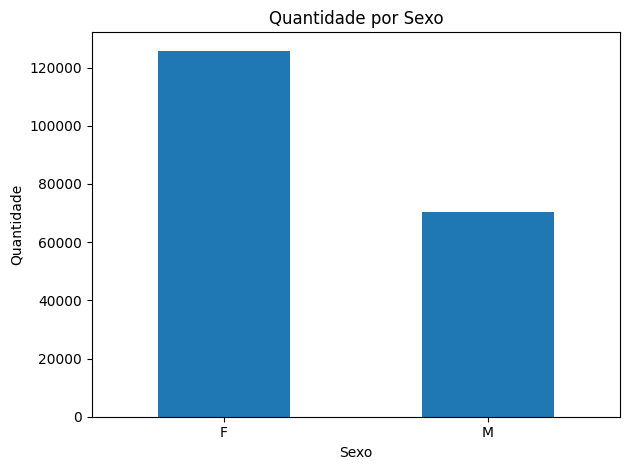

In [ ]:
df_dataset['SEXO'].value_counts().plot(kind='bar')
plt.title('Quantidade por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

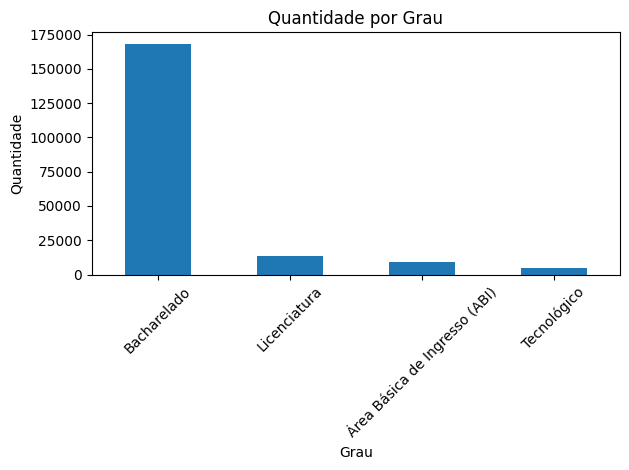

In [ ]:
df_dataset['GRAU'].value_counts().plot(kind='bar')
plt.title('Quantidade por Grau')
plt.xlabel('Grau')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

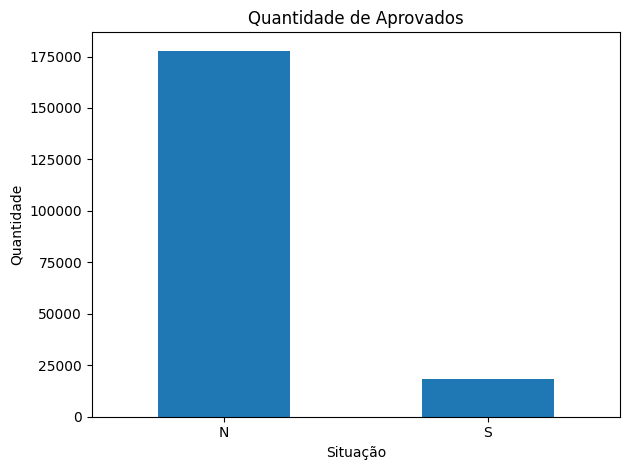

In [ ]:
df_dataset['APROVADO'].value_counts().plot(kind='bar')
plt.title('Quantidade de Aprovados')
plt.xlabel('Situação')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

###Aprovados vs Não_Aprovados



In [ ]:
# APROVADOS vs NÃO APROVADOS

# Total de registros no DataFrame
total_registros = len(df_dataset)

# Total de aprovados
total_aprovados = df_dataset[df_dataset['APROVADO'] == 'S'].shape[0]

# Total de não aprovados
total_nao_aprovados = df_dataset[df_dataset['APROVADO'] == 'N'].shape[0]

# Calcula os percentuais
percentual_aprovados = (total_aprovados / total_registros) * 100
percentual_nao_aprovados = (total_nao_aprovados / total_registros) * 100

# Exibe o resultado
print(f"Total de registros.....: {total_registros}")
print(f"Total de aprovados.....: {total_aprovados} ou {percentual_aprovados:.2f}% do total")
print(f"Total de não aprovados.: {total_nao_aprovados} ou {percentual_nao_aprovados:.2f}% do total")

Total de registros.....: 196095
Total de aprovados.....: 18240 ou 9.30% do total
Total de não aprovados.: 177855 ou 90.70% do total


### _Análise_

> Os dados analisados mostram um conjunto com **196.095 registros**, dos quais **18.240 candidatos foram aprovados**, o que corresponde a **9,30% do total**, enquanto **177.855 não foram aprovados**, representando **90,70%** dos casos. Isso revela um dataset fortemente desbalanceado na variável `APROVADO`, já que a classe `N` aparece em proporção muito maior do que a classe `S`.

> Esse comportamento faz sentido dentro da lógica do SISU. Em processos seletivos desse tipo, o número de candidatos tende a ser muito superior ao número de vagas disponíveis, o que naturalmente produz uma grande concentração de não aprovados e uma minoria de aprovados. Ou seja, o desbalanceamento observado não é um erro dos dados, mas uma característica esperada do fenômeno analisado.

> A distribuição por sexo também mostra um predomínio do sexo feminino. Foram registrados **125.829 candidatos do sexo feminino** e **70.266 do sexo masculino**, indicando maior participação feminina no conjunto analisado. Já em relação ao turno, observa-se maior concentração de candidatos em cursos de **turno integral**, seguido por **matutino** e **noturno**, enquanto **vespertino** e principalmente **EaD** aparecem com participação bem menor.


> O gráfico de barras de aprovados reforça visualmente esse desbalanceamento, já que a barra correspondente a `N` é muito superior à de `S`. Isso mostra que, caso esse dataset venha a ser usado em modelos de inteligência artificial ou aprendizado de máquina, há um risco real de o algoritmo aprender muito mais sobre o perfil dos não aprovados do que sobre o perfil dos aprovados.

#### _Problemas de usar um dataset desbalanceado em IA_

- **Viés para a classe majoritária**: como a maior parte dos registros pertence à classe `N`, o modelo pode tender a prever sempre “não aprovado”, porque isso já gera uma taxa alta de acerto aparente;
- **Dificuldade para identificar aprovados**: a classe `S` é minoritária, então o algoritmo pode ter baixo desempenho justamente no grupo que mais interessa analisar;
- **Acurácia enganosa**: um modelo que previsse apenas `N` para todos os candidatos já teria aproximadamente **90,70% de acerto**, mas isso não significaria que ele realmente aprendeu a distinguir os aprovados;
- **Perda de utilidade prática**: se o objetivo for compreender os padrões ligados à aprovação, um modelo enviesado para a classe majoritária pode se tornar pouco útil.

---



## Criação de uma Amostra

Foi gerada uma amostra do dataset original para utilização na construção dos gráficos *pairplot*, *pairplot balanceado*, *boxplot*, *histograma* e *matriz de correlação*. Essa abordagem tem como objetivo preservar a integridade dos dados originais, evitando alterações decorrentes de pré-processamentos, além de reduzir o custo computacional necessário para a execução das visualizações.

In [ ]:
df_amostra = df_dataset.sample(frac=0.25, random_state=42)

In [ ]:
# Quantidade e tipos de dados e colunas da Amostra
df_amostra.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49024 entries, 18431 to 2715
Data columns (total 57 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ANO                    49024 non-null  int64  
 1   EDICAO                 49024 non-null  int64  
 2   ETAPA                  49024 non-null  int64  
 3   DS_ETAPA               49024 non-null  object 
 4   CODIGO_IES             49024 non-null  int64  
 5   NOME_IES               49024 non-null  object 
 6   SIGLA_IES              49024 non-null  object 
 7   UF_IES                 49024 non-null  object 
 8   CODIGO_CAMPUS          49024 non-null  int64  
 9   NOME_CAMPUS            49024 non-null  object 
 10  UF_CAMPUS              49024 non-null  object 
 11  MUNICIPIO_CAMPUS       49024 non-null  object 
 12  CODIGO_CURSO           49024 non-null  int64  
 13  NOME_CURSO             49024 non-null  object 
 14  GRAU                   49024 non-null  object 
 15  TURN

In [ ]:
# QUANTIDADE DE BINS

pd.set_option('display.max_columns', 25)          # mostra pelo menos 25 colunas
pd.set_option('display.width', 1000)              # evita quebra de linha
pd.set_option('display.expand_frame_repr', False) # mantém tudo em uma linha

resultado_bins = []

variaveis = df_amostra.select_dtypes(include='number').columns

for var in variaveis:
    serie = df_amostra[var].dropna()

    # ignora colunas vazias
    if len(serie) == 0:
        continue

    # valores básicos
    minimo = serie.min()
    maximo = serie.max()
    amplitude = maximo - minimo
    unicos = serie.nunique()

    # evita erro em colunas constantes
    if amplitude == 0:
        qtd_bins = 1
    else:
        bins = np.histogram_bin_edges(serie, bins='fd')
        qtd_bins = len(bins) - 1

    resultado_bins.append({
        'variavel': var,
        'qtd_registros': len(serie),
        'valores_unicos': unicos,
        'qtd_bins': qtd_bins,
        'min': minimo,
        'max': maximo,
        'amplitude': amplitude
    })

df_bins = (
    pd.DataFrame(resultado_bins)
    .sort_values(by='qtd_bins', ascending=False)
    .reset_index(drop=True)
)

# 🔹 MOSTRAR MAIS LINHAS TAMBÉM (opcional)
pd.set_option('display.max_rows', 50)

df_bins

,variavel,qtd_registros,valores_unicos,qtd_bins,min,max,amplitude
0,CODIGO_IES,49024,14,4192,6.0,4358.0,4352.0
1,CODIGO_CURSO,49024,634,839,586.0,50017033.0,50016447.0
2,IDADE_APROX,49024,62,614,14.0,81.0,67.0
3,DT_NASCIMENTO,49024,62,614,1942.0,2009.0,67.0
4,CLASSIFICACAO,46190,3597,518,1.0,7987.0,7986.0
5,NOTA_R_COM_PESO,49024,105,170,160.0,2940.0,2780.0
6,QT_VAGAS_CONCORRENCIA,49024,49,146,1.0,160.0,159.0
7,NOTA_R,49024,43,65,160.0,1000.0,840.0
8,CODIGO_CAMPUS,49024,126,22,209.0,1141558.0,1141349.0
9,OPCAO,49024,2,19,1.0,2.0,1.0


## Gráficos Pairplot




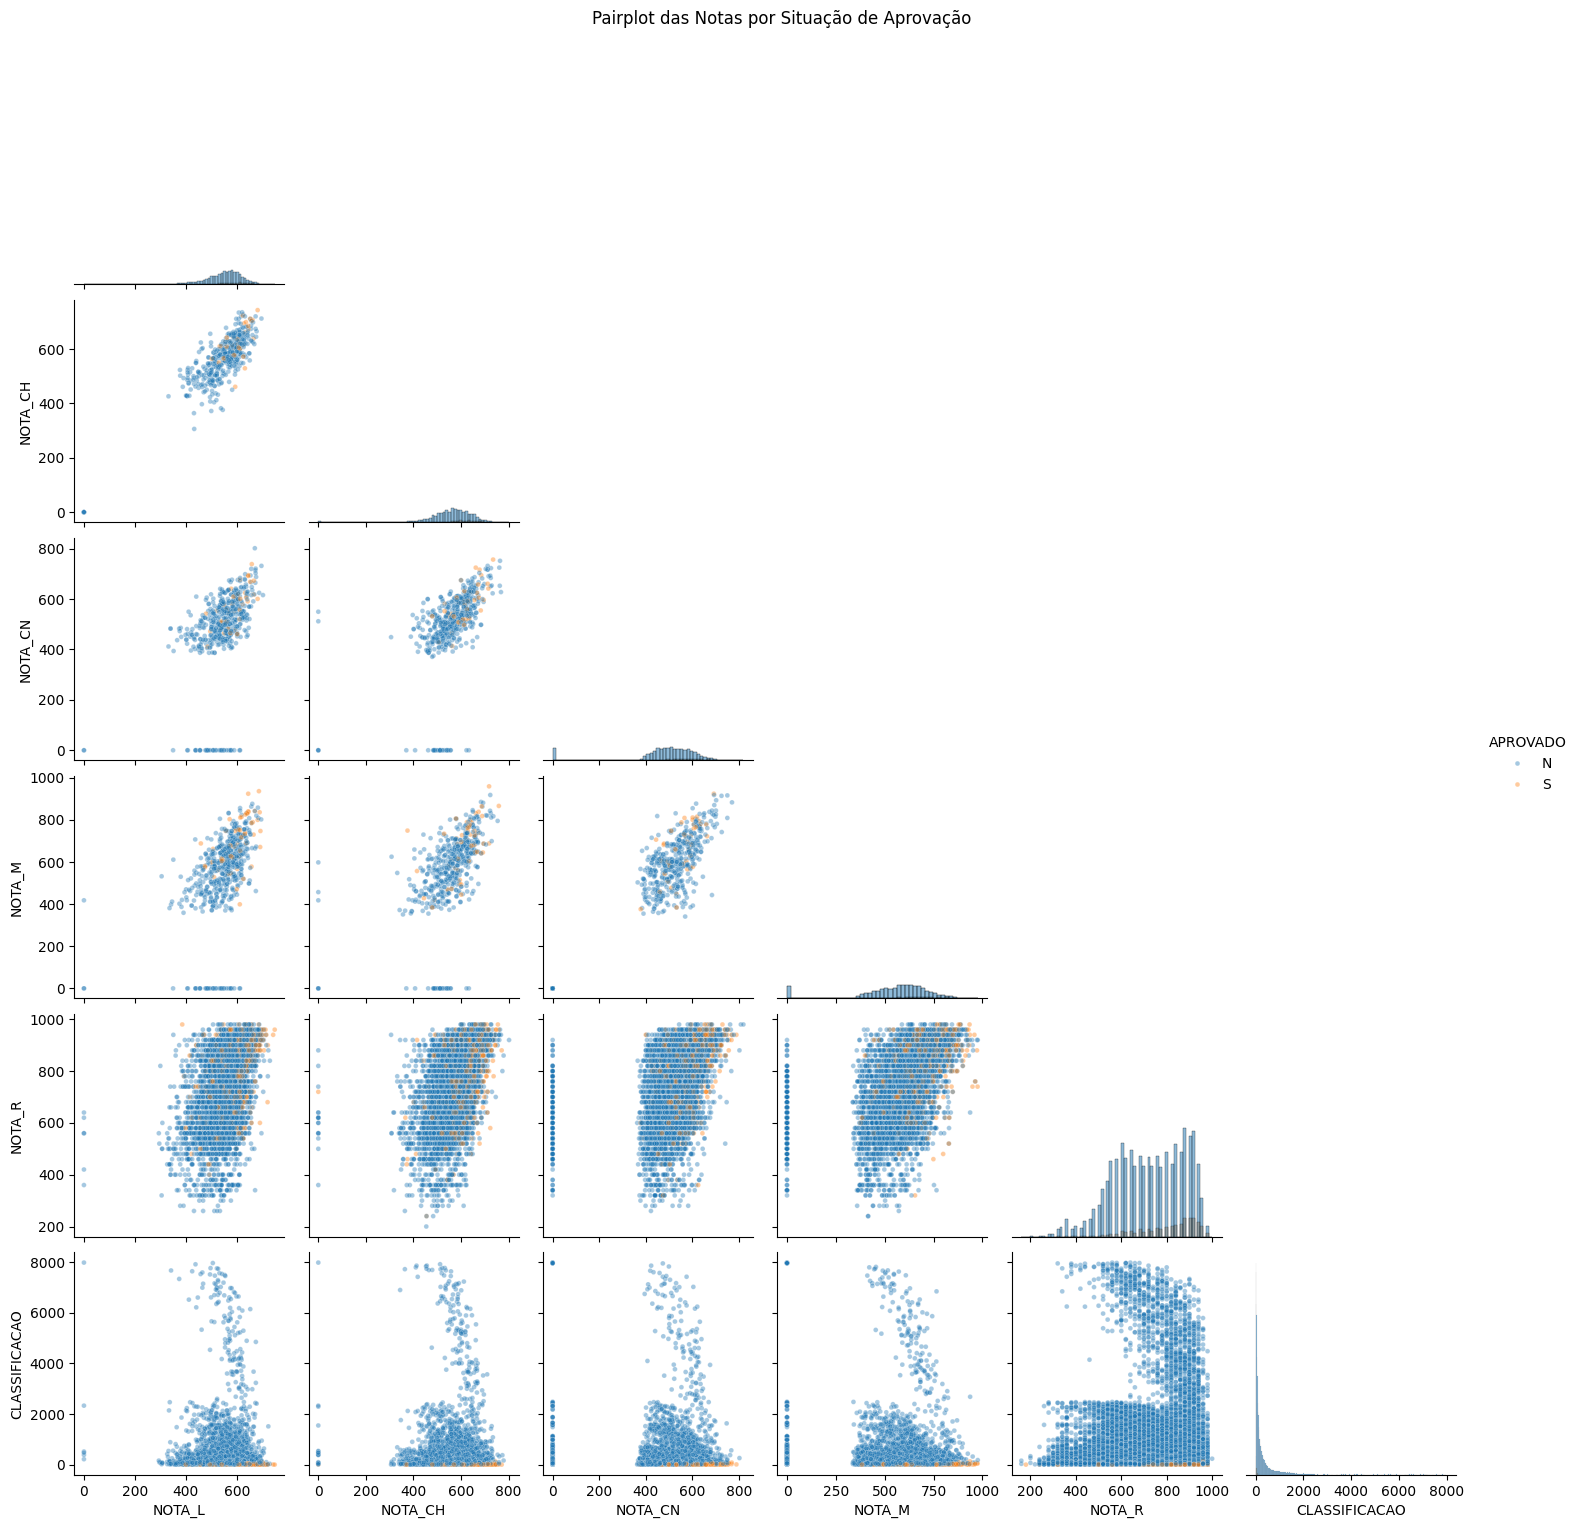

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Converter colunas de nota para número
colunas_notas = [
    'NOTA_L', 'NOTA_CH', 'NOTA_CN', 'NOTA_M',
    'NOTA_L_COM_PESO', 'NOTA_CH_COM_PESO',
    'NOTA_CN_COM_PESO', 'NOTA_M_COM_PESO',
    'NOTA_CANDIDATO', 'NOTA_CORTE', 'MEDIA_MINIMA'
]

# Pega uma amostra para o gráfico ficar mais leve
amostra = df_amostra.copy()

for col in colunas_notas:
    amostra[col] = pd.to_numeric(amostra[col], errors='coerce')

# Variáveis do pairplot
vars_plot = ['NOTA_L', 'NOTA_CH', 'NOTA_CN', 'NOTA_M',
             'NOTA_R', 'CLASSIFICACAO']

# Gráfico
g = sns.pairplot(
    amostra,
    vars=vars_plot,
    hue='APROVADO',
    diag_kind='hist',
    corner=True,
    plot_kws={'s': 12, 'alpha': 0.4}
)

g.fig.suptitle('Pairplot das Notas por Situação de Aprovação', y=1.02)
plt.show()

### _Análise_

> O pairplot apresenta a relação entre as variáveis `NOTA_L`, `NOTA_CH`, `NOTA_CN`, `NOTA_M`, `NOTA_R` e `CLASSIFICACAO`, segmentadas pela variável `APROVADO`. A cor azul representa os candidatos não aprovados (`N`) e a cor laranja representa os aprovados (`S`).

> Observa-se que as notas apresentam relações positivas entre si. Em vários cruzamentos, como `NOTA_CH` com `NOTA_L`, `NOTA_CN` com `NOTA_CH` e `NOTA_M` com outras notas, os pontos formam nuvens inclinadas para cima, indicando que candidatos com notas mais altas em uma área tendem também a apresentar notas mais altas em outras.

> A variável `NOTA_R` aparece com maior dispersão, mas ainda mantém concentração em faixas intermediárias e altas. Já `CLASSIFICACAO` mostra uma distribuição muito concentrada em valores baixos, com alguns pontos se estendendo para classificações mais altas.

> Também é possível perceber que os candidatos aprovados (`S`) aparecem em menor quantidade visual do que os não aprovados (`N`), o que está de acordo com o desbalanceamento observado anteriormente na variável `APROVADO`.

#### _Resumo_

> O gráfico mostra uma associação positiva entre as notas, indicando que o desempenho dos candidatos tende a seguir um padrão relativamente consistente entre diferentes áreas. Ao mesmo tempo, a variável `CLASSIFICACAO` apresenta comportamento mais concentrado e assimétrico. A separação entre aprovados e não aprovados não aparece totalmente definida apenas pelas combinações visuais das notas, embora os aprovados estejam mais visíveis em regiões de notas mais altas.

## Pairplot Balanceado
O pairplot balanceado é uma representação gráfica multivariada que permite analisar simultaneamente a relação entre diferentes variáveis numéricas, utilizando quantidades equivalentes de dados para cada classe, como aprovados e não aprovados.

O balanceamento é fundamental para evitar tendências na análise, como exemplo temos 90% de não aprovados contra 10% de aprovados facilmente observado ao executar o código para printar as relações, tornando a visualização enganosa e dificulta a identificação de padrões reais. Ao igualar as classes em uma proporção de 50% para cada grupo, é possível realizar uma comparação mais justa e confiável, permitindo uma interpretação mais precisa dos dados no contexto do projeto.

Na estrutura do pairplot, os gráficos dispostos na diagonal representam as distribuições individuais de cada variável, geralmente por meio de histogramas ou curvas de densidade (KDE). Esses gráficos permitem observar a concentração das notas e o comportamento das classes em relação a cada variável.

No nosso estudo, observa-se que os candidatos aprovados tendem a apresentar distribuições deslocadas para a direita, indicando notas mais altas, fácil de ver na redação, enquanto os não aprovados concentram-se em faixas inferiores. Esse deslocamento evidencia a diferença de desempenho entre os grupos e contribui para a compreensão dos fatores associados à aprovação.

Os gráficos fora da diagonal são gráficos de dispersão (scatter plots), que mostram a relação entre pares de variáveis, como por exemplo Mat. x Ciências ou Mat. x Linguagens. Esses gráficos são importantes para identificar correlações, tendências e padrões nos dados. É possível observar relações lineares, agrupamentos ascendentes ou descendentes, além de regiões onde há maior concentração de candidatos. Também se destacam áreas em que ocorre separação clara entre aprovados e não aprovados, bem como regiões de sobreposição, que indicam menor capacidade de distinção entre as classes.

A diferenciação das classes é realizada por meio de cores (hue), permitindo identificar visualmente os padrões de separação entre os grupos. Quando os pontos apresentam separação bem definida, isso indica forte capacidade de distinção entre aprovados e não aprovados. Por outro lado, quando há sobreposição significativa, a variável ou combinação de variáveis apresenta menor discriminação. Além disso, padrões como alinhamentos lineares, tendências diagonais ou agrupamentos específicos fornecem indicações importantes sobre a relação entre as variáveis e o comportamento dos candidatos.

A análise entre diferentes áreas do conhecimento, representadas nos pares de variáveis, permite identificar quais combinações de desempenho são mais relevantes para a aprovação. Observa-se, por exemplo, que a combinação entre Mat. e Ciências tende a apresentar maior separação entre aprovados e não aprovados, indicando maior influência dessas áreas no resultado final. Em contrapartida, combinações como Linguagens e Humanas geralmente apresentam maior sobreposição, sugerindo menor capacidade de diferenciação entre os grupos.

Dessa forma, o uso do pairplot balanceado no presente projeto permite compreender de maneira clara e visual quais áreas do conhecimento têm maior impacto na aprovação, identificar padrões relevantes nos dados e avaliar o grau de separação entre os candidatos. Além disso, essa ferramenta contribui para a construção de análises mais robustas e pode servir como base para o desenvolvimento de modelos preditivos, auxiliando na tomada de decisão e na geração de insights a partir dos dados analisados.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

colunas_notas = [
    'NOTA_L', 'NOTA_CH', 'NOTA_CN', 'NOTA_M',
    'NOTA_L_COM_PESO', 'NOTA_CH_COM_PESO',
    'NOTA_CN_COM_PESO', 'NOTA_M_COM_PESO',
    'NOTA_CANDIDATO', 'NOTA_CORTE', 'MEDIA_MINIMA'
]

# cria amostra sem alterar o dataset original
amostra = df_amostra.copy()

# converte apenas na amostra
for col in colunas_notas:
    if col in amostra.columns:
        amostra[col] = pd.to_numeric(
            amostra[col].astype(str).str.replace(',', '.', regex=False),
            errors='coerce'
        )

['ANO', 'EDICAO', 'ETAPA', 'DS_ETAPA', 'CODIGO_IES', 'NOME_IES', 'SIGLA_IES', 'UF_IES', 'CODIGO_CAMPUS', 'NOME_CAMPUS', 'UF_CAMPUS', 'MUNICIPIO_CAMPUS', 'CODIGO_CURSO', 'NOME_CURSO', 'GRAU', 'TURNO', 'DS_PERIODICIDADE', 'TP_COTA', 'TIPO_MOD_CONCORRENCIA', 'MOD_CONCORRENCIA', 'QT_VAGAS_CONCORRENCIA', 'PERCENTUAL_BONUS', 'PESO_L', 'PESO_CH', 'PESO_CN', 'PESO_M', 'PESO_R', 'NOTA_MINIMA_L', 'NOTA_MINIMA_CH', 'NOTA_MINIMA_CN', 'NOTA_MINIMA_M', 'NOTA_MINIMA_R', 'MEDIA_MINIMA', 'CPF', 'INSCRICAO_ENEM', 'INSCRITO', 'SEXO', 'DT_NASCIMENTO', 'UF_CANDIDATO', 'MUNICIPIO_CANDIDATO', 'OPCAO', 'NOTA_L', 'NOTA_CH', 'NOTA_CN', 'NOTA_M', 'NOTA_R', 'NOTA_L_COM_PESO', 'NOTA_CH_COM_PESO', 'NOTA_CN_COM_PESO', 'NOTA_M_COM_PESO', 'NOTA_R_COM_PESO', 'NOTA_CANDIDATO', 'NOTA_CORTE', 'CLASSIFICACAO', 'APROVADO', 'MATRICULA', 'IDADE_APROX']
['N' 'S']


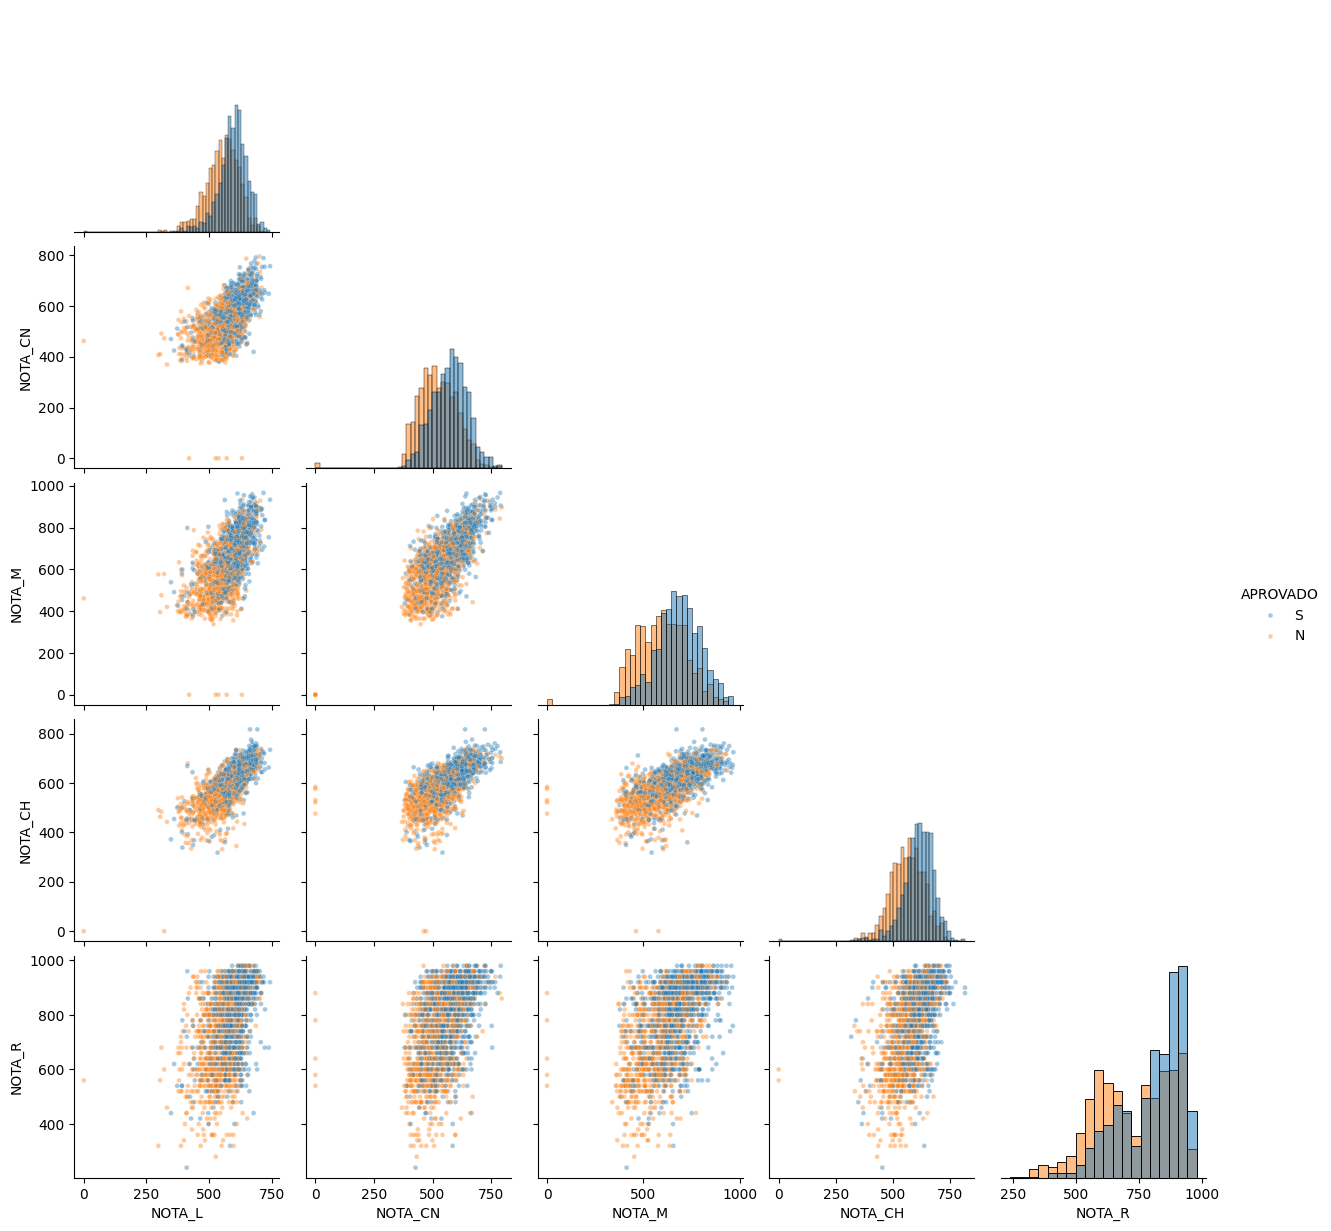

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# trabalhar em cópia para não afetar o original
df = df_amostra.copy()
df.columns = df.columns.str.strip()

# conferir colunas
print(df.columns.tolist())

# colunas usadas
cols_notas = ['NOTA_L', 'NOTA_CN', 'NOTA_M', 'NOTA_CH', 'NOTA_R']
cols = cols_notas + ['APROVADO']

# pegar amostra
amostra = df[cols].copy()

# conversão apenas na amostra
for col in cols_notas:
    amostra[col] = pd.to_numeric(
        amostra[col].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

# remover nulos
dados = amostra.dropna()

# verificar valores
print(dados['APROVADO'].unique())

# balanceamento
aprov = dados[dados['APROVADO'] == 'S']
nao_aprov = dados[dados['APROVADO'] == 'N']

n = min(len(aprov), len(nao_aprov))

dados_balanceados = pd.concat([
    aprov.sample(n, random_state=42),
    nao_aprov.sample(n, random_state=42)
]).sample(min(2000, 2 * n), random_state=42)

# gráfico
sns.pairplot(
    dados_balanceados,
    hue='APROVADO',
    diag_kind='hist',
    corner=True,
    plot_kws={'s': 12, 'alpha': 0.4}
)

plt.show()

['ANO', 'EDICAO', 'ETAPA', 'DS_ETAPA', 'CODIGO_IES', 'NOME_IES', 'SIGLA_IES', 'UF_IES', 'CODIGO_CAMPUS', 'NOME_CAMPUS', 'UF_CAMPUS', 'MUNICIPIO_CAMPUS', 'CODIGO_CURSO', 'NOME_CURSO', 'GRAU', 'TURNO', 'DS_PERIODICIDADE', 'TP_COTA', 'TIPO_MOD_CONCORRENCIA', 'MOD_CONCORRENCIA', 'QT_VAGAS_CONCORRENCIA', 'PERCENTUAL_BONUS', 'PESO_L', 'PESO_CH', 'PESO_CN', 'PESO_M', 'PESO_R', 'NOTA_MINIMA_L', 'NOTA_MINIMA_CH', 'NOTA_MINIMA_CN', 'NOTA_MINIMA_M', 'NOTA_MINIMA_R', 'MEDIA_MINIMA', 'CPF', 'INSCRICAO_ENEM', 'INSCRITO', 'SEXO', 'DT_NASCIMENTO', 'UF_CANDIDATO', 'MUNICIPIO_CANDIDATO', 'OPCAO', 'NOTA_L', 'NOTA_CH', 'NOTA_CN', 'NOTA_M', 'NOTA_R', 'NOTA_L_COM_PESO', 'NOTA_CH_COM_PESO', 'NOTA_CN_COM_PESO', 'NOTA_M_COM_PESO', 'NOTA_R_COM_PESO', 'NOTA_CANDIDATO', 'NOTA_CORTE', 'CLASSIFICACAO', 'APROVADO', 'MATRICULA', 'IDADE_APROX']
['N' 'S']


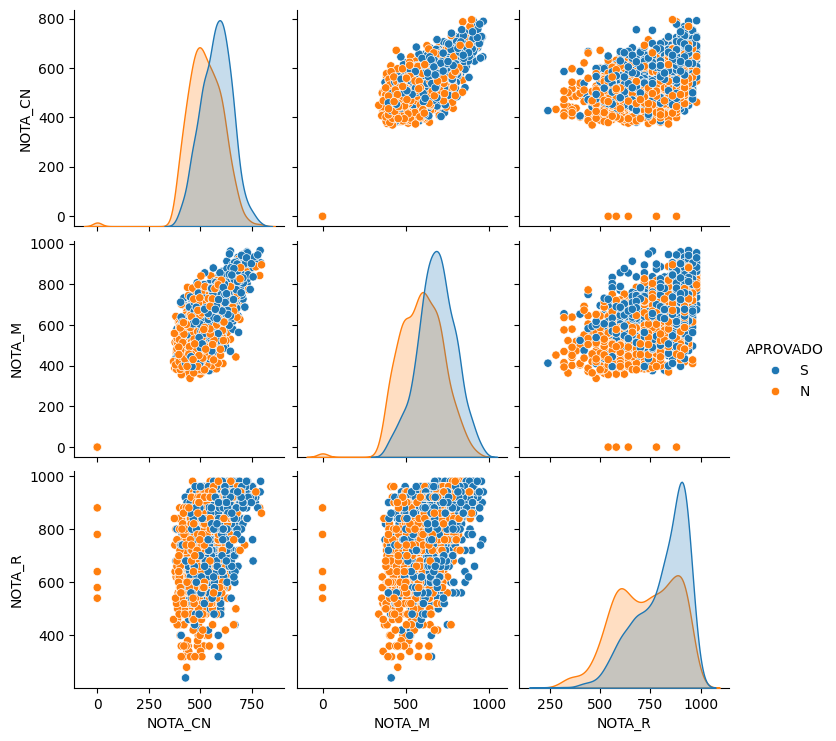

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

amostra = df_amostra.copy()

# limpar nomes das colunas
df_amostra.columns = df_amostra.columns.str.strip()

# conferir colunas
print(df_amostra.columns.tolist())

# converter notas para número
cols_notas = ['NOTA_CN', 'NOTA_M', 'NOTA_R']

for col in cols_notas:
    amostra[col] = pd.to_numeric(amostra[col].astype(str).str.replace(',', '.'), errors='coerce')

# selecionar colunas
cols = ['NOTA_CN', 'NOTA_M', 'NOTA_R', 'APROVADO']
dados = amostra[cols].dropna()

# ver valores existentes em APROVADO
print(dados['APROVADO'].unique())

# balancear
aprov = dados[dados['APROVADO'] == 'S']
nao_aprov = dados[dados['APROVADO'] == 'N']

n = min(len(aprov), len(nao_aprov))

# se quiser reduzir tamanho, faça separado:
dados_balanceados = pd.concat([
    aprov.sample(n, random_state=42),
    nao_aprov.sample(n, random_state=42)
]).sample(min(2000, 2*n), random_state=42)


# pairplot
sns.pairplot(dados_balanceados, hue='APROVADO')
plt.show()

#### _Análise_

> Os gráficos mostram que, entre várias combinações de notas, os pontos seguem tendências ascendentes, sugerindo associação positiva entre algumas áreas. Em termos visuais, candidatos com notas mais altas em uma variável tendem, em vários pares, a também apresentar notas mais altas em outra.
Temos dois gráficos que comparam em pares, as variáveis `NOTA_L`, `NOTA_CH`, `NOTA_CN`, `NOTA_M` e `NOTA_R`, usando gráficos de dispersão fora da diagonal e histogramas na diagonal. As cores representam a situação de aprovação (APROVADO), separando os candidatos em `N` e `S`.

> A partir da análise do primeiro gráfico, observa-se que a distribuição dos pontos varia significativamente entre os diferentes pares de variáveis. Nos conjuntos relacionados às áreas de Linguagens e Ciências Humanas, há uma elevada dispersão dos dados, formando uma nuvem de pontos com formato aproximadamente circular e bastante homogêneo, sem distinção clara entre candidatos aprovados e reprovados. Esse comportamento indica uma baixa correlação dessas áreas com o resultado de aprovação, sugerindo que seu impacto isolado no desempenho final é limitado.

> Por outro lado, nas áreas de Mat., Ciências da Natureza e Redação, percebe-se um padrão distinto, com pontos mais concentrados e alinhados, evidenciando uma tendência mais linear e crescente. Nesses casos, há uma separação mais clara entre candidatos aprovados e não aprovados, indicando uma maior influência dessas variáveis no processo de aprovação. Esse padrão sugere que desempenhos mais elevados nessas áreas estão diretamente associados a maiores chances de sucesso no processo seletivo.

> Analisando o segundo gráfico balanceado, observamos que tanto Mat. X CN ou CN x Mat. Apresentam uma boa diferenciação entre aprovados e não aprovados além de uma linearidade diagonal ascendente, sendo que Mat x CN tem uma inclinação e o oposto um perfil mais vertical, isso mostra que quanto maior as notas nessas duas áreas, mais chances dos candidatos serem aprovados. Tanto Mat como CN x Redação mostram uma imagem em diagonal, mas com valores bem mais dispersos, porém indicando que essas 3 áreas de conhecimento têm total relação com a aprovação dos alunos, porem Mat. E CN uma relação mais direta pelo agrupamento dos dados.


#### _Eixos_

- Linhas = variável no eixo Y
- Colunas = variável no eixo X
- Diagonal = histograma da distribuição de cada variável

#### _Padrões observados no gráfico_

 - A classe `S` e `N` aparecem em quantidades iguais devido ao balanceamento do gráfico.
 - Em vários pares de notas, os pontos formam um desenho inclinado para cima, indicando relação positiva entre as variáveis comparadas, uma relação direta entre as variáveis, isso mais observado em Mat. e CN.
 - No KDE da redação é possível observar a distribuição entre as notas dos `S` e dos `N`
 - Mat. E CN definem muito bem a linha entre aprovados e reprovados em uma diagonal ascendentes com pontos bem agrupados.
 - Muitos candidatos com nota zero em CN tiveram boas notas em redação, mas não foram aprovados
 - A relação entre Redação e Mat. Possui muitos pontos espalhados e não tem boa indicação de influência, além de que estar bem misturados os `S` e s `N`.


> |Variáveis comparadas|O que se observa?|
> |---|---|
> |**NOTA_L x NOTA_R**|Formato circular sem relação direta entre aprovados e reprovados na variação das notas nas áreas de conhecimento
> |**NOTA_CH x NOTA_R**|Pouco menos circular e sem uma relação direta de grande intensidade entre aprovados e reprovados na variação das notas nas áreas de conhecimento
> |**NOTA_L x NOTA_CH**|Temos uma estrutura mais em diagonal ascendentes, porem ainda muito misturados os aprovados e não aprovados
> |**NOTA_M × NOTA_CN**|Também aparece uma tendência positiva, com pontos bem concentrados e baixa dispersão.|
> |**NOTA_R × NOTA_M**|Os pontos se distribuem em uma faixa ampla, mas ainda com inclinação crescente mas muito misturados.|


#### _Resumo_

> Esse pairplot balanceado mostra como as notas se relacionam e nos mostram um caminho claro para a aprovação ou como ter sucesso no modelo atual, onde se concentrar mais nos estudos e ter mais preocupação com os resultados.

> A imagem sugere associação positiva entre várias notas e mostra que a aprovação tem distribuição bastante concentrada em valores altos das notas. É uma visualização útil para perceber padrões gerais entre as variáveis, sem ainda tirar conclusões causais.


##Gráficos Boxplot
Um boxplot (ou diagrama de caixa) é um tipo de gráfico estatístico que resume a distribuição de uma variável numérica em cinco números principais, de forma compacta e visual.

#### *Elementos do Boxplot*

- **Caixa (box)**

> - Vai do primeiro quartil (Q1, 25%) ao terceiro quartil (Q3, 75%).
> - Representa o intervalo interquartil (IQR = Q3 – Q1), onde está metade dos dados.

- **Linha dentro da caixa**: é a mediana (Q2, 50%).

- **"Bigodes" (whiskers)**: Se estendem a partir da caixa até o menor e o maior valor que não sejam considerados outliers.

> - Normalmente:
    - Inferior: Q1 – 1.5 × IQR
    - Superior: Q3 + 1.5 × IQR

- **Outliers (pontos isolados)**

> - Valores além dos limites dos bigodes.
> - Plotados como pontos ou círculos.

#### *O que ele mostra?*

- **Tendência central**: pela mediana;

- **Dispersão**: pelo tamanho da caixa (IQR);

- **Assimetria**: se a mediana não está centralizada na caixa;

- **Presença de outliers**: pontos fora dos bigodes.


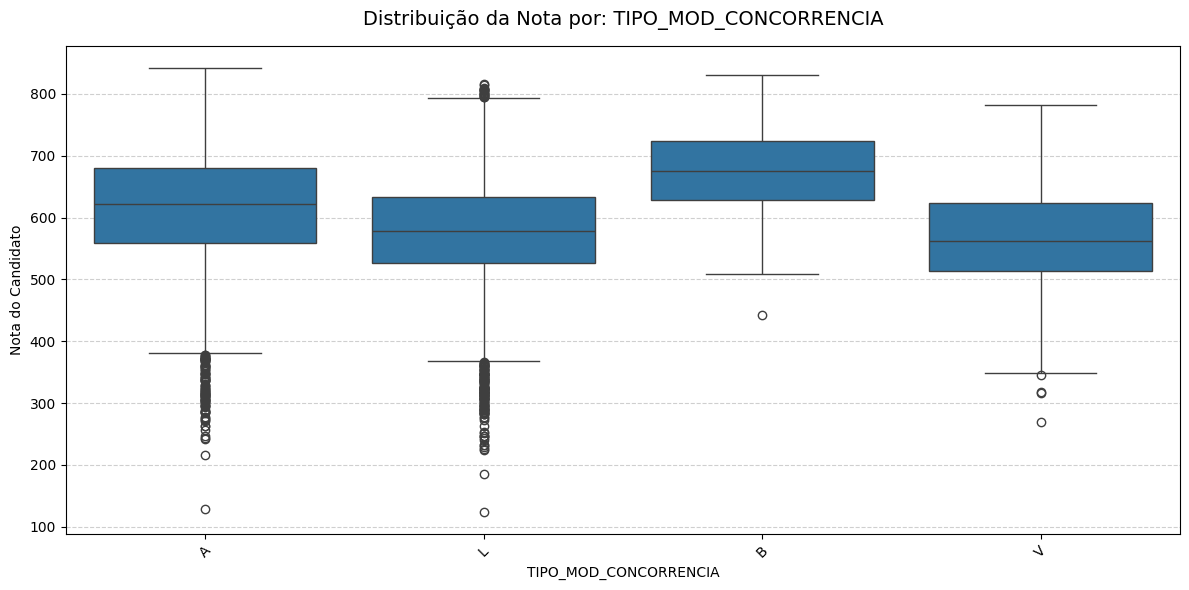

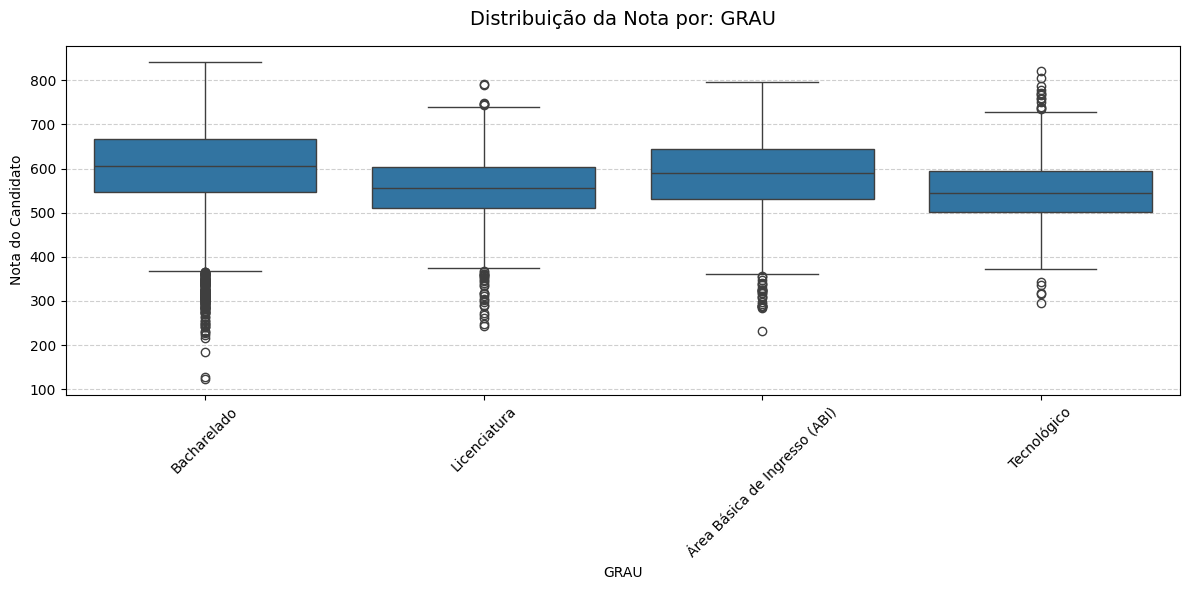

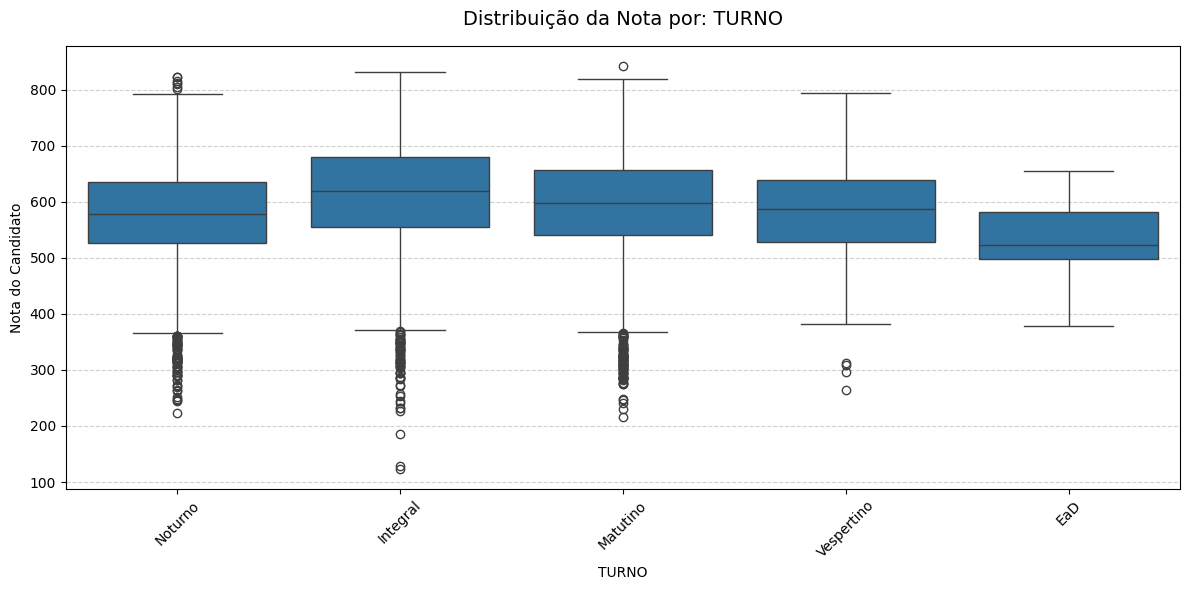

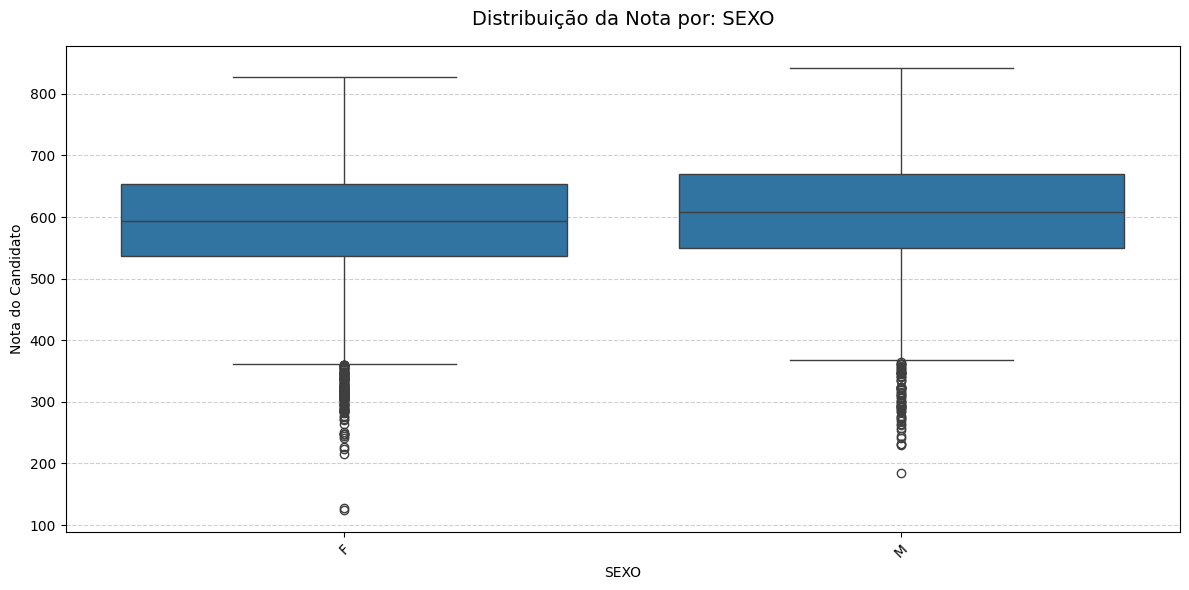

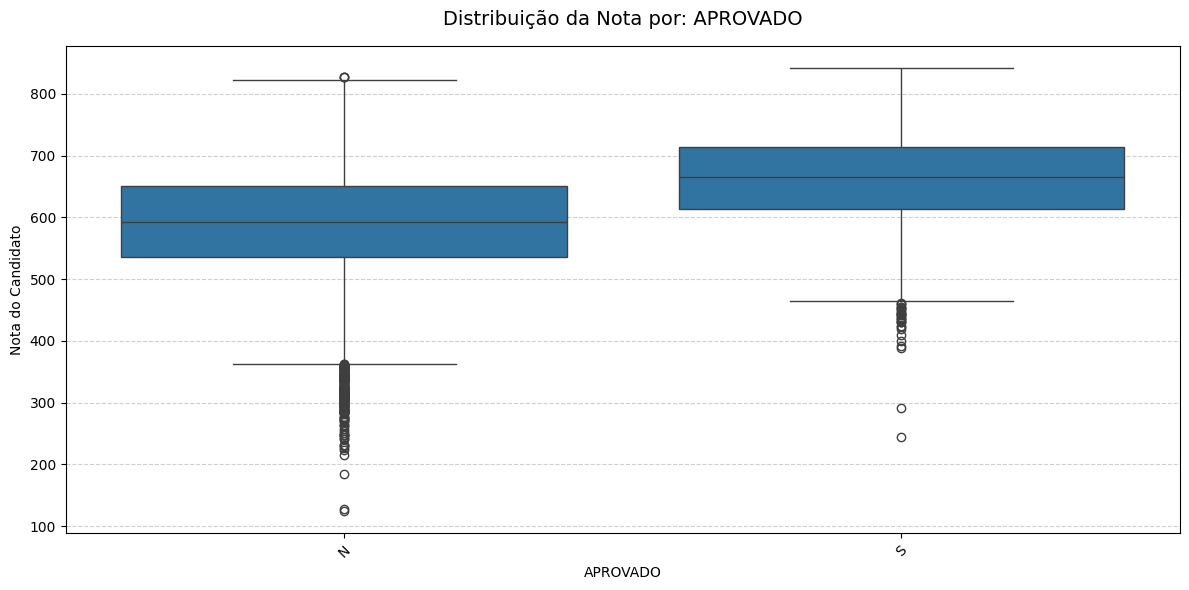

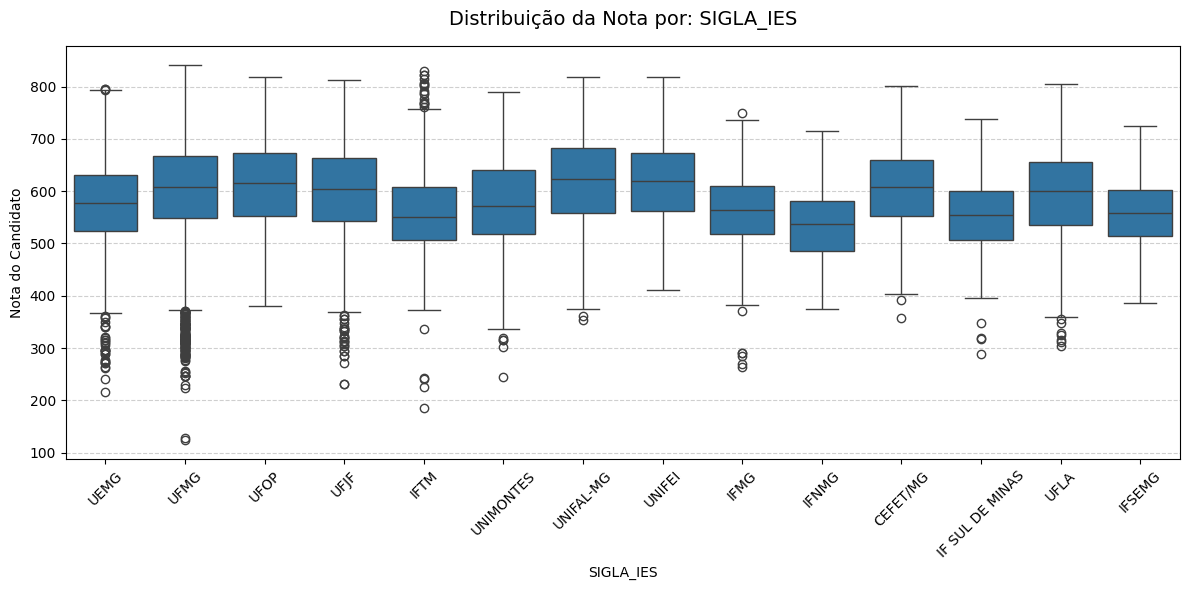

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

vars_box = [
    'TIPO_MOD_CONCORRENCIA', 'GRAU', 'TURNO',
    'SEXO', 'APROVADO', 'SIGLA_IES'
]

# Conversão da coluna de nota
df_amostra['NOTA_CANDIDATO'] = pd.to_numeric(
    df_amostra['NOTA_CANDIDATO'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)

# Remoção de valores inválidos (NaN)
df_amostra_cleaned = df_amostra.dropna(subset=['NOTA_CANDIDATO']).copy()

# Criação dos gráficos
for var in vars_box:
    plt.figure(figsize=(12, 6))

    sns.boxplot(
        data=df_amostra_cleaned, # Use the cleaned DataFrame
        x=var,   # agora usamos os bins
        y='NOTA_CANDIDATO'
    )

    plt.title(f'Distribuição da Nota por: {var}', fontsize=14, pad=15)
    plt.xlabel(var)
    plt.ylabel('Nota do Candidato')

    plt.xticks(rotation=45)  # melhora leitura dos bins
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

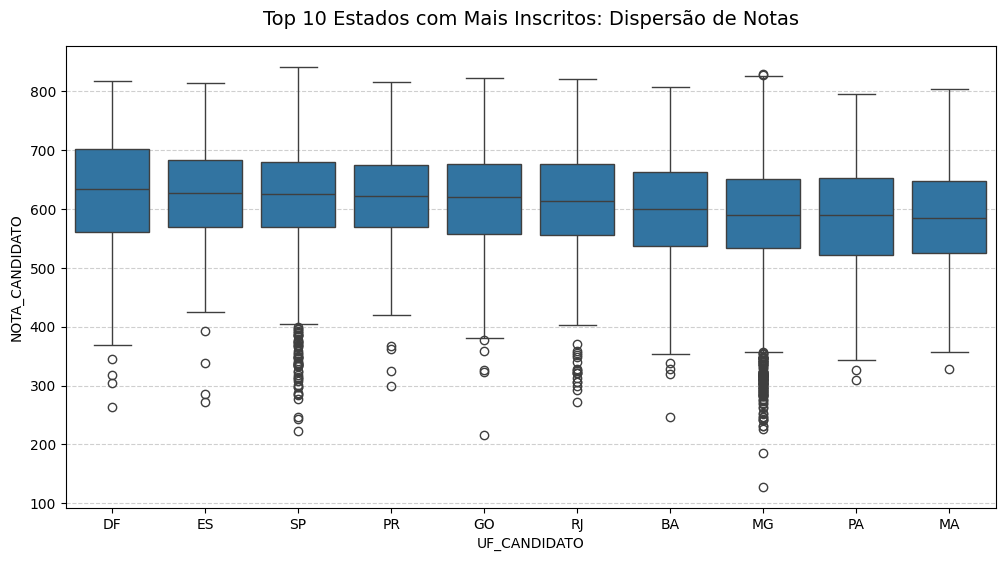

In [ ]:
# Gráfico: Top 10 Estados (UF_CANDIDATO) vs notas dos candidatos

plt.figure(figsize=(12, 6))
top_uf = df_amostra_cleaned['UF_CANDIDATO'].value_counts().nlargest(10).index
df_top_uf = df_amostra_cleaned[df_amostra_cleaned['UF_CANDIDATO'].isin(top_uf)]
order_uf = df_top_uf.groupby('UF_CANDIDATO')['NOTA_CANDIDATO'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df_top_uf,
    x='UF_CANDIDATO',
    y='NOTA_CANDIDATO',
    order=order_uf)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.title('Top 10 Estados com Mais Inscritos: Dispersão de Notas', fontsize=14, pad=15)
plt.show()

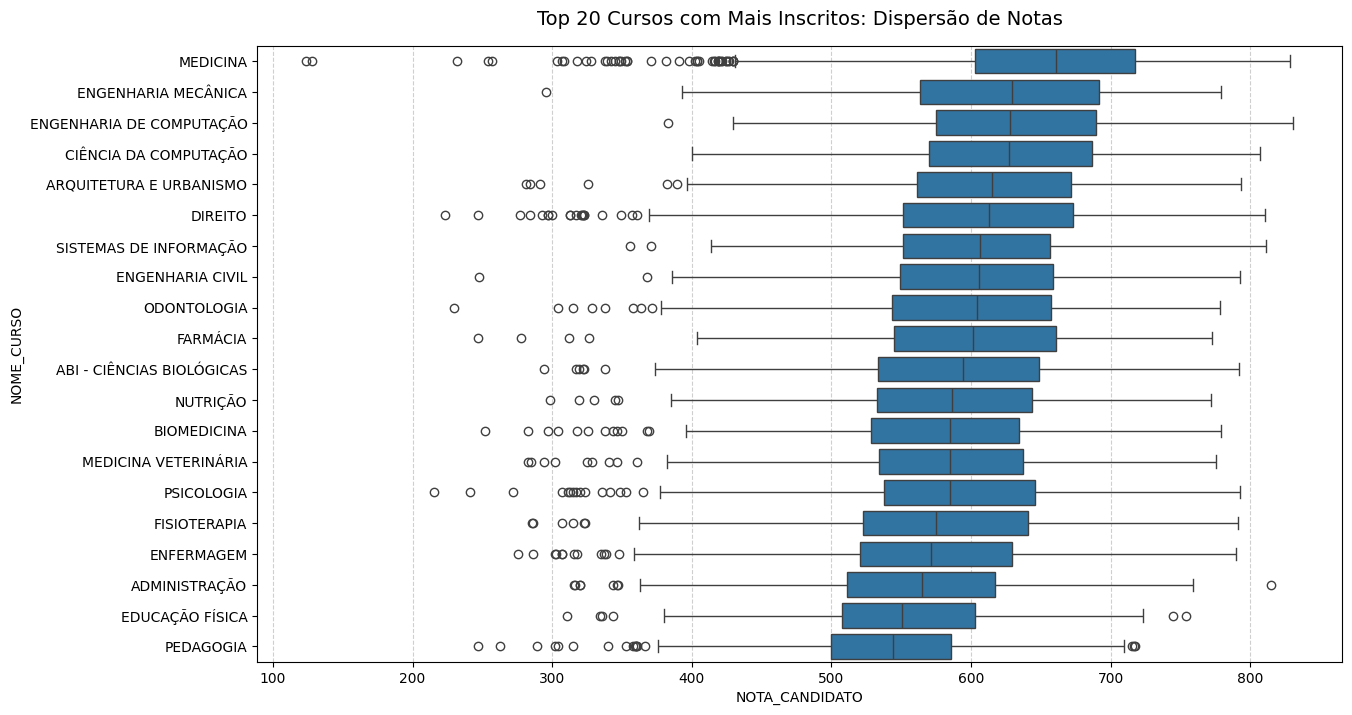

In [ ]:
# Gráfico: Top 20 Cursos com mais inscritos (NOME_CURSO) vs notas dos candidatos

plt.figure(figsize=(14, 8))
top_curso = df_amostra_cleaned['NOME_CURSO'].value_counts().nlargest(20).index
df_top_curso = df_amostra_cleaned[df_amostra_cleaned['NOME_CURSO'].isin(top_curso)]
order_curso = df_top_curso.groupby('NOME_CURSO')['NOTA_CANDIDATO'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df_top_curso,
    x='NOTA_CANDIDATO',
    y='NOME_CURSO',
    order=order_curso)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.title('Top 20 Cursos com Mais Inscritos: Dispersão de Notas', fontsize=14, pad=15)
plt.show()


### *Análises*

#### **Gráfico: Nota Candidato vs Tipo de Modalidade de Concorrência**
> O gráfico realiza uma comparação entre as notas dos candidatos e os tipos de modalidade de concorrência:
>
>| Modalidade de Concorrência               | Observação sobre notas dos candidatos                                             |
>| ---------------------------- | ----------------------------------------------------------------------- |
>| **Categoria B (Ações Afirmativas de Pontuação)**               | Alta variabilidade, com presença de candidatos de desempenho elevado                                        |
>| **Categoria A (Ampla concorrência)**            | Concentração de candidatos com desempenho médio-alto                     |
>| **Categoria L (Lei de Cotas)**        | Maior heterogeneidade no desempenho                              |
>| **Categoria V (Vagas Reservadas)**       | Desempenho mais baixo e mais homogêneo                                       |

##### *Interpretação prática*

> * Existem diferenças significativas de desempenho entre modalidades, possivelmente associadas a fatores socioeconômicos, políticas de ação afirmativa e formação prévia;
> * Modalidades A e B apresentam maior competitividade (medianas mais altas), enquanto V tende a ter menor pressão competitiva e notas de corte mais acessíveis;
> *Alta dispersão (B) indica maior desigualdade interna e reduz a previsibilidade da nota de corte;
> * Maior homogeneidade (V) favorece previsões mais estáveis.


##### *Resumo*
> A análise evidencia que a modalidade de concorrência influencia diretamente a distribuição das notas dos candidatos. Observa-se variação nas medianas e nos níveis de dispersão entre os grupos, impactando tanto a competitividade quanto a previsibilidade das notas de corte.





#### **Gráfico: Nota Candidato vs Grau do Curso**
> O gráfico compara a distribuição das notas dos candidatos conforme o grau do curso:
>
>| Grau do Curso                | Observação sobre notas dos candidatos                                            |
>| ---------------------------- | ----------------------------------------------------------------------- |
>| **Bacharelado**               | Alta competitividade e elevada variabilidade nas notas                                       |
>| **Área Básica de Ingresso (ABI)**            | Perfil semelhante ao bacharelado, mas com leve menor variabilidade                     |
>| **Licenciatura**        | Distribuição mais estável, porém com desempenho médio inferior                              |
>| **Tecnológico**       | Maior homogeneidade e menor nível geral de notas   

##### *Interpretação prática*
> * Grau do curso influencia diretamente o perfil de notas dos candidatos, refletindo diferenças na demanda entre formações;
> * Bacharelado e ABI podem apresentar maior competitividade, com notas de corte mais elevadas;
> * Licenciatura e Tecnológico tendem a maior acessibilidade, com notas de corte mais baixas;
> * Alta dispersão (Bacharelado) reduz a previsibilidade das notas de corte;
> * Baixa dispersão (Tecnológico) favorece previsões mais consistentes.

##### *Resumo*
> A análise demonstra que o grau do curso impacta diretamente a distribuição das notas dos candidatos. Bacharelado e ABI apresentam maior competitividade e variabilidade, enquanto Licenciatura e Tecnológico possuem distribuições mais concentradas e medianas inferiores, influenciando a previsibilidade e o nível de concorrência.




#### **Gráfico: Nota Candidato vs Turno do Curso**
> O gráfico compara a distribuição das notas dos candidatos conforme o turno do curso:
>| Turno                | Observação sobre notas dos candidatos                                            |
>| ---------------------------- | ----------------------------------------------------------------------- |
>| **Integral**               | Forte concentração de candidatos com alto desempenho                                       |
>| **Matutino**            | Perfil semelhante ao integral, com desempenho ligeiramente inferior                     |
>| **Vespertino**        | Competitividade intermediária                              |
>| **Noturno**       | Maior heterogeneidade no desempenho                                       |
>| **EaD**       | Maior homogeneidade e menor desempenho médio                                       |

##### *Interpretação prática*
> * O turno do curso está diretamente associado ao perfil dos candidatos e à disponibilidade para estudo;
> * Integral e Matutino apresentam maior competitividade e notas de corte mais elevadas;
> * Vespertino e Noturno possuem competitividade intermediária, com maior variação no perfil dos candidatos;
> * EaD tende a maior acessibilidade, com menor pressão competitiva e notas de corte mais baixas;
> * Alta variabilidade (Integral) reduz a previsibilidade das notas de corte;
> * Baixa variabilidade (EaD) favorece previsões mais estáveis.

##### *Resumo*
> A análise demonstra que o turno do curso influencia significativamente a distribuição das notas. A variabilidade entre os grupos impacta diretamente a competitividade e a previsibilidade das notas de corte, destacando o turno como uma variável relevante em modelos preditivos.







#### **Gráfico: Nota Candidato vs Sexo do Candidato**
> O gráfico compara a distribuição das notas dos candidatos conforme o sexo:
>| Sexo do Candidato                | Observação sobre notas dos candidatos                                           |
>| ---------------------------- | ----------------------------------------------------------------------- |
>| **Feminino (F)**               | Mediana entre 600–620, dispersão moderada e presença de outliers inferiores                                |
>| **Masculino (M)**            | Mediana entre 590–610, dispersão semelhante, com maior amplitude total e outliers inferiores e superiores                    |


##### *Interpretação prática*
> * Não há diferenças relevantes no desempenho geral entre os grupos, indicando comportamento estatisticamente semelhante;
> * Pequenas variações (como maior amplitude no grupo masculino) não caracterizam desigualdade significativa;
> * O sexo não se apresenta como fator determinante para definição de nota de corte ou nível de concorrência.

##### *Resumo*
> A análise demonstra que a variável sexo não exerce influência significativa na distribuição das notas. As medianas e dispersões são semelhantes entre os grupos, com forte sobreposição, indicando desempenho equivalente e baixa relevância dessa variável para modelos preditivos de concorrência.






#### **Gráfico: Nota Candidato vs Situação de Aprovação**
> O gráfico compara a distribuição das notas dos candidatos conforme a situação de aprovação:
> | Situação | Observação sobre notas dos candidatos |
> |----------------|---------------------------|
> | **Aprovado (S)** | Maior concentração de notas elevadas, com mediana superior |
> | **Não Aprovado (N)** | Distribuição mais ampla, com maior presença de notas baixas |


##### *Interpretação prática*
> * Candidatos aprovados apresentam, em média, notas significativamente mais altas;
> * A mediana dos aprovados está acima da dos não aprovados, indicando relação direta entre nota e aprovação;
> * A presença de sobreposição entre os grupos indica que a aprovação não depende exclusivamente da nota (ex: nota de corte por curso);
> * Outliers inferiores em ambos os grupos sugerem estratégias de inscrição com baixa aderência;
> A maior dispersão entre não aprovados indica alta heterogeneidade no desempenho;


##### *Resumo*
> A análise evidencia que a nota do candidato é um fator determinante para a aprovação, com clara separação entre as distribuições. No entanto, a sobreposição entre os grupos indica que outros fatores, como curso, turno e modalidade de concorrência, também influenciam o resultado final.



#### **Gráfico: Nota Candidato vs Instituição do Curso**
> O gráfico compara a distribuição das notas dos candidatos entre diferentes Instituições de Ensino Superior (IES) de Minas Gerais:
> | Grupo de IES | Observação sobre o Desempenho e Dispersão |
> |----------------|---------------------------|
> | **UNIFEI / UNIFAL-MG** | Atraem candidatos com notas mais elevadas de forma consistente, com medianas superiores às demais. |
> | **UFMG / UFOP / UFLA** | Apresentam grande volume de inscritos com notas altas, mas possuem as maiores caudas de outliers inferiores.  |
> | **CEFET/MG** | Perfil de inscritos muito concentrado em faixas de pontuação médio-altas, com pouca dispersão.  |
> | **UEMG / UNIMONTES** | Grande amplitude, indicando que atraem candidatos com níveis de desempenho muito distintos. |
> | **Institutos Federais (IFs)** | Distribuição mais homogênea entre os inscritos, com notas concentradas na faixa intermediária.  |

##### *Interpretação prática*
> * UNIFEI e UNIFAL-MG possuem um público de candidatos mais qualificado em termos de nota bruta;
> * A alta incidência de outliers inferiores em instituições como a UFMG indica que, por serem instituições de grande porte e renome, atraem um volume massivo de inscrições de "tentativa", inclusive de candidatos com notas muito abaixo da média do grupo;
> * Instituições com caixas menores (como IFTM e CEFET/MG) mostram um público mais específico e nivelado, sugerindo que o candidato que busca essas IES tem uma percepção mais clara da pontuação necessária;
> * A grande dispersão em UEMG e UNIMONTES reflete uma diversidade de inscritos, possivelmente devido à capilaridade regional e à variedade de cursos com diferentes níveis de exigência prévia.

##### *Resumo*
> A análise demonstra que a sigla da IES é um forte indicativo do perfil socioeducacional dos inscritos. Enquanto algumas instituições atraem um público mais homogêneo e de alto desempenho, outras lidam com uma massa de inscritos altamente heterogênea. Essa distinção é fundamental para entender a pressão de demanda em cada instituição antes mesmo da definição das notas de corte.






#### **Gráfico: Nota Candidato vs UF do Candidato (Top 10 Estados)**
> O gráfico compara a distribuição das notas dos candidatos entre os estados com maior número de inscritos:
>
> | UF | Observação sobre notas dos candidatos |
> |----------------|---------------------------|
> | **ES** | Maior mediana entre os estados, com forte concentração de notas altas |
> | **PR** | Alto desempenho geral, com boa concentração acima da média |
> | **SP** | Alta variabilidade, com presença de notas muito altas e dispersão significativa  |
> | **RJ** | Distribuição equilibrada, com desempenho intermediário |
> | **DF** | Mediana relativamente alta, com boa consistência |
> | **CE** | Desempenho intermediário, com dispersão moderada |
> | **PA** | Mediana próxima da média geral, com leve menor desempenho |
> | **GO** | Perfil intermediário, com distribuição relativamente homogênea |
> | **MG** | Alta variabilidade, com presença de outliers altos e baixos |
> | **BA** | Mediana intermediária, com dispersão moderada |

##### *Interpretação prática*
> * Há variação no desempenho dos candidatos entre diferentes estados, indicando influência regional;
> * Estados como ES, PR e SP apresentam maior concentração de candidatos com notas elevadas;
> * MG e SP se destacam pela alta variabilidade, sugerindo grande diversidade de perfis;
> * A presença de outliers inferiores em vários estados indica candidatos com baixa competitividade participando do processo.

##### *Resumo*
> A análise demonstra que a unidade federativa do candidato influencia a distribuição das notas, evidenciando desigualdades regionais no desempenho. Estados com maior concentração de notas elevadas tendem a contribuir mais para cursos de alta competitividade, enquanto a variabilidade observada em estados como MG e SP indica maior heterogeneidade no perfil dos candidatos, provavelmente devido a proximidade com as Universidades.









#### **Gráfico: Nota Candidato vs Cursos (Top 20 Cursos)**
> O gráfico compara a distribuição das notas dos candidatos entre os cursos com maior número de inscritos:
>
> | Curso | Observação sobre notas dos candidatos |
> |----------------|---------------------------|
> | **Medicina** | Maior mediana e concentração de notas altas, indicando altíssima competitividade |
> | **Engenharias (Computação, Mecânica, Civil)** | Notas elevadas, com alta variabilidade |
> | **Ciência da Computação / Sistemas de Informação** | Alto desempenho, com distribuição ampla  |
> | **Direito / Arquitetura** | Perfil intermediário-alto, com boa dispersão  |
> | **Odontologia / Farmácia / Biomedicina** | Desempenho intermediário, com relativa estabilidade  |
> | **Psicologia / Fisioterapia / Nutrição** | Notas medianas, com variabilidade moderada  |
> | **Administração / Enfermagem** | Perfil intermediário, com leve tendência à homogeneidade  |
> | **Educação Física / Pedagogia / ABI Biológicas** | Menores medianas, com menor competitividade relativa  |

##### *Interpretação prática*
> * Cursos como Medicina apresentam forte concentração de candidatos com alto desempenho, refletindo elevada concorrência;
> * Engenharias e áreas de tecnologia também apresentam alta competitividade, porém com maior dispersão de notas;
> * Cursos da área da saúde possuem desempenho intermediário, com distribuição mais equilibrada;
> * Cursos de formação geral e licenciaturas tendem a apresentar menor pressão competitiva;
> * A variabilidade das notas indica diferentes níveis de previsibilidade da nota de corte entre os cursos;
> * A presença de outliers inferiores em diversos cursos sugere inscrições com baixa aderência ao perfil competitivo.

##### *Resumo*
> A análise evidencia que o curso escolhido é um dos principais fatores que influenciam a distribuição das notas dos candidatos. Cursos altamente concorridos concentram candidatos com desempenho elevado, enquanto cursos com menor competitividade apresentam medianas inferiores e maior homogeneidade.


##Gráficos Histograma
Um histograma é um tipo de gráfico que mostra como os dados estão distribuídos em intervalos (ou "bins").
Em vez de mostrar cada ponto individual, ele agrupa os valores em faixas e conta quantas observações caem em cada faixa.

Como funciona:

- O eixo X representa os valores possíveis da variável (ex.: torque entre 0 e 80 Nm);

- O eixo Y mostra a frequência (quantidade de registros) que caíram naquele intervalo;

As barras formam um desenho da distribuição dos dados:

- Se a maioria dos valores está concentrada em uma região: aparece uma barra mais alta.

- Se os dados estão espalhados: o histograma terá barras mais uniformes.


In [ ]:
variaveis_histograma = ['NOTA_CANDIDATO', 'NOTA_CORTE',
             'NOTA_L', 'NOTA_CH', 'NOTA_CN', 'NOTA_M', 'NOTA_R',
             'NOTA_R_COM_PESO', 'NOTA_CH_COM_PESO', 'NOTA_CN_COM_PESO', 'NOTA_L_COM_PESO', 'NOTA_M_COM_PESO',
             'CLASSIFICACAO',
             'IDADE_APROX', 'QT_VAGAS_CONCORRENCIA']

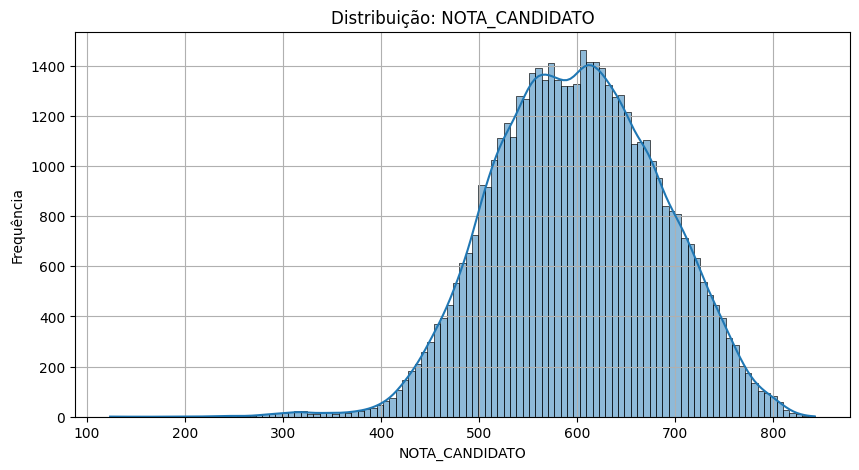

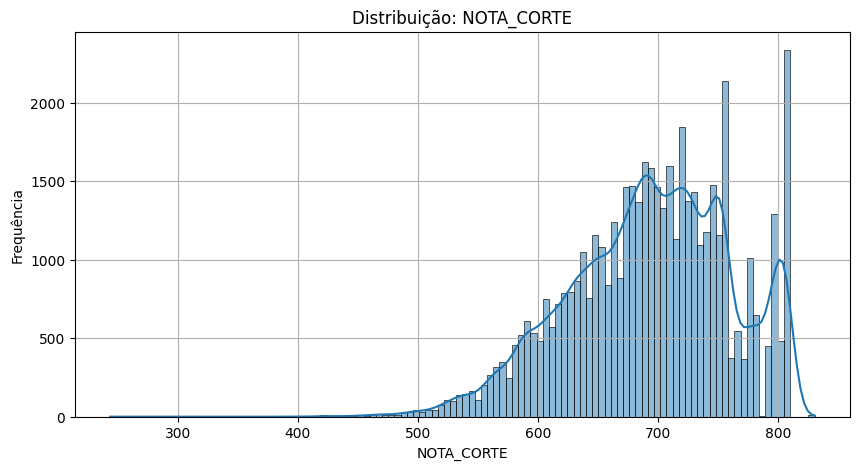

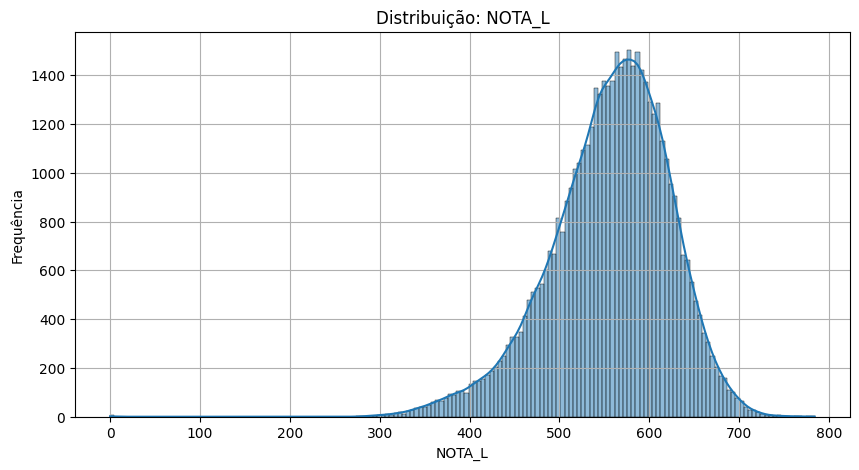

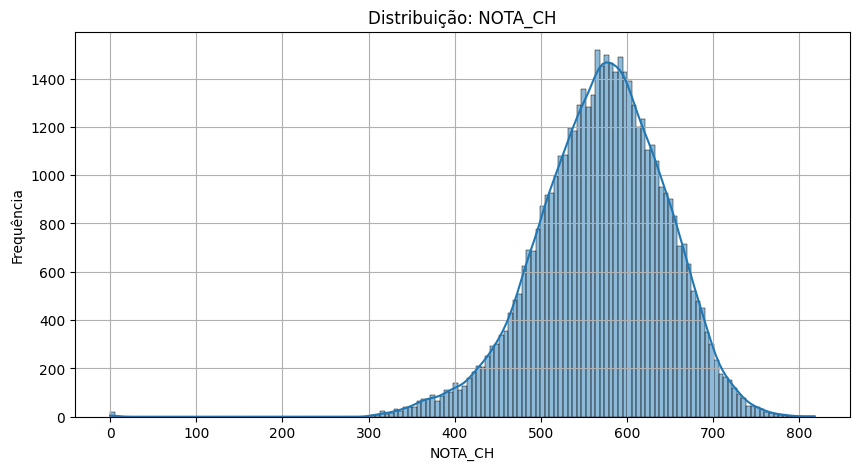

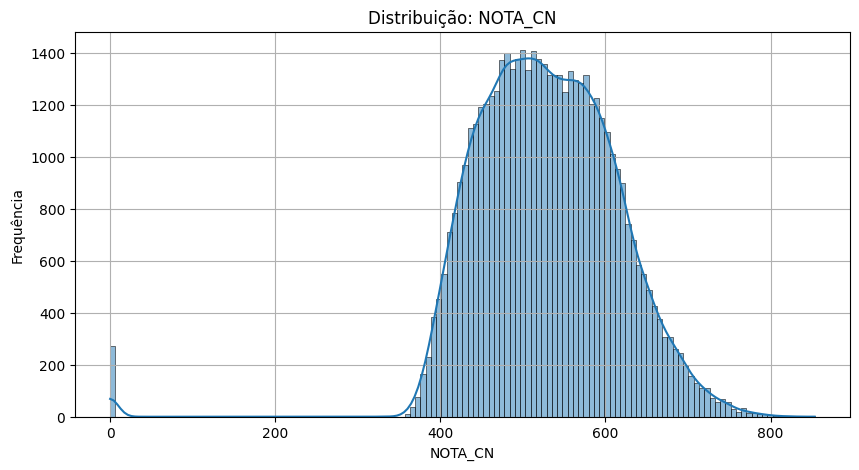

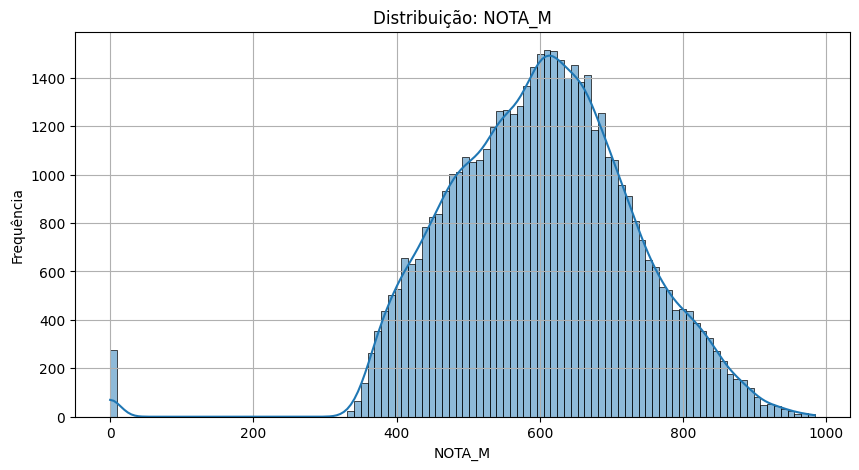

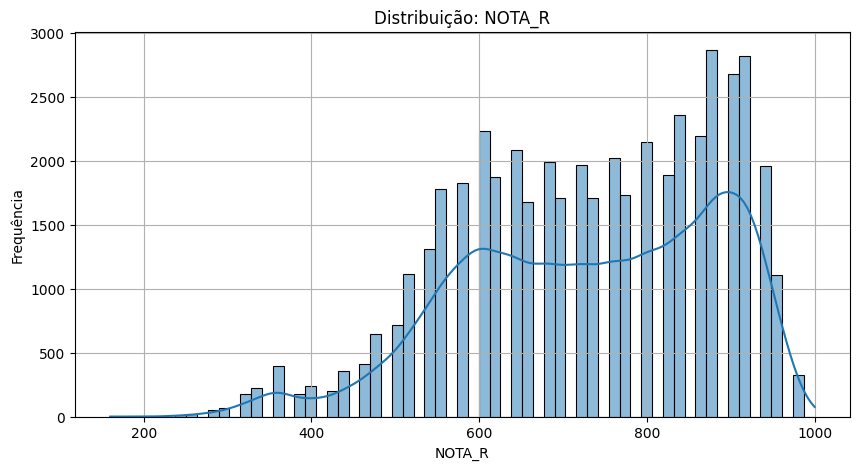

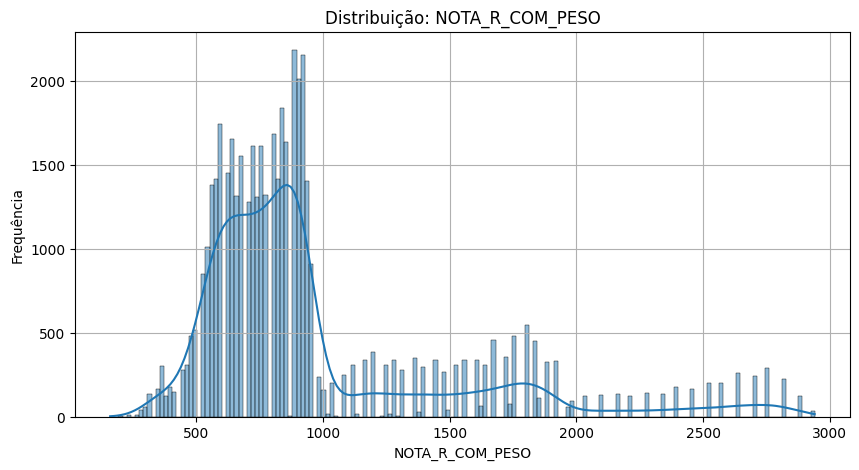

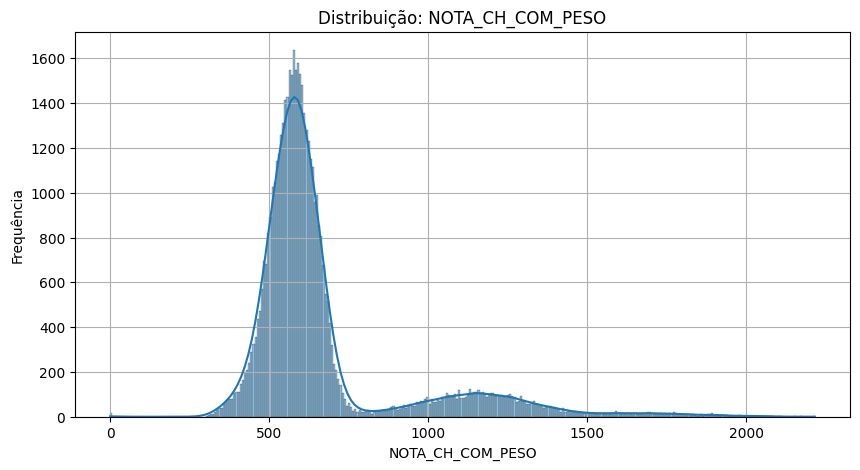

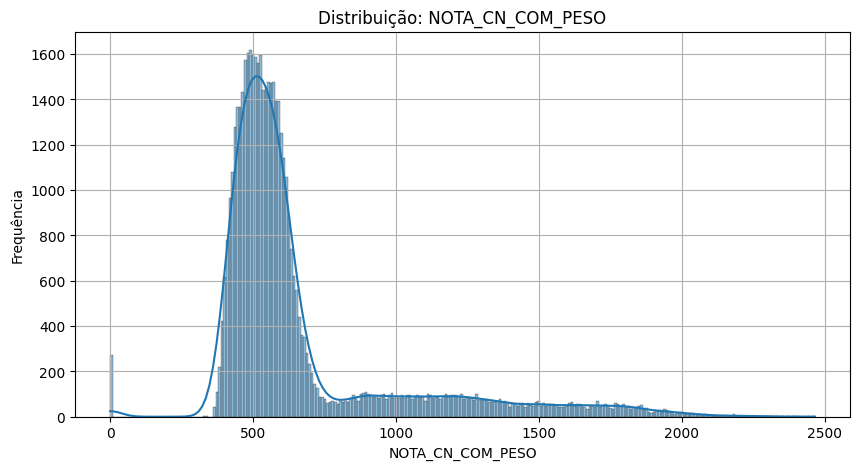

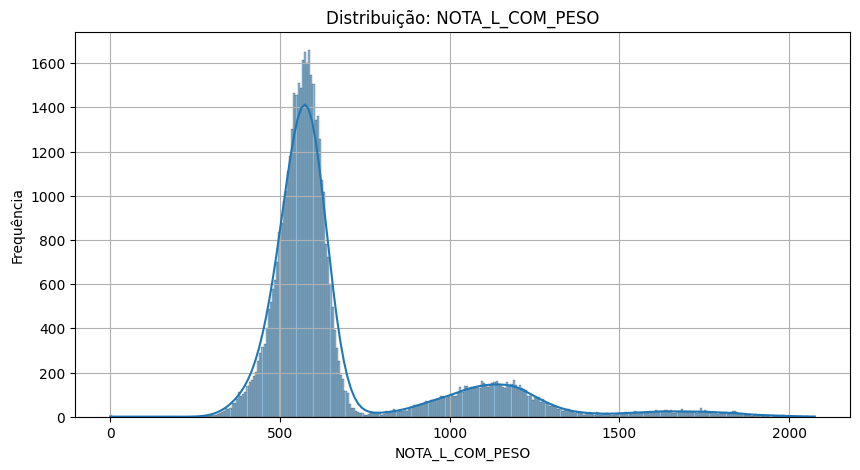

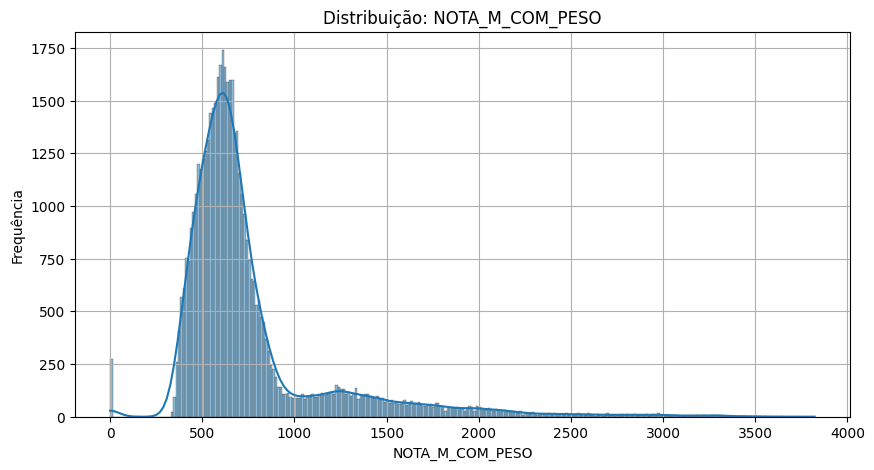

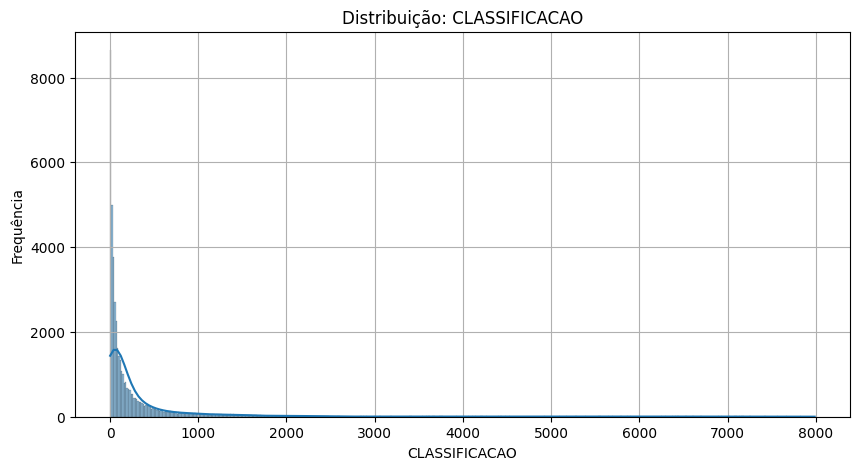

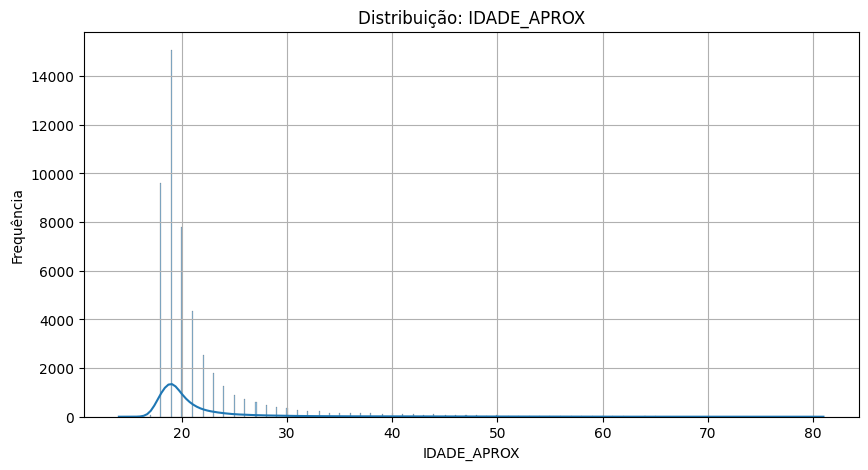

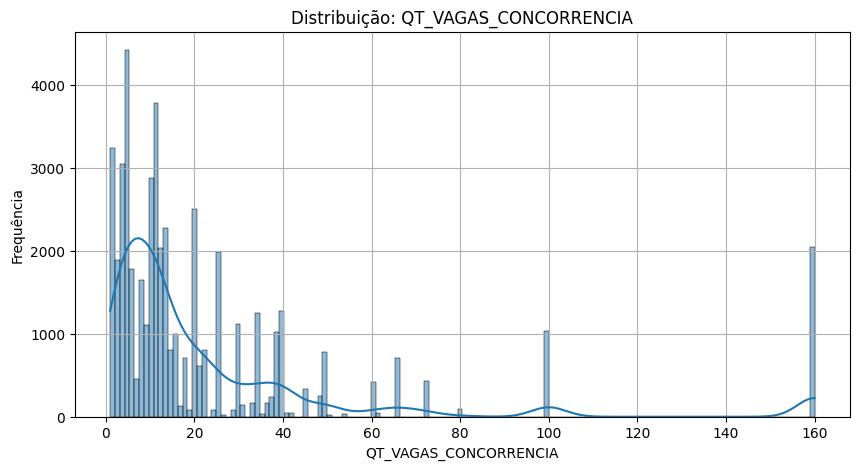

In [ ]:
amostrah = df_amostra.copy()

for var in variaveis_histograma:
    numeric_serie = pd.to_numeric(
        amostrah[var].astype(str).str.replace(',', '.'),
        errors='coerce'
    ).dropna()

    plt.figure(figsize=(10, 5))

    # Check if the series is empty after dropping NaNs, to avoid error with histogram_bin_edges
    if not numeric_serie.empty:
        # define bins automaticamente
        bins = np.histogram_bin_edges(numeric_serie, bins='fd')

        # decide se usa KDE
        usar_kde = numeric_serie.nunique() > 20

        sns.histplot(
            numeric_serie, # Use the numeric_serie
            bins=bins,
            kde=usar_kde
        )

        plt.title(f'Distribuição: {var}')
        plt.xlabel(var)
        plt.ylabel("Frequência")
        plt.grid(True)

        plt.show()
    else:
        print(f"Skipping plot for {var} as it contains no valid numeric data after cleaning.")


#### *Análise*

>| Observação                                                      | Significado                                                                       |
>| --------------------------------------------------------------- | --------------------------------------------------------------------------------- |
>| Média geral dos candidatos (600) vs. Corte (693)              | Existe um hiato de quase 100 pontos entre o desempenho médio e a nota necessária para aprovação, indicando alta competitividade. |
>| Matemática e Redação possuem os maiores tetos (983.9 e 1000) | São as disciplinas "motoras" da pontuação; o desempenho nelas define quem atinge o topo da pirâmide de classificação.|
>| Distribuição de Redação com média elevada (730.88) | A Redação não segue a TRI clássica; possui a maior média e mediana, tornando-se uma obrigação de alto desempenho, não um diferencial. |
>| Ciências da Natureza com a menor média (528.11) | Indica a maior dificuldade técnica da prova ou menor proficiência geral dos candidatos nesta área específica.|
>| Impacto massivo dos pesos em Matemática e Redação | O desvio padrão nas notas com peso (ex: 513.13 em Redação) mostra que os pesos amplificam drasticamente a distância entre os candidatos. |
>| Concentração etária extrema nos 19 anos (Pico 18.9-19.0) | O público é majoritariamente composto por recém-saídos do Ensino Médio, sugerindo um processo de seleção acadêmica tradicional. |
>| Curva de classificação com mediana 85 e pico no topo (1-16) | A maioria dos candidatos que aparecem nos dados está brigando nas primeiras posições, apesar da classificação máxima chegar a 7987. |

#### *Relação com falhas*

> Apesar de a distribuição geral ser equilibrada e próxima da normalidade (especialmente na nota dos candidatos, onde média e mediana são quase idênticas ~599), os dados revelam pontos críticos de vulnerabilidade:

> Risco de Zeramento: As notas mínimas de 0.00 em Linguagens, Humanas, Natureza e Matemática indicam falhas graves de execução ou ausência, o que anula qualquer chance de aproveitamento, dado que o corte mínimo registrado é de 243.70;

> A "Cauda da Redação": Embora o pico de Redação esteja entre 870 e 883, o mínimo de 160 é um ponto de falha catastrófica. Como a Redação tem peso alto (atingindo até 2940 pontos após ponderação), uma falha aqui é estatisticamente impossível de compensar nas outras áreas;

> Desclassificação por Natureza: Com o pico de notas em Natureza abaixo de 504 pontos, candidatos que não superam essa barreira tendem a ficar abaixo da média geral (599), sendo eliminados pela nota de corte que raramente desce de 690 pontos em cursos competitivos.

#### *Resumo*
> Esta análise conjunta demonstra um cenário de alta performance exigida. Enquanto o candidato médio flutua em torno de 600 pontos, o ecossistema de aprovação exige um patamar superior a 693 pontos.

> Matemática e Redação são os pilares de sucesso: Matemática pela amplitude de notas (chegando a quase 1000) e Redação pela consistência no topo. A disciplina de Ciências da Natureza atua como o principal "filtro" de dificuldade, apresentando as menores médias. Por fim, o perfil dos aprovados é jovem (19 anos) e a disputa é afunilada, com uma oferta de vagas (média de 24) muito inferior ao volume de candidatos, exigindo uma precisão quase cirúrgica nos pesos para garantir a classificação nas primeiras 16 posições.

## Matriz de Correlação (Mapa de Calor)

A Matriz de Correlação, também chamada de *Correlação de Pearson* ou *Mapa de Calor*, mede linearidade entre duas variáveis numéricas contínuas.

Em outras palavras, a matriz de correlação de Pearson mede o grau de relação linear entre pares de variáveis.

* Valores próximos de **1** = relação linear positiva forte
* Valores próximos de **−1** = relação linear negativa forte
* Valores próximos de **0** = pouca ou nenhuma relação linear

Este procedimento só deve ser usado para as features contínuas (temperatura, torque, desgaste, rotação, etc.).

In [ ]:
## converter colunas do tipo objct

cols = [
    'NOTA_L','NOTA_CH','NOTA_CN','NOTA_M',
    'NOTA_L_COM_PESO','NOTA_CH_COM_PESO','NOTA_CN_COM_PESO','NOTA_M_COM_PESO',
    'NOTA_CANDIDATO','NOTA_CORTE'
]

for col in cols:
    df_amostra[col] = df_amostra[col].astype(str).str.replace(',', '.').astype(float)

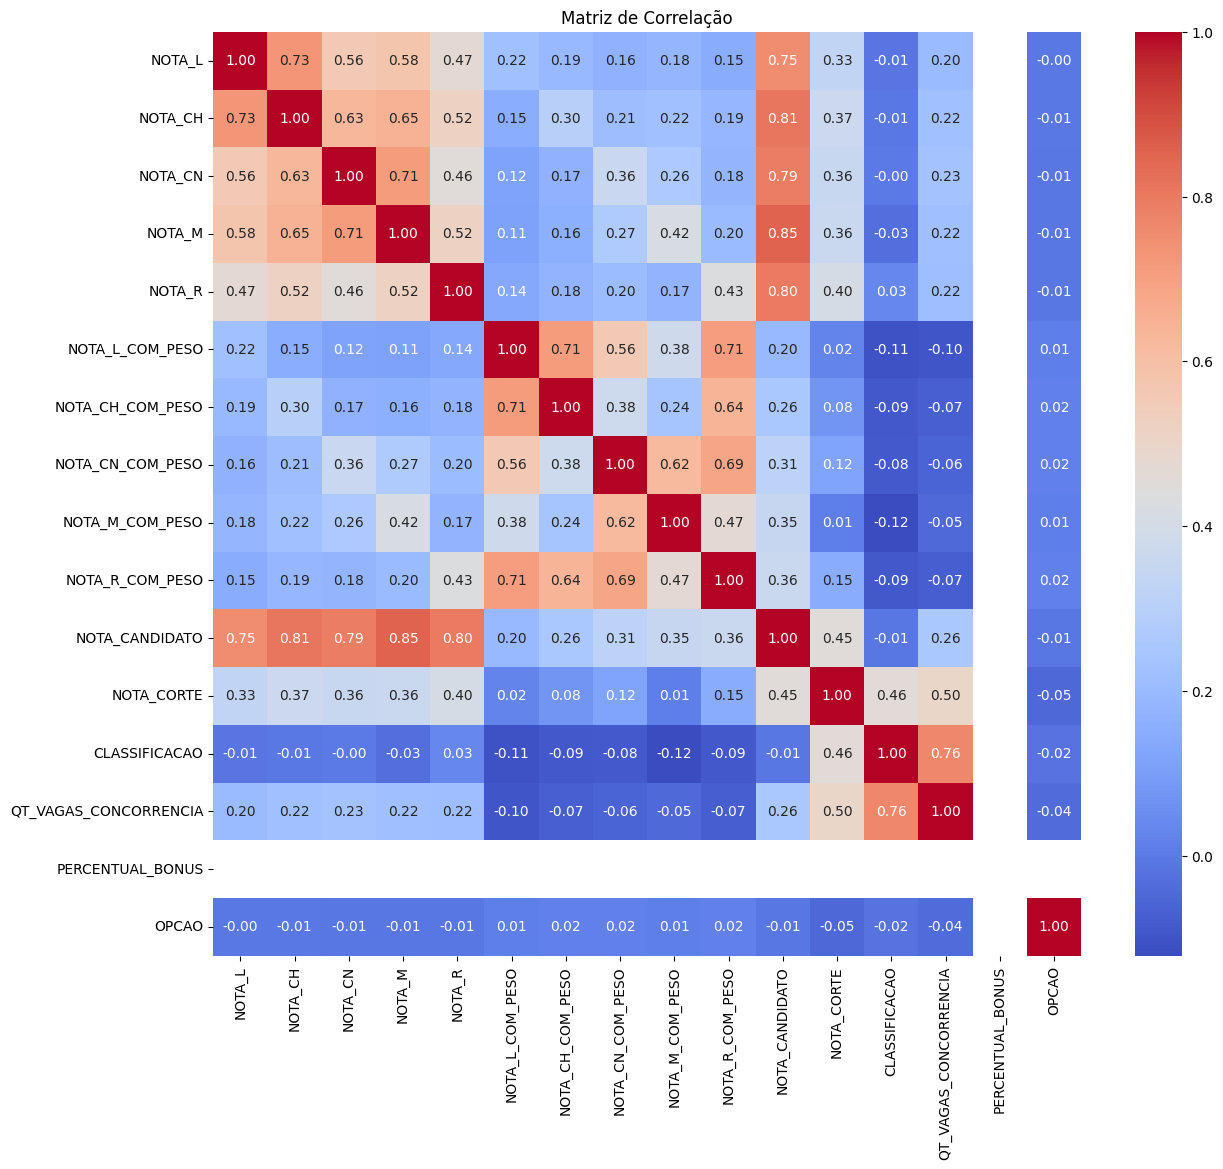

In [ ]:
variaveis = ['NOTA_L','NOTA_CH','NOTA_CN','NOTA_M','NOTA_R',
             'NOTA_L_COM_PESO','NOTA_CH_COM_PESO','NOTA_CN_COM_PESO','NOTA_M_COM_PESO',
             'NOTA_R_COM_PESO','NOTA_CANDIDATO','NOTA_CORTE','CLASSIFICACAO',
             'QT_VAGAS_CONCORRENCIA','PERCENTUAL_BONUS','OPCAO']
corr_matrix = df_amostra[variaveis].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()


== NOTA_L ==
Top 5 correlações positivas:
NOTA_CANDIDATO    0.753473
NOTA_CH           0.732190
NOTA_M            0.578293
NOTA_CN           0.558992
NOTA_R            0.470756
Name: NOTA_L, dtype: float64
Top 5 correlações negativas:
CLASSIFICACAO      -0.013872
OPCAO              -0.004795
NOTA_R_COM_PESO     0.149472
NOTA_CN_COM_PESO    0.163688
NOTA_M_COM_PESO     0.182527
Name: NOTA_L, dtype: float64

== NOTA_CH ==
Top 5 correlações positivas:
NOTA_CANDIDATO    0.811609
NOTA_L            0.732190
NOTA_M            0.645543
NOTA_CN           0.628916
NOTA_R            0.519070
Name: NOTA_CH, dtype: float64
Top 5 correlações negativas:
CLASSIFICACAO      -0.006774
OPCAO              -0.005358
NOTA_L_COM_PESO     0.154117
NOTA_R_COM_PESO     0.186412
NOTA_CN_COM_PESO    0.211501
Name: NOTA_CH, dtype: float64

== NOTA_CN ==
Top 5 correlações positivas:
NOTA_CANDIDATO    0.794014
NOTA_M            0.711346
NOTA_CH           0.628916
NOTA_L            0.558992
NOTA_R            0.45567

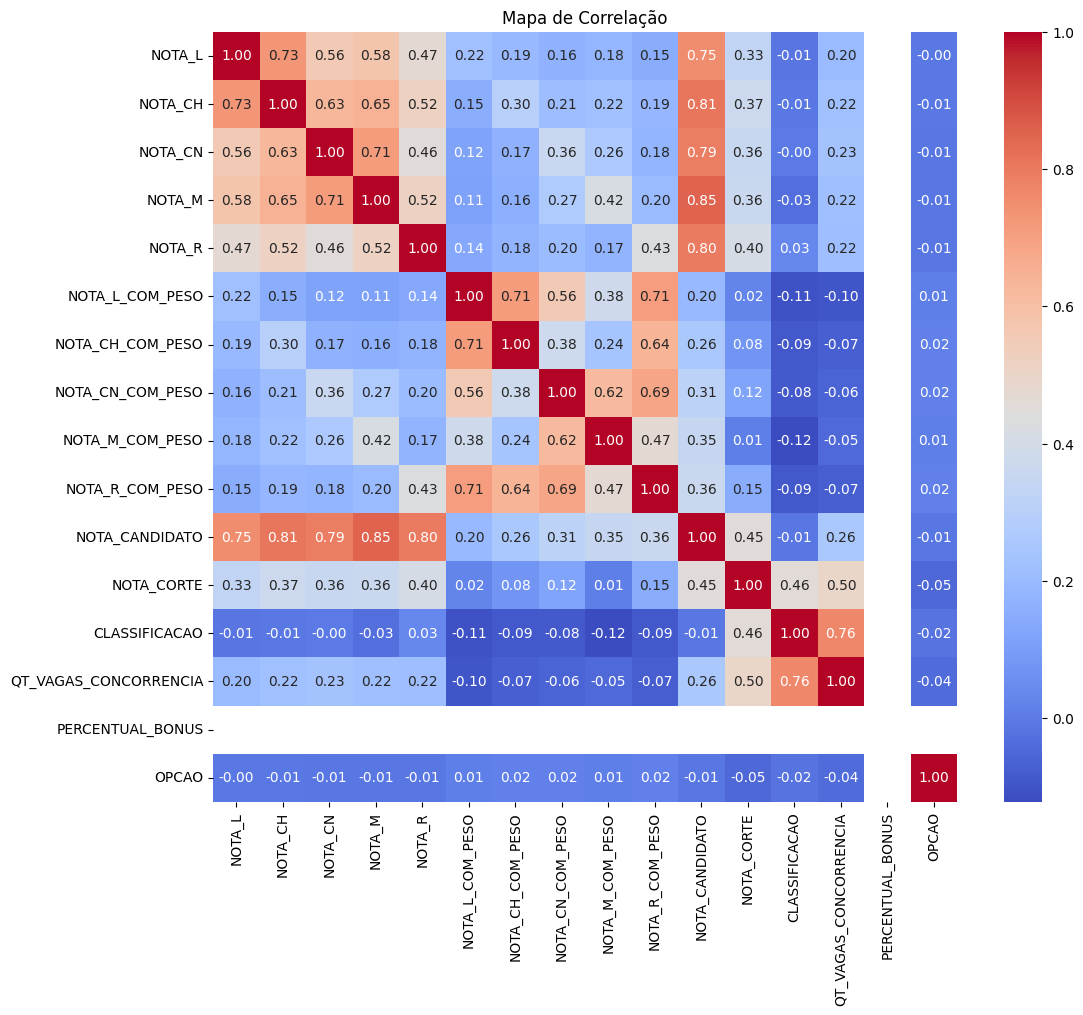

In [ ]:

# Lista de variáveis

variaveis = ['NOTA_L','NOTA_CH','NOTA_CN','NOTA_M','NOTA_R',
             'NOTA_L_COM_PESO','NOTA_CH_COM_PESO','NOTA_CN_COM_PESO',
             'NOTA_M_COM_PESO','NOTA_R_COM_PESO','NOTA_CANDIDATO',
             'NOTA_CORTE','CLASSIFICACAO','QT_VAGAS_CONCORRENCIA',
             'PERCENTUAL_BONUS','OPCAO']

# Seleciona as variáveis de interesse
df_corr = df_amostra[variaveis]

# Calcula a matriz de correlação
corr = df_corr.corr()

# Mostrar as top 5 correlações positivas e negativas de cada coluna
for col in corr.columns:
    print(f"\n== {col} ==")
    top5 = corr[col].sort_values(ascending=False)[1:6]  # maiores
    bottom5 = corr[col].sort_values()[:5]              # menores
    print("Top 5 correlações positivas:")
    print(top5)
    print("Top 5 correlações negativas:")
    print(bottom5)

# Visualização heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de Correlação")
plt.show()

In [ ]:

## 10 pares de variáveis com maior correlação

variaveis = ['NOTA_L','NOTA_CH','NOTA_CN','NOTA_M','NOTA_R',
             'NOTA_L_COM_PESO','NOTA_CH_COM_PESO','NOTA_CN_COM_PESO',
             'NOTA_M_COM_PESO','NOTA_R_COM_PESO','NOTA_CANDIDATO',
             'NOTA_CORTE','CLASSIFICACAO','QT_VAGAS_CONCORRENCIA',
             'PERCENTUAL_BONUS','OPCAO']

corr_matrix = df_amostra[variaveis].corr()

corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack()

corr_pairs = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)

# Imprime top 10 pares

print("Top 10 pares de correlação mais fortes:")
print(corr_pairs.head(10))

Top 10 pares de correlação mais fortes:
NOTA_M           NOTA_CANDIDATO           0.854653
NOTA_CH          NOTA_CANDIDATO           0.811609
NOTA_R           NOTA_CANDIDATO           0.796040
NOTA_CN          NOTA_CANDIDATO           0.794014
CLASSIFICACAO    QT_VAGAS_CONCORRENCIA    0.764218
NOTA_L           NOTA_CANDIDATO           0.753473
                 NOTA_CH                  0.732190
NOTA_L_COM_PESO  NOTA_CH_COM_PESO         0.712231
NOTA_CN          NOTA_M                   0.711346
NOTA_L_COM_PESO  NOTA_R_COM_PESO          0.708158
dtype: float64


In [ ]:
## Identficar correlação positiva/negativa

top10 = corr_pairs.head(10).reset_index()
top10.columns = ['Variável 1', 'Variável 2', 'Correlação']
top10['Sinal'] = top10['Correlação'].apply(lambda x: 'Positiva' if x > 0 else 'Negativa')
print(top10)

        Variável 1             Variável 2  Correlação     Sinal
0           NOTA_M         NOTA_CANDIDATO    0.854653  Positiva
1          NOTA_CH         NOTA_CANDIDATO    0.811609  Positiva
2           NOTA_R         NOTA_CANDIDATO    0.796040  Positiva
3          NOTA_CN         NOTA_CANDIDATO    0.794014  Positiva
4    CLASSIFICACAO  QT_VAGAS_CONCORRENCIA    0.764218  Positiva
5           NOTA_L         NOTA_CANDIDATO    0.753473  Positiva
6           NOTA_L                NOTA_CH    0.732190  Positiva
7  NOTA_L_COM_PESO       NOTA_CH_COM_PESO    0.712231  Positiva
8          NOTA_CN                 NOTA_M    0.711346  Positiva
9  NOTA_L_COM_PESO        NOTA_R_COM_PESO    0.708158  Positiva


### **Análise (heatmap)**

- **1. Relação entre notas individuais e nota do candidato**

   * Todas as notas individuais (NOTA_L, NOTA_CH, NOTA_CN, NOTA_M, NOTA_R) apresentam **correlação positiva e forte com a NOTA_CANDIDATO (0.75-0.85)**
   * Isso indica que a NOTA_CANDIDATO está fortemente associada ao desempenho nas cinco áreas, refletindo um agregado do desempenho geral, embora a forma exata de ponderação não possa ser confirmada apenas pelas correlações.
   * **Implicação no treinamento da IA**: modelos que tentam prever a nota do candidato podem utilizar as notas individuais como variáveis altamente explicativas. Porém, não faz sentido usar todas simultaneamente sem cuidado, pois há forte redundância entre elas.

- **2. Correlação entre áreas**

   * **Matematica x Ciências da Natureza:** **0.71 (alta e positiva)**: indica que candidatos com bom desempenho em raciocínio quantitativo tendem a ter desempenho consistente em ambas as áreas.
   * **Redação x outras áreas: 0.46-0.52 (moderada)**: mostra que a Redação possui certa independência em relação às demais áreas, mas ainda mantém relação moderada com todas.
   * **Linguagens x Ciências Humanas: 0.73 (alta)**: indica forte relação entre interpretação textual e desempenho em áreas humanas.

   **Conclusão Parcial**

   * Algumas áreas estão fortemente correlacionadas (Matemática/CN e Linguagens/CH), formando dois blocos principais de habilidades (quantitativo e verbal), enquanto Redação atua como um eixo parcialmente independente, mas ainda correlacionado com as demais áreas.
   * Para modelos de IA, essas notas podem ser usadas tanto para prever nota total quanto para classificação; porém, para evitar multicolinearidade, é recomendável agrupar ou reduzir variáveis correlacionadas.
   * Mostra que o desempenho em cada prova individual contribui significativamente para a nota final, com estrutura clara de redundância entre áreas semelhantes.

- **3. Nota de corte, Classificação e Concorrência**

   * **NOTA_CORTE correlaciona moderadamente com NOTA_CANDIDATO (0.45) e QT_VAGAS_CONCORRENCIA (0.50)**: mostra que cursos mais concorridos tendem a apresentar notas de corte mais altas, combinando desempenho dos candidatos e nível de competição.
   * **CLASSIFICAÇÃO está fortemente correlacionada com QT_VAGAS_CONCORRENCIA (0.76):** mostra que o ranking depende principalmente do contexto competitivo e da estrutura de vagas, e apresenta correlação muito baixa com as notas individuais.

   * Implicações Futuras:
     * **Predição de classificação** deve incluir fortemente variáveis de contexto (concorrência, vagas, nota de corte), além das notas.
     * **Predição de nota de corte** pode se beneficiar tanto das notas individuais quanto das variáveis de concorrência.

- **4. Variáveis Independentes**
  * **PERCENTUAL_BONUS** não apresentou correlação válida (NaN), indicando ausência de variação, dados insuficientes ou problema na variável. No estado atual, não pode ser utilizada em modelos.
  * **OPCAO** apresenta correlações muito baixas com as demais variáveis. No entanto, por ser uma variável possivelmente categórica, pode conter informação relevante não capturada por correlação linear, podendo ser útil em modelos mais avançados.


  **Conclusões**

- O dataset apresenta grupos de variáveis fortemente correlacionadas (Matemática/CN, Linguagens/CH, notas individuais/nota do candidato), indicando uma estrutura clara de redundância entre variáveis.

- Não é possível confirmar a fórmula exata de ponderação da NOTA_CANDIDATO apenas com base nas correlações, embora exista forte relação com as notas individuais.

- A CLASSIFICAÇÃO é fortemente influenciada pelo contexto competitivo (concorrência e vagas), e pouco explicada pelas notas individuais.

- Para modelos lineares, é importante tratar multicolinearidade (ex.: PCA ou seleção de variáveis).

- Para modelos baseados em árvore (XGB, RF), a multicolinearidade não impede o funcionamento, mas pode afetar a interpretação da importância das variáveis.



##Variance Inflation Factor (VIF)

VIF mede exatamente a multicolinearidade entre variáveis explicativas.
Quanto maior o VIF, mais uma variável está explicada pelas demais:

- VIF = 1 → sem correlação

- VIF entre 1 e 5 → correlação moderada, aceitável

- VIF > 5 (ou 10, dependendo do critério) → multicolinearidade preocupante

In [ ]:
df = df_dataset.copy()

In [ ]:
lista_nulos = df.isnull().sum().sort_values(ascending=False).reset_index().values.tolist()
print(lista_nulos)

[['PERCENTUAL_BONUS', 195607], ['TP_COTA', 107191], ['CLASSIFICACAO', 11446], ['NOTA_CORTE', 380], ['ETAPA', 0], ['NOME_IES', 0], ['SIGLA_IES', 0], ['EDICAO', 0], ['CODIGO_IES', 0], ['CODIGO_CAMPUS', 0], ['UF_IES', 0], ['NOME_CAMPUS', 0], ['UF_CAMPUS', 0], ['NOME_CURSO', 0], ['GRAU', 0], ['MUNICIPIO_CAMPUS', 0], ['CODIGO_CURSO', 0], ['DS_PERIODICIDADE', 0], ['TURNO', 0], ['MOD_CONCORRENCIA', 0], ['TIPO_MOD_CONCORRENCIA', 0], ['QT_VAGAS_CONCORRENCIA', 0], ['PESO_L', 0], ['DS_ETAPA', 0], ['ANO', 0], ['PESO_CN', 0], ['PESO_CH', 0], ['PESO_M', 0], ['PESO_R', 0], ['NOTA_MINIMA_CN', 0], ['NOTA_MINIMA_M', 0], ['NOTA_MINIMA_L', 0], ['NOTA_MINIMA_CH', 0], ['CPF', 0], ['INSCRICAO_ENEM', 0], ['INSCRITO', 0], ['SEXO', 0], ['DT_NASCIMENTO', 0], ['UF_CANDIDATO', 0], ['NOTA_MINIMA_R', 0], ['MEDIA_MINIMA', 0], ['OPCAO', 0], ['MUNICIPIO_CANDIDATO', 0], ['NOTA_L', 0], ['NOTA_CH', 0], ['NOTA_R', 0], ['NOTA_L_COM_PESO', 0], ['NOTA_CN', 0], ['NOTA_M', 0], ['NOTA_CN_COM_PESO', 0], ['NOTA_CH_COM_PESO', 0], [

In [ ]:
# Transformar Cotas
df['COTA_NUM'] = np.where(df['TIPO_MOD_CONCORRENCIA'] == 'A', 0, 1)

# Transformar Turno
mapa_turno = {'Noturno': 0, 'Matutino': 1, 'Vespertino': 1, 'Integral': 2}
df['TURNO_NUM'] = df['TURNO'].map(mapa_turno)

# Transformar Grau
mapa_grau = {'Licenciatura': 0, 'Tecnológico': 1, 'Bacharelado': 2}
df['GRAU_NUM'] = df['GRAU'].map(mapa_grau)

# Criar a Idade
df['IDADE'] = 2023 - pd.to_numeric(df_amostra['DT_NASCIMENTO'].astype(str).str[:4], errors='coerce')

In [ ]:
# CRIANDO AS COLUNAS NUMÉRICAS PARA SEXO E APROVAÇÃO
df['SEXO_NUM'] = df['SEXO'].map({'M': 0, 'F': 1})
df['APROVADO_NUM'] = df['APROVADO'].map({'S': 1, 'N': 0})

# FORÇA CONVERSÃO NUMÉRICA (AGORA COM AS COLUNAS NOVAS)
variaveis = ['NOTA_L','NOTA_CH','NOTA_CN','NOTA_M','NOTA_R',
             'PESO_L', 'PESO_CH', 'PESO_CN', 'PESO_M', 'PESO_R',
             'NOTA_L_COM_PESO','NOTA_CH_COM_PESO','NOTA_CN_COM_PESO',
             'NOTA_M_COM_PESO','NOTA_R_COM_PESO', 'NOTA_CANDIDATO',
             'NOTA_CORTE','CLASSIFICACAO','QT_VAGAS_CONCORRENCIA',
             'PERCENTUAL_BONUS','OPCAO', 'SEXO_NUM', 'APROVADO_NUM',
             'COTA_NUM','TURNO_NUM', 'GRAU_NUM', 'IDADE']

for col in variaveis:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', '.'),
        errors='coerce'
    )

# PREENCHE OS NULOS COM ZERO PARA NÃO APAGAR NENHUM ALUNO
X = df[variaveis].fillna(0)

# CALCULA VIF
X_const = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variável"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i)
              for i in range(X_const.shape[1])]

print(vif.round(2))

                 Variável     VIF
0                   const  869.09
1                  NOTA_L   19.71
2                 NOTA_CH   22.43
3                 NOTA_CN   20.30
4                  NOTA_M   23.38
5                  NOTA_R   33.04
6                  PESO_L  112.29
7                 PESO_CH   90.46
8                 PESO_CN   61.12
9                  PESO_M   42.01
10                 PESO_R   35.22
11        NOTA_L_COM_PESO  118.30
12       NOTA_CH_COM_PESO  100.52
13       NOTA_CN_COM_PESO   69.15
14        NOTA_M_COM_PESO   50.23
15        NOTA_R_COM_PESO   47.50
16         NOTA_CANDIDATO  241.44
17             NOTA_CORTE    2.24
18          CLASSIFICACAO    3.07
19  QT_VAGAS_CONCORRENCIA    3.41
20       PERCENTUAL_BONUS    2.24
21                  OPCAO    1.02
22               SEXO_NUM    1.14
23           APROVADO_NUM    1.29
24               COTA_NUM    1.31
25              TURNO_NUM    1.46
26               GRAU_NUM    1.28
27                  IDADE    1.00


### *Análise*

* **const** → 869.09
* **NOTA_L** → 19.71
* **NOTA_CH** → 22.43
* **NOTA_CN** → 20.30
* **NOTA_M** → 23.38
* **NOTA_R** → 33.04
* **PESO_L** → 112.29
* **PESO_CH** → 90.46
* **PESO_CN** → 61.12
* **PESO_M** → 42.01
* **PESO_R** → 35.22
* **NOTA_L_COM_PESO** → 118.30
* **NOTA_CH_COM_PESO** → 100.52
* **NOTA_CN_COM_PESO** → 69.15
* **NOTA_M_COM_PESO** → 50.23
* **NOTA_R_COM_PESO** → 47.50
* **NOTA_CANDIDATO** → 241.44
* **NOTA_CORTE** → 2.24
* **CLASSIFICACAO** → 3.07
* **QT_VAGAS_CONCORRENCIA** → 3.41
* **PERCENTUAL_BONUS** → 2.24
* **OPCAO** → 1.02
* **SEXO_NUM** → 1.14
* **APROVADO_NUM** → 1.29
* **COTA_NUM** → 1.31
* **TURNO_NUM** → 1.46
* **GRAU_NUM** → 1.28
* **IDADE** → 1.00

### *Interpretação*

- A variável **NOTA_CANDIDATO** apresentou VIF extremamente alto (**241.44**), confirmando que ela é uma combinação linear das notas individuais e ponderadas.
- As notas com peso (**NOTA_xxx_COM_PESO**) e os próprios **PESOS** também geraram VIFs muito elevados (vários acima de 100), mostrando forte redundância entre as notas brutas, as versões ponderadas e os pesos das provas.
- As notas brutas (especialmente **NOTA_R** com 33.04 e **NOTA_M** com 23.38) já indicam multicolinearidade considerável entre as áreas do ENEM.
- Por outro lado, variáveis como **NOTA_CORTE**, **QT_VAGAS_CONCORRENCIA**, **CLASSIFICACAO**, **PERCENTUAL_BONUS**, **OPCAO** e as variáveis categóricas numéricas (SEXO_NUM, TURNO_NUM, GRAU_NUM, etc.) mantiveram VIF baixo (próximo de 1 a 3), sendo as mais independentes e úteis.

### *Conclusão*

A análise de VIF mostrou que o dataset possui **multicolinearidade forte e generalizada**, principalmente causada pela inclusão simultânea das notas brutas, notas com peso, pesos das provas e da nota final do candidato (`NOTA_CANDIDATO`).

Isso indica que muitas variáveis estão carregando informação repetida, o que pode comprometer a estabilidade e a interpretabilidade dos modelos de Machine Learning.

Será necessário realizar uma limpeza importante antes da modelagem:
- Remover **NOTA_CANDIDATO** (altamente redundante)
- Decidir quais notas manter (brutas × ponderadas)
- Possivelmente dropar os **PESOS** das provas (`PESO_L`, `PESO_CH`, etc.), pois estão gerando redundância extrema
- Manter as variáveis estruturais (`NOTA_CORTE`, `QT_VAGAS_CONCORRENCIA`, `CLASSIFICACAO`) que se mostraram independentes e relevantes

# **Engenharia de Dados**
Objetivos:

- Tratamento dos valores nulos;

- Tratamento dos registros duplicados;

- Codificação de variáveis categóricas;

- Criação de variáveis derivadas (features);

- Redução de dimensionalidade;

- Etc.

## Transformar determinadas colunas em Número

Para que os dados possam ser utilizados de forma adequada em modelos de IA, é necessário realizar um pre-processamento das variáveis categóricas, pois, os modelos - em sua maioria - trabalham melhor com valores numéricos.
Dessa forma, foi realizada a transformação de algumas variáveis do conjunto de dados, atribuindo valores inteiros a cada categoria existente.

Obs: as colunas que passaram por esse tratamento receberam o sufixo “_T” em sua nomenclatura, a fim de diferenciá-las das variáveis originais — por exemplo, a coluna **APROVADO** passou a ser representada como **APROVADO_T**.

Portanto, vamos criar novas colunas no DF, `APROVADO`, com a seguinte correlação:
- `Não`: 0,
- `Sim`: 1

Alteramos a coluna `GRAU`, com a seguinte correlação:
- `Bacharelado`: 0,
- `Licenciatura`: 1,
- `Tecnológico`: 2,
- `Área Básica de Ingresso (ABI)`: 3

Alteramos a coluna `TURNO`, com a seguinte correlação:
- `EaD`: 0,
- `Integral`: 1,
- `Matutino`: 2,
- `Noturno`: 3,
- `Vespertino`: 4

Alteramos a coluna `DS_PERIODICIDADE`, com a seguinte correlação:
- `Anual`: 0,
- `Semestral`: 1

Alteramos a coluna `TIPO_MOD_CONCORRENCIA`, com a seguinte correlação:
- `A`: 0,
- `B`: 1,
- `L`: 2,
- `V`: 3


### **Tratando Variáveis Categóricas**

In [ ]:
# Etapa 1: Lista das variáveis que vamos transformar
categorical_cols = [
    'APROVADO', 'GRAU', 'TURNO',
    'DS_PERIODICIDADE',
    'TIPO_MOD_CONCORRENCIA'
]

# Etapa 2: Criar colunas _T para cada categórica
for col in categorical_cols:
    # Preencher NaN se existir
    df_dataset[col] = df_dataset[col].fillna('NA')

    # Etapa 3: Criar dicionário de mapeamento
    unique_vals = df_dataset[col].unique()
    mapping = {val: i for i, val in enumerate(unique_vals)}

    # Etapa 4: Criar coluna transformada
    df_dataset[col + '_T'] = df_dataset[col].map(mapping)

# Mostrar algumas linhas para conferir
df_dataset[[col + '_T' for col in categorical_cols]].head(15)

,APROVADO_T,GRAU_T,TURNO_T,DS_PERIODICIDADE_T,TIPO_MOD_CONCORRENCIA_T
0,0,0,0,0,0
1,0,0,0,0,0
2,1,0,0,0,0
3,0,0,0,0,0
4,1,0,0,0,0
5,0,0,0,0,0
6,1,0,0,0,0
7,1,0,0,0,0
8,1,0,0,0,0
9,0,0,0,0,0


In [ ]:
# importr LabelEncoder para auxiliar no processo de identificação
from sklearn.preprocessing import LabelEncoder

# Dicionário para identificar os mapeamentos
mapping_dict = {}

for col in categorical_cols:
    unique_vals = df_dataset[col].unique()
    if len(unique_vals) == 2:
        mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
    else:
        le = LabelEncoder()
        le.fit(df_dataset[col].astype(str))  # garante que todos sejam string
        mapping = {val: int(le.transform([val])[0]) for val in unique_vals}
    mapping_dict[col] = mapping

# Mostrar mapeamentos
for col, mapping in mapping_dict.items():
    print(f"\nColuna: {col}")
    for k, v in mapping.items():
        print(f"  {k} -> {v}")


Coluna: APROVADO
  N -> 0
  S -> 1

Coluna: GRAU
  Bacharelado -> 0
  Tecnológico -> 2
  Licenciatura -> 1
  Área Básica de Ingresso (ABI) -> 3

Coluna: TURNO
  Integral -> 1
  Noturno -> 3
  Matutino -> 2
  Vespertino -> 4
  EaD -> 0

Coluna: DS_PERIODICIDADE
  Anual -> 0
  Semestral -> 1

Coluna: TIPO_MOD_CONCORRENCIA
  A -> 0
  L -> 2
  V -> 3
  B -> 1


In [ ]:
## Consultar as colunas + colunas novas
print(df_dataset.columns.tolist())

['ANO', 'EDICAO', 'ETAPA', 'DS_ETAPA', 'CODIGO_IES', 'NOME_IES', 'SIGLA_IES', 'UF_IES', 'CODIGO_CAMPUS', 'NOME_CAMPUS', 'UF_CAMPUS', 'MUNICIPIO_CAMPUS', 'CODIGO_CURSO', 'NOME_CURSO', 'GRAU', 'TURNO', 'DS_PERIODICIDADE', 'TP_COTA', 'TIPO_MOD_CONCORRENCIA', 'MOD_CONCORRENCIA', 'QT_VAGAS_CONCORRENCIA', 'PERCENTUAL_BONUS', 'PESO_L', 'PESO_CH', 'PESO_CN', 'PESO_M', 'PESO_R', 'NOTA_MINIMA_L', 'NOTA_MINIMA_CH', 'NOTA_MINIMA_CN', 'NOTA_MINIMA_M', 'NOTA_MINIMA_R', 'MEDIA_MINIMA', 'CPF', 'INSCRICAO_ENEM', 'INSCRITO', 'SEXO', 'DT_NASCIMENTO', 'UF_CANDIDATO', 'MUNICIPIO_CANDIDATO', 'OPCAO', 'NOTA_L', 'NOTA_CH', 'NOTA_CN', 'NOTA_M', 'NOTA_R', 'NOTA_L_COM_PESO', 'NOTA_CH_COM_PESO', 'NOTA_CN_COM_PESO', 'NOTA_M_COM_PESO', 'NOTA_R_COM_PESO', 'NOTA_CANDIDATO', 'NOTA_CORTE', 'CLASSIFICACAO', 'APROVADO', 'MATRICULA', 'IDADE_APROX', 'APROVADO_T', 'GRAU_T', 'TURNO_T', 'DS_PERIODICIDADE_T', 'TIPO_MOD_CONCORRENCIA_T']


### **Transformando Variáveis do Tipo Object**

In [ ]:
# Etapa 1: Mostrar todas as variáveis e seus tipos
df_dataset.dtypes

,0
ANO,int64
EDICAO,int64
ETAPA,int64
DS_ETAPA,object
CODIGO_IES,int64
...,...
APROVADO_T,int64
GRAU_T,int64
TURNO_T,int64
DS_PERIODICIDADE_T,int64


In [ ]:
# Etapa 2: Filtrar apenas as colunas do tipo object

# Filtra as colunas do tipo object
object_cols = df_dataset.select_dtypes(include='object').columns.tolist()

# Cria um DataFrame auxiliar para exibição
df_resumo_object = pd.DataFrame({
    'Índice': range(1, len(object_cols) + 1),
    'Coluna Tipo Object': object_cols
})

# Exibe em formato de tabela
if not object_cols:
    print("Nenhuma coluna do tipo 'object' foi encontrada.")
else:
    print(f"Foram encontradas {len(object_cols)} colunas do tipo object:")
    display(df_resumo_object)

Foram encontradas 43 colunas do tipo object:


,Índice,Coluna Tipo Object
0,1,DS_ETAPA
1,2,NOME_IES
2,3,SIGLA_IES
3,4,UF_IES
4,5,NOME_CAMPUS
5,6,UF_CAMPUS
6,7,MUNICIPIO_CAMPUS
7,8,NOME_CURSO
8,9,GRAU
9,10,TURNO


In [ ]:
# Colunas que devem ser numéricas
numeric_object_cols = [
    'PESO_L', 'PESO_CH', 'PESO_CN', 'PESO_M', 'PESO_R',
    'NOTA_MINIMA_L', 'NOTA_MINIMA_CH', 'NOTA_MINIMA_CN',
    'NOTA_MINIMA_M', 'NOTA_MINIMA_R', 'MEDIA_MINIMA',
    'NOTA_L', 'NOTA_CH', 'NOTA_CN', 'NOTA_M',
    'NOTA_L_COM_PESO', 'NOTA_CH_COM_PESO',
    'NOTA_CN_COM_PESO', 'NOTA_M_COM_PESO',
    'NOTA_CANDIDATO', 'NOTA_CORTE'
]

status_conversao = []

for col in numeric_object_cols:

    if col not in df_dataset.columns:
        status_conversao.append({
            "coluna": col,
            "status": "Coluna não encontrada",
            "antes": None,
            "depois": None,
            "valores_invalidos": None
        })
        continue

    dtype_antes = df_dataset[col].dtype

    # Padronizar (corrigir vírgula e espaços)
    df_dataset[col] = (
        df_dataset[col]
        .astype(str)
        .str.strip()
        .str.replace(',', '.', regex=False)
    )

    # Converter para número
    convertido = pd.to_numeric(df_dataset[col], errors='coerce')

    # Contar valores que viraram NaN
    invalidos = convertido.isna().sum()

    df_dataset[col] = convertido

    dtype_depois = df_dataset[col].dtype

    status_conversao.append({
        "coluna": col,
        "status": "Convertida",
        "antes": str(dtype_antes),
        "depois": str(dtype_depois),
        "valores_invalidos": int(invalidos)
    })

# Relatório
df_status = pd.DataFrame(status_conversao)

print("Relatório de Conversão de Tipos:")
display(df_status)

Relatório de Conversão de Tipos:


,coluna,status,antes,depois,valores_invalidos
0,PESO_L,Convertida,object,float64,0
1,PESO_CH,Convertida,object,float64,0
2,PESO_CN,Convertida,object,float64,0
3,PESO_M,Convertida,object,float64,0
4,PESO_R,Convertida,object,float64,0
5,NOTA_MINIMA_L,Convertida,object,float64,0
6,NOTA_MINIMA_CH,Convertida,object,float64,0
7,NOTA_MINIMA_CN,Convertida,object,float64,0
8,NOTA_MINIMA_M,Convertida,object,float64,0
9,NOTA_MINIMA_R,Convertida,object,float64,0


*Análise*

Nesta etapa, seguimos uma abordagem para preparar os dados para análise ou modelagem. As etapas foram:

1.   **Análise das variáveis categóricas**: foram identificadas as variáveis categóricas, sendo elas: APROVADO, GRAU, TURNO, DS_PERIODICIDADE e TIPO_MOD_CONCORRENCIA; Cada coluna foi investigada para entender valores únicos e suas frequências; Em seguida, foram transformadas em variáveis numéricas: para colunass **binárias**, foi usado mapeamento direto (ex.: S/N → 1/0), e para colunas com **mais de dois valores** foi aplicado *label encoding*, garantindo que todos os valores fossem representados numericamente.

2. **Conversão de variáveis numéricas armazenadas como texto (object)**: As colunas originalmente numéricas, mas armazenadas como *object* (como notas, pesos e médias), foram identificadas; Colunas de **texto livre** ou identificadores (como nomes de campus, cursos, CPF, inscrição ENEM) foram preservadas como *object*; As colunas numéricas foram convertidas para *float*, garantindo uma melhor manipulação desses dados.

Entende-se que após a aplicação destas etapas, garantimos um dataset consistente e pronto para análises quantitativas e para uso em modelos de ML, com tipos de variáveis adequados e as variáveis categóricas devidamente codificadas.







## Valores zerados


### 1. Identificação dos Valores

Antes de iniciar a análise de desempenho, identificamos o volume de candidatos que obtiveram nota zero em cada competência. Notas zero geralmente indicam ausência no segundo dia de prova, desclassificação ou abandono.


> **Ciências da Natureza e Matemática** - Concentram o maior volume de zeros (>1000 casos), o que é comum por serem aplicadas no mesmo dia.


In [ ]:
# colunas_selecionadas = ['NOTA_L', 'NOTA_CH', 'NOTA_CN', 'NOTA_M', 'NOTA_R', 'NOTA_CORTE', 'NOTA_CANDIDATO']

# zeros_por_materia = (df_dataset[colunas_selecionadas] == 0).sum()

# # Transforma em um DataFrame para ficar bonito
# df_zeros = zeros_por_materia.reset_index()
# df_zeros.columns = ['Matéria', 'Quantidade de Zeros']
# print(df_zeros)

In [ ]:
# # Calculamos os quantis
# cortes = df_dataset[colunas_selecionadas].quantile([0.00001, 0.25, 0.5, 0.75])

# df_tabela_cortes = cortes.T
# df_tabela_cortes.columns = ['Mínimo (Aprox.)', '25% (Baixa)', '50% (Média)', '75% (Alta)']

# display(df_tabela_cortes.style.format("{:.2f}").background_gradient(cmap='Blues'))

In [ ]:
# # Criamos uma máscara booleana: True para linhas onde nenhuma das colunas é 0
# df_dataset_tratado = df_dataset[(df_dataset[colunas_selecionadas] != 0).all(axis=1)].copy()

# print(f"Linhas antes: {len(df_dataset)}")
# print(f"Linhas depois: {len(df_dataset_tratado)}")
# print(f"Removidos: {len(df_dataset) - len(df_dataset_tratado)} registros.")

### 2. Análise de Variação
A tabela de variação abaixo é a prova do impacto que notas extremas (zeros) causam na percepção do grupo.

Insights da Variação:
**O Mínimo Real**: Note que a nota mínima de Matemática saltou de 0.00 para 336.90. Isso significa que ninguém que realmente fez a prova e pontuou ficou abaixo desse patamar.

**Impacto nos 25% (Base da Pirâmide)**: A maior subida ocorreu em Matemática (+1.80) e Natureza (+0.90). Isso prova que os zeros estavam "sujando" principalmente o primeiro quartil, fazendo parecer que a nota baixa era mais comum do que realmente é entre candidatos ativos.

**Estabilidade no Topo**: No quartil de 75% (notas altas), a variação foi mínima (ex: +0.20 em Linguagens). Isso mostra que os zeros não afetam quem está no topo, apenas distorcem a visão da média e da base.

In [ ]:
# # 1. Garanta que estamos subtraindo os valores brutos
# cortes_antigo = df_dataset[colunas_selecionadas].quantile([0.00001, 0.25, 0.5, 0.75]).T
# cortes_limpo  = df_dataset_tratado[colunas_selecionadas].quantile([0.00001, 0.25, 0.5, 0.75]).T

# # 2. Agora a subtração vai funcionar porque os índices são idênticos
# df_variacao = cortes_limpo - cortes_antigo

# df_variacao.columns = ['Mínimo (Aprox.)', '25% (Baixa)', '50% (Média)', '75% (Alta)']

# print("Variação Real (O quanto a nota subiu após tirar os zeros):")
# display(df_variacao.style.format("+{:.2f}").background_gradient(cmap='Greens'))

#### **Conclusão do Relatório**
O dataset agora reflete a realidade competitiva. Com a remoção dos registros nulos, as médias subiram de forma generalizada, especialmente em Matemática e Natureza. Para um candidato, isso significa que a nota de corte real é mais "fechada" e competitiva do que os dados brutos sugeriam inicialmente.

In [ ]:
df_dataset_tratado = df_dataset.copy()

## Tratar valores de idades

Nesta etapa, transformamos a variável contínua IDADE_APROX em categorias qualitativas. Isso permite identificar não apenas a idade, mas o momento de vida do candidato no processo seletivo.

In [ ]:
bins = [0, 14, 17, 18, 19, 21, 26, 40, 55, 90]

labels = [
    'Sub-14 (Muito Jovens)', # 0 a 14
    '15-17 (Treineiros)',    # 14 a 17
    '18 anos (Candidato Padrão)', # 17 a 18
    '19 anos (Pico)',        # 18 a 19
    '20-21 anos (Veteranos)',# 19 a 21
    '22-26 anos (Adultos Jovens)', # 21 a 26
    '27-40 anos (Reingresso)',# 26 a 40
    '41-55 anos',
    '56+ anos'
]

df_dataset_tratado['FAIXA_ETARIA'] = pd.cut(
    df_dataset_tratado['IDADE_APROX'],
    bins=bins,
    labels=labels,
    right=True
)

# 4. Verificando a contagem
display(df_dataset_tratado['FAIXA_ETARIA'].value_counts().sort_index())

,count
FAIXA_ETARIA,
Sub-14 (Muito Jovens),2
15-17 (Treineiros),353
18 anos (Candidato Padrão),39410
19 anos (Pico),60390
20-21 anos (Veteranos),47608
22-26 anos (Adultos Jovens),29185
27-40 anos (Reingresso),14102
41-55 anos,4120
56+ anos,925


In [ ]:
percentual = df_dataset_tratado['FAIXA_ETARIA'].value_counts(normalize=True) * 100
print(percentual.sort_index().map("{:.2f}%".format))

FAIXA_ETARIA
Sub-14 (Muito Jovens)           0.00%
15-17 (Treineiros)              0.18%
18 anos (Candidato Padrão)     20.10%
19 anos (Pico)                 30.80%
20-21 anos (Veteranos)         24.28%
22-26 anos (Adultos Jovens)    14.88%
27-40 anos (Reingresso)         7.19%
41-55 anos                      2.10%
56+ anos                        0.47%
Name: proportion, dtype: object


In [ ]:
df_antes_da_idade = df_dataset_tratado.copy()

df_dataset_tratado = df_dataset_tratado[
    (df_dataset_tratado['IDADE_APROX'] >= 15) &
    (df_dataset_tratado['IDADE_APROX'] <= 55)
].copy()

if df_dataset_tratado['FAIXA_ETARIA'].dtype.name == 'category':
    df_dataset_tratado['FAIXA_ETARIA'] = df_dataset_tratado['FAIXA_ETARIA'].cat.remove_unused_categories()

df_dataset_tratado = df_dataset_tratado.reset_index(drop=True)

df_dataset_tratado = df_dataset_tratado.drop(columns=['FAIXA_ETARIA'])

print(f"Linhas antes do filtro de idade: {len(df_antes_da_idade)}")
print(f"Linhas após limpeza de idade: {len(df_dataset_tratado)}")

removidos_nesta_etapa = len(df_antes_da_idade) - len(df_dataset_tratado)
print(f"Outliers de idade removidos nesta etapa: {removidos_nesta_etapa} registros.")


Linhas antes do filtro de idade: 196095
Linhas após limpeza de idade: 195168
Outliers de idade removidos nesta etapa: 927 registros.


### Outliers de Idade

Para aumentar a confiabilidade estatística, aplicamos um filtro de Público Ativo. Candidatos abaixo de 15 anos ou acima de 55 anos foram removidos por representarem menos de 0,5% da amostra e possuírem comportamentos de nota que não refletem a massa competitiva.

##Valores Nulos



In [ ]:
df_amostra.isnull().sum()\
    .sort_values(ascending=False)\
    .to_frame(name='qtd_nulos')\
    .head(25)

,qtd_nulos
PERCENTUAL_BONUS,48905
TP_COTA,26786
CLASSIFICACAO,2834
NOTA_CORTE,110
ETAPA,0
NOME_IES,0
SIGLA_IES,0
EDICAO,0
CODIGO_IES,0
CODIGO_CAMPUS,0


In [ ]:
import pandas as pd
import numpy as np

# ======================================================
# GARANTE EXISTÊNCIA DO DATAFRAME
# ======================================================
if 'df_dataset_tratado' not in globals():
    df_dataset_tratado = df_dataset.copy()

# ======================================================
# ESCOLHA DAS COLUNAS
# ======================================================
colunas_selecionadas = ['NOTA_CORTE', 'CLASSIFICACAO']

# Validação (evita erro silencioso)
cols_to_process = (
    [col for col in colunas_selecionadas if col in df_dataset_tratado.columns]
    if colunas_selecionadas
    else df_dataset_tratado.columns.tolist()
)

if not cols_to_process:
    raise ValueError("Nenhuma coluna válida foi selecionada.")

print("=" * 60)
print(f"Dimensão inicial do DataFrame: {df_dataset_tratado.shape}")

# ======================================================
# PADRONIZAÇÃO DE NULOS
# ======================================================
df_dataset_tratado = (
    df_dataset_tratado
    .replace(r'^\s*$', np.nan, regex=True)
    .replace(['nan', 'None', 'NULL', 'null'], np.nan)
)

# ======================================================
# CONVERSÃO SEGURA PARA NUMÉRICO
# ======================================================
for col in cols_to_process:
    df_dataset_tratado[col] = pd.to_numeric(
        df_dataset_tratado[col]
        .astype(str)
        .str.replace(',', '.', regex=False),
        errors='coerce'
    )

# ======================================================
# RESUMO ANTES
# ======================================================
resumo_antes = df_dataset_tratado[cols_to_process].isnull().sum().to_frame('Nulos_Antes')
total_antes = int(resumo_antes.sum().iloc[0])
linhas_antes = len(df_dataset_tratado)

print(f"Total de nulos (colunas selecionadas): {total_antes}")

# ======================================================
# REMOÇÃO DE LINHAS COM NULOS
# ======================================================
df_dataset_tratado = df_dataset_tratado.dropna(subset=cols_to_process).reset_index(drop=True)

linhas_depois = len(df_dataset_tratado)
linhas_removidas = linhas_antes - linhas_depois

# ======================================================
# RESUMO DEPOIS
# ======================================================
resumo_depois = df_dataset_tratado[cols_to_process].isnull().sum().to_frame('Nulos_Depois')
total_depois = int(resumo_depois.sum().iloc[0])

# ======================================================
# SAÍDA FINAL (PADRÃO QUE VOCÊ QUER)
# ======================================================
print("-" * 60)
print(f"Linhas depois: {linhas_depois}")
print(f"Removidos: {linhas_removidas}")
print(f"Nulos restantes: {total_depois}")

Dimensão inicial do DataFrame: (195168, 62)
Total de nulos (colunas selecionadas): 11793
------------------------------------------------------------
Linhas depois: 183541
Removidos: 11627
Nulos restantes: 0


### _Análise dos Valores Nulos_

> A verificação inicial indicou a presença de valores ausentes no dataset, principalmente nas colunas `PERCENTUAL_BONUS`, `TP_COTA`, `CLASSIFICACAO` e `NOTA_CORTE`. Para o tratamento, foram selecionadas as colunas `NOTA_CORTE` e `CLASSIFICACAO`, por serem variáveis importantes para a análise do processo seletivo.

> Antes do tratamento, essas colunas selecionadas apresentavam **11.826 valores nulos**. A estratégia adotada foi remover as linhas que possuíam valores ausentes nessas variáveis, evitando imputações artificiais em campos diretamente relacionados ao desempenho e à posição do candidato.

> Após a remoção, o dataset passou de **196.095** para **184.437 registros**, com **11.658 linhas removidas**. Ao final do processo, não restaram valores nulos nas colunas tratadas, indicando que a limpeza foi aplicada corretamente.

#### _Resumo_

> O tratamento dos valores nulos foi realizado por remoção de registros incompletos nas colunas `NOTA_CORTE` e `CLASSIFICACAO`. Essa decisão preserva a consistência da análise, já que essas variáveis são relevantes para interpretar aprovação, desempenho e posição dos candidatos. Após o tratamento, a base ficou com **184.437 linhas** e **0 valores nulos restantes** nas colunas selecionadas.

##Registros Duplicados
Os registros duplicados precisam de tratamento no pipeline de dados. Eles podem distorcer tanto a análise exploratória quanto o treinamento do modelo (porque reforçam padrões falsos). O que fazer com duplicados?

1. Detectar duplicados;
2. Remover duplicados exatos (todas as colunas são idênticas);
3. Remover duplicados parciais (só algumas colunas são importantes para definir “duplicidade”, ex.: ID, CPF, timestamp);
4. Tratar duplicados não exatos (quase-duplicados): pequenas diferenças em strings, espaçamentos, letras maiúsculas/minúsculas, etc.

#### *Cuidados*

- Em alguns contextos, duplicados podem ter significado válido (ex.: duas compras iguais feitas pelo mesmo cliente);
- Em outros, são apenas ruído (ex.: linha repetida por erro de integração);
- Portanto, a decisão de remover ou não deve considerar o domínio do problema.

In [ ]:
# Quantidade total antes
total_antes = len(df_dataset_tratado)

# Quantidade de duplicadas
duplicadas = df_dataset_tratado.duplicated().sum()

# Remover duplicadas
df_dataset_tratado = df_dataset_tratado.drop_duplicates()

# Quantidade total depois
total_depois = len(df_dataset_tratado)

print(f"Total de linhas antes......................: {total_antes}")
print(f"Linhas duplicadas detectadas...............: {duplicadas}")
print(f"Total de linhas depois do drop_duplicates(): {total_depois}")

Total de linhas antes......................: 183541
Linhas duplicadas detectadas...............: 0
Total de linhas depois do drop_duplicates(): 183541


#### *Análise*
Não há linhas duplicadas.

##Remoção de Colunas

In [ ]:
COLUNAS_OBSERVADAS = ['ANO','EDICAO', 'ETAPA', 'DS_ETAPA', 'UF_IES', 'UF_CAMPUS',
                      'PERCENTUAL_BONUS', 'SEXO', 'APROVADO', 'DS_PERIODICIDADE',
                      'GRAU', 'TIPO_MOD_CONCORRENCIA', 'TURNO', 'MATRICULA',
                      'NOTA_MINIMA_CN', 'NOTA_MINIMA_M', 'NOTA_MINIMA_L', 'NOTA_MINIMA_R',
                      'NOTA_MINIMA_CH', 'TP_COTA', 'MEDIA_MINIMA', 'NOME_IES',
                      'MOD_CONCORRENCIA', 'DT_NASCIMENTO', 'NOME_CAMPUS', 'NOME_CURSO',
                      'INSCRICAO_ENEM', 'CPF', 'INSCRITO']

In [ ]:
resumo = pd.DataFrame({
    'qtd_unicos': df_dataset_tratado[COLUNAS_OBSERVADAS].nunique(),
    'qtd_nao_nulos': df_dataset_tratado[COLUNAS_OBSERVADAS].count(),
    'qtd_nulos': df_dataset_tratado[COLUNAS_OBSERVADAS].isnull().sum(),
    'valores': df_dataset_tratado[COLUNAS_OBSERVADAS].apply(lambda col: col.unique())
})

resumo

,qtd_unicos,qtd_nao_nulos,qtd_nulos,valores
ANO,1,183541,0,[2023]
EDICAO,1,183541,0,[1]
ETAPA,1,183541,0,[4]
DS_ETAPA,1,183541,0,[CHAMADA REGULAR]
UF_IES,1,183541,0,[MG]
UF_CAMPUS,1,183541,0,[MG]
PERCENTUAL_BONUS,1,442,183099,"[nan, 20.0]"
SEXO,2,183541,0,"[F, M]"
APROVADO,2,183541,0,"[N, S]"
DS_PERIODICIDADE,2,183541,0,"[Anual, Semestral]"


In [ ]:
df_dataset_tratado = df_dataset_tratado.drop(columns=COLUNAS_OBSERVADAS, axis=1)

In [ ]:
df_dataset_tratado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183541 entries, 0 to 183540
Data columns (total 33 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   CODIGO_IES               183541 non-null  int64  
 1   SIGLA_IES                183541 non-null  object 
 2   CODIGO_CAMPUS            183541 non-null  int64  
 3   MUNICIPIO_CAMPUS         183541 non-null  object 
 4   CODIGO_CURSO             183541 non-null  int64  
 5   QT_VAGAS_CONCORRENCIA    183541 non-null  int64  
 6   PESO_L                   183541 non-null  float64
 7   PESO_CH                  183541 non-null  float64
 8   PESO_CN                  183541 non-null  float64
 9   PESO_M                   183541 non-null  float64
 10  PESO_R                   183541 non-null  float64
 11  UF_CANDIDATO             183541 non-null  object 
 12  MUNICIPIO_CANDIDATO      183541 non-null  object 
 13  OPCAO                    183541 non-null  int64  
 14  NOTA

In [ ]:
pd.set_option('display.max_rows', None)
print(df_dataset_tratado.nunique())

CODIGO_IES                    14
SIGLA_IES                     14
CODIGO_CAMPUS                126
MUNICIPIO_CAMPUS              73
CODIGO_CURSO                 634
QT_VAGAS_CONCORRENCIA         49
PESO_L                         4
PESO_CH                        5
PESO_CN                        5
PESO_M                         6
PESO_R                         4
UF_CANDIDATO                  27
MUNICIPIO_CANDIDATO         3285
OPCAO                          2
NOTA_L                      4134
NOTA_CH                     4510
NOTA_CN                     4156
NOTA_M                      6068
NOTA_R                        43
NOTA_L_COM_PESO             9457
NOTA_CH_COM_PESO           10883
NOTA_CN_COM_PESO           11446
NOTA_M_COM_PESO            16522
NOTA_R_COM_PESO              107
NOTA_CANDIDATO             31710
NOTA_CORTE                  2737
CLASSIFICACAO               7976
IDADE_APROX                   41
APROVADO_T                     2
GRAU_T                         4
TURNO_T   

In [ ]:
for col in df_dataset_tratado.columns:
    print(f"\nColuna: {col}")
    print(df_dataset[col].unique())


Coluna: CODIGO_IES
[ 594 3165 3189 3188 3279 4358 1036  367  595  598  576  592  575    6]

Coluna: SIGLA_IES
['CEFET/MG' 'IFTM' 'IFMG' 'IFNMG' 'IFSEMG' 'IF SUL DE MINAS' 'UEMG'
 'UNIMONTES' 'UNIFAL-MG' 'UNIFEI' 'UFJF' 'UFLA' 'UFMG' 'UFOP']

Coluna: CODIGO_CAMPUS
[    211     209 1061080     212     210 1070053 1036214 1066126 1070054
 1071766 1056425  150558 1107927 1050465  140315   32301 1050485 1077318
 1071807  146286 1046548   30781 1046540 1056452  659410 1071751 1077200
 1094442 1071746   33024 1109149 1097086 1082120 1073236 1056955 1054088
 1054148  137313 1055386  146179 1083529  146343 1046352 1107131  146353
  601177 1083456 1055884 1107556  700115 1046134  141769 1071739 1066225
 1066194 1078951 1091875    3283  659513 1134107    3265    3267    3268
    7612    6809    5325 1043962  659517    2770  659510 1041017  660086
 1044884  659516  705020    3284 1055262  659514  659496  700931  659497
  704809 1040867  659505  703313  659498  700653  697369  687281 1040873
  697

####*Análise*
Após a remoção dos dados, o dataset ficou com 33 colunas.

# **Análise Exploratória dos Dados (EDA) - 2a Parte**

#### *Objetivos:*

- validar se a engenharia funcionou;

- Confirmar que valores ausentes foram tratados;

- Checar se as variáveis agora estão em escalas comparáveis;

- Examinar a nova distribuição das features transformadas;

- Validar se novas variáveis trouxeram separabilidade entre classes;

- Detectar se não foi criado viés ou distorção indesejada.

Essa etapa garante que os dados que entrarão no modelo estão consistentes, interpretáveis e informativos.

#### *Observações*

Neste exemplo vamos fazer somente a avalição da feature categórica criada. Fica a sugestão para outras análises.


## Teste da Engenharia de Dados

Verificar se os dados no tópico "Engenharia de Dados" foram tratados corretamente.

In [ ]:
# Estrutura dos dados, valores únicos, valores nulos e tipos de dados
print(df_dataset_tratado.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183541 entries, 0 to 183540
Data columns (total 33 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   CODIGO_IES               183541 non-null  int64  
 1   SIGLA_IES                183541 non-null  object 
 2   CODIGO_CAMPUS            183541 non-null  int64  
 3   MUNICIPIO_CAMPUS         183541 non-null  object 
 4   CODIGO_CURSO             183541 non-null  int64  
 5   QT_VAGAS_CONCORRENCIA    183541 non-null  int64  
 6   PESO_L                   183541 non-null  float64
 7   PESO_CH                  183541 non-null  float64
 8   PESO_CN                  183541 non-null  float64
 9   PESO_M                   183541 non-null  float64
 10  PESO_R                   183541 non-null  float64
 11  UF_CANDIDATO             183541 non-null  object 
 12  MUNICIPIO_CANDIDATO      183541 non-null  object 
 13  OPCAO                    183541 non-null  int64  
 14  NOTA

In [ ]:
# Valores únicos contidos nas colunas
for col in df_dataset_tratado.columns:
    print(f"\nColuna: {col}")
    print(df_dataset_tratado[col].unique())


Coluna: CODIGO_IES
[ 594 3165 3189 3188 3279 4358 1036  367  595  598  576  592  575    6]

Coluna: SIGLA_IES
['CEFET/MG' 'IFTM' 'IFMG' 'IFNMG' 'IFSEMG' 'IF SUL DE MINAS' 'UEMG'
 'UNIMONTES' 'UNIFAL-MG' 'UNIFEI' 'UFJF' 'UFLA' 'UFMG' 'UFOP']

Coluna: CODIGO_CAMPUS
[    211     209 1061080     212     210 1070053 1036214 1066126 1070054
 1071766 1056425  150558 1107927 1050465  140315   32301 1050485 1077318
 1071807  146286 1046548   30781 1046540 1056452  659410 1071751 1077200
 1094442 1071746   33024 1109149 1097086 1082120 1073236 1056955 1054088
 1054148  137313 1055386  146179 1083529  146343 1046352 1107131  146353
  601177 1083456 1055884 1107556  700115 1046134  141769 1071739 1066225
 1066194 1078951 1091875    3283  659513 1134107    3265    3267    3268
    7612    6809 1043962  659517    2770  659510 1041017  660086 1044884
  659516  705020    3284 1055262  659514  659496  700931  659497  704809
 1040867  659505  703313  659498  700653  697369  687281 1040873  697594
 1040

## Confirmar Tratamento de valores ausentes

Verificar se os dados que possuíam valores ausentes foram tratados corretamente.

In [ ]:
# df_dataset_tratado.isnull().sum()\
#     .sort_values(ascending=False)\
#     .to_frame(name='qtd_nulos')\
#     .head(10)

In [ ]:
# df = df_dataset_tratado.copy()

In [ ]:
# Transformar Cotas
#df['COTA_NUM'] = np.where(df['TIPO_MOD_CONCORRENCIA'] == 'A', 0, 1)

# Transformar Turno
#mapa_turno = {'Noturno': 0, 'Matutino': 1, 'Vespertino': 1, 'Integral': 2}
#df['TURNO_NUM'] = df['TURNO'].map(mapa_turno)

# Transformar Grau
#mapa_grau = {'Licenciatura': 0, 'Tecnológico': 1, 'Bacharelado': 2}
#df['GRAU_NUM'] = df['GRAU'].map(mapa_grau)

In [ ]:
# # CRIANDO AS COLUNAS NUMÉRICAS PARA SEXO E APROVAÇÃO
# #df['SEXO_NUM'] = df['SEXO'].map({'M': 0, 'F': 1})
# #df['APROVADO_NUM'] = df['APROVADO'].map({'S': 1, 'N': 0})

# # FORÇA CONVERSÃO NUMÉRICA (AGORA COM AS COLUNAS NOVAS)
# variaveis = ['CODIGO_IES','SIGLA_IES', 'CODIGO_CAMPUS','MUNICIPIO_CAMPUS', 'CODIGO_CURSO', 'QT_VAGAS_CONCORRENCIA',
#     'PESO_L', 'PESO_CH', 'PESO_CN', 'PESO_M', 'PESO_R','UF_CANDIDATO', 'MUNICIPIO_CANDIDATO',
#     'OPCAO', 'NOTA_L', 'NOTA_CH', 'NOTA_CN', 'NOTA_M', 'NOTA_R',
#     'NOTA_L_COM_PESO', 'NOTA_CH_COM_PESO', 'NOTA_CN_COM_PESO', 'NOTA_M_COM_PESO',
#     'NOTA_R_COM_PESO', 'NOTA_CANDIDATO', 'CLASSIFICACAO', 'IDADE_APROX', 'APROVADO_T',
#     'GRAU_T', 'TURNO_T', 'DS_PERIODICIDADE_T', 'TIPO_MOD_CONCORRENCIA_T' ]

# for col in variaveis:
#     df[col] = pd.to_numeric(
#         df[col].astype(str).str.replace(',', '.'),
#         errors='coerce'
#     )

# # PREENCHE OS NULOS COM ZERO PARA NÃO APAGAR NENHUM ALUNO
# X = df[variaveis].fillna(0)

# # CALCULA VIF
# X_const = sm.add_constant(X)

# vif = pd.DataFrame()
# vif["Variável"] = X_const.columns
# vif["VIF"] = [variance_inflation_factor(X_const.values, i)
#               for i in range(X_const.shape[1])]

# print(vif.round(2))

# **Configuração do Modelo de IA**

Nesta etapa, são realizadas as definições necessárias para preparar os dados e configurar o modelo de aprendizado de máquina que será utilizado. Primeiramente, ocorre a escolha das **features** e do **target**, delimitando quais variáveis serão usadas como preditoras e qual será a variável de saída. Em seguida, avalia-se a relação entre as variáveis, bem como a **separação dos dados** em conjuntos de treinamento e teste, garantindo a validade da avaliação.

A partir disso, procede-se com a **seleção do algoritmo** — neste caso, o **RandomForestClassifier**, devido à sua robustez em problemas de classificação multiclasse. Posteriormente, aplica-se a **normalização** dos dados, quando necessária, e define-se a **parametrização inicial** do modelo, que poderá ser ajustada ao longo do processo.


## **Escolha das Features e do Target**

- Features: são as colunas de entrada, isto é, os dados que o modelo vai usar para tentar aprender, a saber, Nota de Linguagens `[NOTA_L]`, Nota de Ciências Humanas `[NOTA_CH]`, Nota de Ciências da Natureza `[NOTA_CN]`, Nota de Matemática `[NOTA_M]`, Nota da Redação `[NOTA_R]`, os pesos de cada prova `[PESO_L]`, `[PESO_CH]`, `[PESO_CN]`, `[PESO_M]`, `[PESO_R]`, além do Grau `[GRAU_T]`, Turno `[TURNO_T]`, Periodicidade `[DS_PERIODICIDADE]` e Código `[CODIGO_CURSO]` do curso e Tipo de Modalidade de Concorrência `[TIPO_MOD_CONCORRENCIA_T]`.

- Target: é a coluna alvo que o modelo tentará prever, neste caso, `APROVADO_T`.

In [ ]:
features = df_dataset_tratado[[
    'NOTA_L', 'NOTA_CH', 'NOTA_CN', 'NOTA_M', 'NOTA_R',
    'PESO_L', 'PESO_CH', 'PESO_CN', 'PESO_M', 'PESO_R',
    'GRAU_T', 'TURNO_T', 'DS_PERIODICIDADE_T',
    'CODIGO_CURSO', 'TIPO_MOD_CONCORRENCIA_T'
]]

target = df_dataset_tratado['APROVADO_T']

In [ ]:
features.head()

,NOTA_L,NOTA_CH,NOTA_CN,NOTA_M,NOTA_R,PESO_L,PESO_CH,PESO_CN,PESO_M,PESO_R,GRAU_T,TURNO_T,DS_PERIODICIDADE_T,CODIGO_CURSO,TIPO_MOD_CONCORRENCIA_T
0,405.1,446.7,488.5,434.4,520,1.0,1.0,1.5,2.5,2.0,0,0,0,87862,0
1,585.6,607.1,630.1,642.5,780,1.0,1.0,1.5,2.5,2.0,0,0,0,87862,0
2,657.6,599.0,608.4,704.7,760,1.0,1.0,1.5,2.5,2.0,0,0,0,87862,0
3,554.5,566.5,488.7,548.1,600,1.0,1.0,1.5,2.5,2.0,0,0,0,87862,0
4,574.1,567.8,498.6,574.9,780,1.0,1.0,1.5,2.5,2.0,0,0,0,87862,0


## **Mutual Information: Features  x Aprovação**

Esse bloco calcula e exibe a relevância de cada feature para o alvo usando Mutual Information (MI) e plota um gráfico de barras:

- Calcula a Informação Mútua entre cada coluna de features e o rótulo target.

- MI mede dependência (possivelmente não linear): é ≥ 0; quanto maior, mais informação a feature fornece sobre a classe.

- `ravel()` garante que target seja vetor 1D (evita warnings/erros).

- O random_state fixa a aleatoriedade interna do estimador de MI (reprodutibilidade).

CODIGO_CURSO               0.046804
DS_PERIODICIDADE_T         0.034520
NOTA_M                     0.029729
NOTA_CH                    0.027505
PESO_CH                    0.027175
PESO_M                     0.025580
NOTA_CN                    0.024956
NOTA_L                     0.022827
NOTA_R                     0.019348
PESO_CN                    0.018738
PESO_R                     0.016591
TURNO_T                    0.014665
PESO_L                     0.014025
TIPO_MOD_CONCORRENCIA_T    0.011604
GRAU_T                     0.006226
dtype: float64


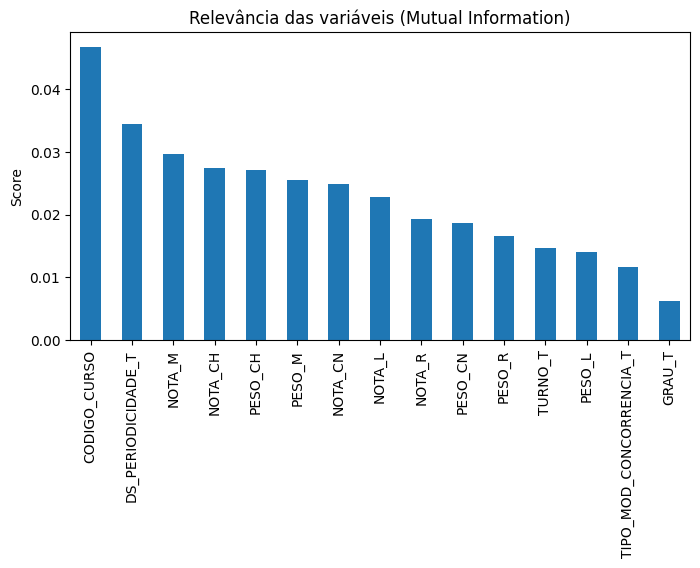

In [ ]:
# Calcular mutual information entre cada feature e a classe
mi = mutual_info_classif(features, target.values.ravel(), random_state=42)

mi_series = pd.Series(mi, index=features.columns).sort_values(ascending=False)

# Visualizar
print(mi_series)

# Gráfico de barras
mi_series.plot(kind="bar", figsize=(8,4), title="Relevância das variáveis (Mutual Information)")
plt.ylabel("Score")
plt.show()

### **Análise**

O gráfico apresenta a **relevância das variáveis** na previsão de aprovação do candidato, medida pela **informação mútua (MI)**. Quanto maior o valor, maior a contribuição da variável na redução da incerteza do modelo.


#### **Variáveis mais relevantes**

* **Código do curso (~0,047):** variável com **maior impacto**, indicando forte relação entre o curso escolhido e a aprovação.
* **Periodicidade (~0,033):** também apresenta alta relevância no modelo.
* **Nota de Matemática (~0,030):** sugere que o desempenho nessa área tem influência significativa na aprovação.

#### **Variáveis de relevância intermediária**

* **Nota de Ciências Humanas (~0,028)** e **Peso de Ciências Humanas (~0,027):** indicam associação moderada com o desempenho do candidato.
* **Peso de Matemática (~0,026):** reforça a importância da disciplina no processo de aprovação.
* **Nota de Ciências da Natureza (~0,025)** e **Nota de Linguagens (~0,023):** contribuem de forma intermediária para o modelo.


#### **Variáveis menos relevantes**

* **Nota de Redação (~0,019)**
* **Pesos de Ciências da Natureza (~0,019), Redação (~0,017) e Linguagens (~0,014):** apresentam baixa contribuição individual.
* **Turno (~0,015)**, **Modalidade de Concorrência (~0,012)** e **Grau (~0,006):** possuem pouca relação direta com a aprovação.

#### **Interpretação geral**

* Variáveis relacionadas ao **curso** e ao **desempenho em Matemática** são os principais fatores para previsão de aprovação.
* Outras notas e pesos contribuem de forma complementar.
* Variáveis institucionais (como turno, modalidade e grau) têm impacto reduzido quando analisadas isoladamente.

#### **Observações**

Após a análise de relevância, foram selecionadas as seguintes variáveis para o treinamento do modelo:
`NOTA_L`, `NOTA_CH`, `NOTA_CN`, `NOTA_M`, `NOTA_R`, `CODIGO_CURSO`, `GRAU_T`, `TIPO_MOD_CONCORRENCIA_T`.





In [ ]:
#Código com as features de maior relevância

features = df_dataset_tratado[[
    'NOTA_L', 'NOTA_CH', 'NOTA_CN', 'NOTA_M', 'NOTA_R',
    'CODIGO_CURSO', 'GRAU_T', 'TIPO_MOD_CONCORRENCIA_T'
]]

target = df_dataset_tratado['APROVADO_T']

## **Separação dos Dados**

- O conjunto de dados foi dividido em 80% para treinamento e 20% para teste do modelo.

- Essa divisão permite avaliar a capacidade de generalização do modelo, verificando se ele é capaz de aprender padrões relevantes ou se está apenas se ajustando aos dados de treino (overfitting).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features, target.values.ravel(), test_size=0.2, random_state=42, stratify=target)

# Contagem simples
print("Distribuição em y_train:")
print(pd.Series(y_train).value_counts())

print("\nDistribuição em y_test:")
print(pd.Series(y_test).value_counts())

# Se quiser formatar mais bonito:
print("\nDistribuição em y_train (percentual):")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nDistribuição em y_test (percentual):")
print(pd.Series(y_test).value_counts(normalize=True))

Distribuição em y_train:
0    132457
1     14375
Name: count, dtype: int64

Distribuição em y_test:
0    33115
1     3594
Name: count, dtype: int64

Distribuição em y_train (percentual):
0    0.902099
1    0.097901
Name: proportion, dtype: float64

Distribuição em y_test (percentual):
0    0.902095
1    0.097905
Name: proportion, dtype: float64


### **Análise**

O dataset foi dividido em **80% para treinamento** e **20% para teste**, utilizando o parâmetro `stratify=target`. Essa abordagem garante que a **proporção entre as classes** seja preservada em ambos os conjuntos, o que é fundamental em problemas **desbalanceados**.


#### **Distribuição das classes**

* **Classe 0 (Reprovado):** **132.457 amostras no treino** e **33.115 no teste**, representando aproximadamente **90,2% dos dados**;
* **Classe 1 (Aprovado):** **14.375 amostras no treino** e **3.594 no teste**, correspondendo a cerca de **9,8% dos dados**.

Observa-se que o dataset é **altamente desbalanceado**, o que pode levar o modelo a favorecer a classe majoritária (classe 0), resultando em alta acurácia, porém baixo desempenho na identificação da classe minoritária.


#### **Recomendações**

* Aplicar técnicas de **balanceamento de dados** no conjunto de treino, como *oversampling* (ex.: SMOTE/SMOTENC), *undersampling* ou ajuste de **pesos das classes**;

* Utilizar **métricas apropriadas para dados desbalanceados**, como *Balanced Accuracy* e *Macro-F1*, em vez de apenas acurácia;

* Complementar a avaliação com métricas de **calibração e confiança**, como *Log Loss* e *Expected Calibration Error (ECE)*, garantindo uma análise mais robusta do desempenho do modelo.




## **Escolha do Modelo**

### **_RandomForestClassifier_**

O **RandomForestClassifier** é um algoritmo de classificação baseado em **conjunto de árvores de decisão (ensemble)**. O modelo constrói múltiplas árvores com diferentes amostras dos dados (*bootstrap*) e subconjuntos de variáveis (*feature bagging*), combinando suas previsões por **votação majoritária**.


#### **Vantagens**

* Reduz **overfitting** em relação a uma única árvore;

* Apresenta **boa performance** em problemas complexos;

* Requer **pouco ajuste de hiperparâmetros**;

* Permite analisar a **importância das variáveis**.


#### **Principais parâmetros**

* `n_estimators`: número de árvores;

* `max_depth`: profundidade máxima de cada árvore;

* `max_features`: número de variáveis por divisão;

* `random_state`: controle de reprodutibilidade;

* `class_weight`: ajuste para dados desbalanceados.





## **Normalização**

A normalização é uma etapa de pré-processamento que ajusta as variáveis para uma **escala comum**, sendo importante para algoritmos sensíveis à magnitude dos dados.


### **Técnicas comuns**

* Min-Max Scaling
* StandardScaler (Z-score)
* RobustScaler


### **Decisão adotada**

A normalização **não foi aplicada** neste projeto, pois o modelo utilizado (**RandomForestClassifier**) é baseado em **árvores de decisão** e **não depende de distância ou escala das variáveis**.

Assim, a diferença de magnitude entre os atributos **não impacta o desempenho do modelo**, tornando essa etapa desnecessária.




## **Parametrização**

A parametrização consiste no **ajuste dos hiperparâmetros** do modelo para melhorar seu desempenho e capacidade de generalização.

### **Aplicação no projeto**

Foi realizada a parametrização do modelo **RandomForestClassifier**, com o objetivo de controlar sua complexidade e otimizar os resultados.

Os principais hiperparâmetros considerados foram:

* `n_estimators`: número de árvores;

* `max_depth`: profundidade máxima das árvores;

* `min_samples_split` e `min_samples_leaf`: critérios de divisão;

* `max_features`: número de variáveis avaliadas em cada divisão;

* `criterion`: métrica utilizada para avaliar a qualidade das divisões;

* `class_weight`: ajusta automaticamente os pesos das classes para lidar com desbalanceamento;

* `random_state`: garante reprodutibilidade dos resultados.

A escolha adequada desses parâmetros contribui para um modelo mais **robusto** e **generalizável**, reduzindo o risco de *overfitting* e melhorando o desempenho em dados desbalanceados.



In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=800,                                     # número de árvores
    max_depth=None,                                       # profundidade máxima
    min_samples_split=5,                                  # mínimo de amostras para split
    min_samples_leaf=2,                                   # mínimo de amostras por folha
    max_features=None,                                    # número de variáveis
    criterion='entropy',                                  # métrica de avaliação (gini ou entropia)
    class_weight='balanced_subsample',                    # trata o desbalanceado das classes
    random_state=42,                                      # fixa a aleatoriedade para reprodutibilidade
)

### **Análise**

O modelo foi configurado com **800 árvores**, sem limite de profundidade, permitindo capturar padrões mais complexos. Ao mesmo tempo, foram definidos critérios mínimos para divisão e tamanho das folhas, reduzindo o risco de *overfitting*. Também foram aplicados ajustes para lidar com o **desbalanceamento das classes**.



| Parâmetro                               | Descrição                              | Impacto no modelo                                                            |
| --------------------------------------- | -------------------------------------- | ---------------------------------------------------------------------------- |
| **n_estimators = 800**                  | Número de árvores na floresta          | Aumenta a robustez e estabilidade do modelo, com maior custo computacional   |
| **max_depth = None**                    | Sem limite de profundidade             | Permite capturar padrões complexos, mas exige controle por outros parâmetros |
| **min_samples_split = 5**               | Mínimo de amostras para divisão        | Torna o modelo menos sensível a divisões irrelevantes                        |
| **min_samples_leaf = 2**                | Mínimo de amostras por folha           | Evita folhas com poucos dados, reduzindo overfitting                         |
| **max_features = None**                 | Usa todas as variáveis em cada divisão | Pode aumentar a capacidade do modelo, porém reduz a aleatoriedade            |
| **criterion = 'entropy'**               | Métrica de divisão                     | Utiliza ganho de informação para construir as árvores                        |
| **class_weight = 'balanced_subsample'** | Ajuste de pesos das classes            | Trata o desbalanceamento durante o treinamento                               |
| **random_state = 42**                   | Semente aleatória                      | Garante reprodutibilidade dos resultados                                     |


# **Treinamento e Teste**

## **Treinamento**

O modelo foi treinado utilizando o método `.fit()`, a partir dos dados de **treino** (`X_train` e `y_train`).

Nessa etapa, o **RandomForestClassifier** constrói suas árvores com base nos dados e nos hiperparâmetros definidos previamente, tornando-se apto a realizar previsões.

In [ ]:
# fit(): ensina o modelo a fazer previsões com os dados de treino.
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', criterion='entropy',
                       max_features=None, min_samples_leaf=2,
                       min_samples_split=5, n_estimators=800, random_state=42)

## **Teste de Previsão**

As probabilidades das classes foram obtidas com o método `.predict_proba()` aplicado ao conjunto de teste (`X_test`).

A partir dessas probabilidades, foi definida uma **classe positiva (1)** com base em um **threshold de 0,35**, gerando as previsões finais (`y_pred`). Essa abordagem permite maior controle sobre a decisão do modelo, especialmente em cenários desbalanceados.

Além disso, também foram analisadas as **probabilidades completas por classe** para cada amostra, auxiliando na interpretação do comportamento do modelo.


In [ ]:
# Probabilidade da classe positiva (classe 1)
y_prob = model.predict_proba(X_test)[:, 1]

# Definindo threshold
threshold = 0.35

# Nova predição baseada no threshold
y_pred = (y_prob > threshold).astype(int)

print(y_pred)

[0 0 0 ... 0 0 1]


In [ ]:
# Retorna as probabilidades por classe para cada amostra.
y_proba = model.predict_proba(X_test)

print(y_proba)

[[0.96138123 0.03861877]
 [1.         0.        ]
 [0.97721341 0.02278659]
 ...
 [0.81825392 0.18174608]
 [0.99766384 0.00233616]
 [0.42274957 0.57725043]]


## **Salvar as Predições**

As predições foram exportadas para uma planilha no Google Drive, definida pelo caminho: `/content/drive/MyDrive/predicoes_teste.xlsx`

O arquivo gerado contém os resultados do modelo para análise e compartilhamento.


In [ ]:
# previsões e probabilidades no teste
classes = model.classes_

# garante um DataFrame de saída com as colunas originais
if isinstance(X_test, pd.DataFrame):
    df_out = X_test.copy()
else:
    df_out = pd.DataFrame(X_test, columns=features.columns)

# adiciona rótulos verdadeiro e predito
df_out["y_true"] = np.asarray(y_test)
df_out["y_pred"] = y_pred
# Adiciona a confiança da classe prevista
#idx = y_proba.argmax(axis=1)
df_out["proba_pred"] = y_prob

# adiciona as probabilidades por classe (uma coluna por classe)
for i, cls in enumerate(classes):
    df_out[f"proba_{cls}"] = y_proba[:, i]

df_out.head()

from google.colab import drive
drive.mount("/content/drive")

caminho_drive = "/content/drive/MyDrive/predicoes_teste.xlsx"
df_out.to_excel(caminho_drive, index=False)
print("Salvo em:", caminho_drive)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Salvo em: /content/drive/MyDrive/predicoes_teste.xlsx


# **Avaliação do Modelo**

O desempenho do modelo foi avaliado considerando métricas e análises adequadas para **dados desbalanceados** e **probabilidades preditas**.

Foram utilizadas as seguintes abordagens:

* **Relatório de Classificação:** precisão, recall e F1-score por classe;

* **Acurácia Balanceada:** desempenho considerando o desbalanceamento;

* **Métricas de calibração (Brier Score, LogLoss, ECE):** qualidade das probabilidades previstas;

* **Tabela comparativa (Base × SMOTE × Calibrado):** comparação entre diferentes abordagens;

* **Matriz de confusão:** análise dos acertos e erros do modelo;

* **Importância das variáveis e visualização:** interpretação do modelo;

* **Permutation Importance:** avaliação da relevância das variáveis.


Essa análise permite uma visão completa do desempenho e da confiabilidade do modelo.


## **Relatório de Classificação**

Foi utilizado o **relatório de classificação** para avaliar o desempenho do modelo nas diferentes classes. Esta é uma das principais ferramentas para avaliar o desempenho de um modelo de aprendizado de máquina em tarefas de **classificação**. Ele apresenta, para cada classe, um conjunto de métricas que ajudam a entender não apenas a quantidade de acertos, mas também a qualidade das previsões.


O relatório apresenta as seguintes métricas:

* **Precision**: proporção de previsões corretas entre as classificações positivas;

* **Recall**: capacidade do modelo em identificar corretamente as instâncias de cada classe;

* **F1-score**: equilíbrio entre precision e recall;

* **Support**: quantidade de amostras por classe.

Também são fornecidas métricas gerais:

* **Accuracy**: desempenho global do modelo;

* **Macro average**: média entre classes, sem considerar desbalanceamento;

* **Weighted average**: média ponderada pela quantidade de amostras.

Essas métricas permitem uma avaliação mais completa do modelo, especialmente em um cenário **desbalanceado**.


In [ ]:
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred, zero_division=0))


Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.96      0.95      0.95     33115
           1       0.55      0.61      0.58      3594

    accuracy                           0.91     36709
   macro avg       0.75      0.78      0.77     36709
weighted avg       0.92      0.91      0.92     36709



### **Análise**

| Classe            | Precision | Recall | F1-score | Support | Interpretação                                                                   |
| ----------------- | --------- | ------ | -------- | ------- | ------------------------------------------------------------------------------- |
| **0 (Reprovado)** | 0.96      | 0.95   | 0.95     | 33.115  | Excelente desempenho, com alta taxa de acerto na classe majoritária             |
| **1 (Aprovado)**  | 0.55      | 0.61   | 0.58     | 3.594   | Desempenho moderado, com dificuldade em identificar corretamente todos os casos |


#### **Métricas Agregadas**

| Métrica          | Valor              | Interpretação                                                   |
| ---------------- | ------------------ | --------------------------------------------------------------- |
| **Accuracy**     | 0.91               | Alta taxa geral de acerto, influenciada pela classe majoritária |
| **Macro avg**    | 0.75 / 0.78 / 0.77 | Indica desempenho mais equilibrado entre as classes             |
| **Weighted avg** | 0.92 / 0.91 / 0.92 | Média ponderada, refletindo o peso maior da classe 0            |



#### **Interpretação**

* O modelo apresenta **ótimo desempenho na classe 0**, que é a mais frequente;

* Para a **classe 1**, o desempenho é inferior, com **recall de 0.61**, indicando que parte dos aprovados não é corretamente identificada;

* A **acurácia elevada (0.91)** é influenciada pelo desbalanceamento, podendo mascarar dificuldades na classe minoritária.


#### **Conclusão**

Apesar da boa acurácia geral, o modelo ainda apresenta limitações na identificação da classe minoritária (**Aprovado**). Portanto, métricas como **F1-score** e **recall** são mais adequadas para avaliar o desempenho nesse cenário.


#### **Próximos passos (sugestões)**

* Aplicar técnicas de **balanceamento de dados** (ex.: SMOTE, undersampling);
* Ajustar ou reforçar o uso de **pesos de classe**;
* Priorizar métricas como **Macro-F1** na avaliação do modelo.



## **Balanceamento de Dados: SMOTE**

Devido ao desbalanceamento das classes, foi aplicada a técnica **SMOTE (Synthetic Minority Over-sampling Technique)** para equilibrar o conjunto de treino.

O SMOTE gera **novas amostras sintéticas** da classe minoritária a partir da interpolação entre vizinhos próximos, evitando a simples duplicação de dados.


### **Aplicação no projeto**

* Utilizado **apenas no conjunto de treino**;

* Aplicado para reduzir o viés do modelo em relação à classe majoritária.


### **Observação**

O uso do SMOTE pode impactar a separação das classes, devendo ser avaliado em conjunto com as métricas de desempenho.

In [ ]:
sm = SMOTE(random_state=42)
X_tr_sm, y_tr_sm = sm.fit_resample(X_train, y_train)
model_sm = RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)
model_sm.fit(X_tr_sm, y_tr_sm)
y_pred_sm = model_sm.predict(X_test)
print(classification_report(y_test, y_pred_sm, digits=3))

              precision    recall  f1-score   support

           0      0.971     0.758     0.852     33115
           1      0.263     0.794     0.395      3594

    accuracy                          0.762     36709
   macro avg      0.617     0.776     0.623     36709
weighted avg      0.902     0.762     0.807     36709



### **Análise**

A seguir, é apresentada a comparação entre o modelo **sem balanceamento** e **com balanceamento** das classes.


#### **Modelo sem balanceamento**

* **Classe 0 (Reprovado):** alto desempenho (`precision=0.96`, `recall=0.95`, `f1=0.95`), devido ao grande número de exemplos;
* **Classe 1 (Aprovado):** desempenho moderado (`precision=0.55`, `recall=0.61`, `f1=0.58`), com dificuldade em identificar todos os casos.

**Métricas gerais:**

* `accuracy = 0.91`: influenciada pela classe majoritária;
* `macro avg f1 = 0.77`: indica desempenho mais equilibrado, porém ainda limitado na classe minoritária.

> **Conclusão:** o modelo apresenta bom desempenho geral, mas ainda favorece a classe majoritária.



#### **Modelo com balanceamento**

* **Classe 0 (Reprovado):** redução no desempenho (`recall=0.758`, `f1=0.852`);
* **Classe 1 (Aprovado):** melhora significativa no **recall** (`0.61 → 0.794`), indicando maior capacidade de identificar aprovados, porém com baixa precisão (`0.263`).

**Métricas gerais:**

* `accuracy = 0.762`: queda em relação ao modelo base;
* `macro avg f1 = 0.623`: indica maior equilíbrio entre as classes;

> **Conclusão:** o balanceamento aumentou a capacidade do modelo de identificar a classe minoritária, mas reduziu a precisão geral e o desempenho na classe majoritária.



#### **Comparativo Final**

* **Sem balanceamento:** maior acurácia e precisão geral, porém menor capacidade de identificar a classe minoritária;
* **Com balanceamento:** melhor detecção da classe minoritária (maior recall), com perda de desempenho global;

A escolha do modelo depende do objetivo:

* Priorizar **detecção da classe minoritária (Aprovado)** → modelo com balanceamento;
* Priorizar **acurácia geral** → modelo sem balanceamento.

Embora o balanceamento tenha melhorado o recall da classe minoritária (Aprovado), essa abordagem resultou em uma queda significativa na acurácia geral e na precisão das previsões.

No contexto do SISU, onde o objetivo é realizar previsões mais confiáveis e consistentes, essa perda de desempenho global não é vantajosa. O aumento de recall na classe minoritária vem acompanhado de um alto número de falsos positivos, o que reduz a confiabilidade do modelo.

Dessa forma, o modelo sem balanceamento se mostra mais adequado, pois mantém melhor desempenho geral e maior estabilidade nas previsões, mesmo apresentando limitações na identificação da classe minoritária.

## **Validação Cruzada: K-Fold**

A avaliação do modelo pode variar conforme a divisão dos dados entre treino e teste. Para reduzir essa dependência, foi aplicada a técnica de **Validação Cruzada K-Fold**.

Nesse processo, os dados são divididos em **5 partes (folds)**. Em cada iteração, **4 partes são usadas para treino** e **1 parte para validação**, até que todas as partes tenham sido utilizadas como validação.

#### Principais vantagens do K-Fold

- reduz a influência de uma única divisão dos dados;
- permite uma avaliação mais estável do modelo;
- ajuda a verificar a consistência do desempenho entre diferentes subconjuntos;
- produz uma métrica média mais confiável para análise do modelo.

**Resultado:** o modelo foi avaliado em múltiplas divisões dos dados, permitindo uma análise mais robusta da sua capacidade de generalização.

In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    features,
    target,
    cv=5,
    scoring='f1_weighted'
)

print("F1-weighted por fold:", scores)
print("F1-weighted médio:", scores.mean())

F1-weighted por fold: [0.7622706  0.76714508 0.64785799 0.76192451 0.86634318]
F1-weighted médio: 0.7611082736551209


### **Análise**

* **F1-weighted por fold:** `[0.7622, 0.7671, 0.6479, 0.7619, 0.8664]`

  * Há variação perceptível entre os folds;
  * Um dos subconjuntos apresentou desempenho inferior (≈0.6479), indicando sensibilidade à divisão dos dados;
  * Em contrapartida, o melhor resultado (≈0.8664) mostra que o modelo consegue bom ajuste em determinados cenários.

* **F1-weighted médio: 0.7611**

  * Representa um desempenho geral consistente do modelo;
  * A média ponderada indica equilíbrio razoável entre as classes;
  * Mesmo com a variação entre os folds, o modelo mantém estabilidade aceitável.

#### **Conclusão**

* O modelo apresentou desempenho médio de **0.7611 (F1-weighted)** na validação cruzada;
* Existe variação entre os folds, indicando que o desempenho depende da amostra utilizada;
* Apesar disso, os resultados se mantêm em um nível consistente na maioria das execuções;
* A utilização do **K-Fold** permitiu uma avaliação mais robusta e confiável da capacidade de generalização do modelo.

## **Resultado do Balanceamento**

Para avaliar o modelo após o balanceamento, foram utilizadas acurácia e Balanced Accuracy.

- A acurácia indica o desempenho geral do modelo;

- A Balanced Accuracy foi adotada para considerar o desbalanceamento, avaliando o desempenho de forma equilibrada entre as classes.

Essa abordagem permite uma análise mais representativa do modelo, especialmente na identificação da classe minoritária.

In [ ]:
print("Balanced Acc (Base) :", balanced_accuracy_score(y_test, y_pred))
print("Balanced Acc (SMOTE):", balanced_accuracy_score(y_test, y_pred_sm))

Balanced Acc (Base) : 0.7791960883015807
Balanced Acc (SMOTE): 0.7762745566095656


### **Análise**

* **Modelo Base (sem balanceamento): 0.779**

  * Apresenta bom desempenho médio entre as classes;
  * Indica que o modelo já consegue lidar razoavelmente com o desbalanceamento, mesmo favorecendo a classe majoritária.

* **Modelo com balanceamento (SMOTE): 0.776**

  * Desempenho muito próximo ao modelo base;
  * Pequena redução na métrica, indicando que o balanceamento não trouxe ganho relevante na capacidade geral de classificação entre as classes.



#### **Conclusão**

* A **Balanced Accuracy** confirma que o modelo base já possui um desempenho equilibrado entre as classes;
* O uso de **SMOTE não gerou melhora significativa**, mantendo resultados praticamente equivalentes;
* Considerando também a queda na acurácia geral observada anteriormente, o balanceamento **não se mostra vantajoso para este cenário**.


## **Diagnóstico do Modelo Base**

- Foi avaliada a calibração do modelo base para cada classe.
- Para isso, foram geradas curvas de calibração no esquema one-vs-rest.
- Também foi calculado o Brier score por classe.
- O objetivo foi verificar o comportamento do modelo antes de qualquer ajuste.

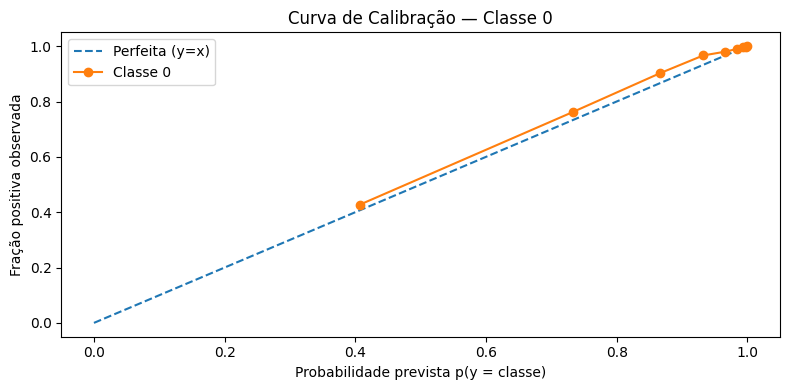

Brier score (classe 0): 0.0553


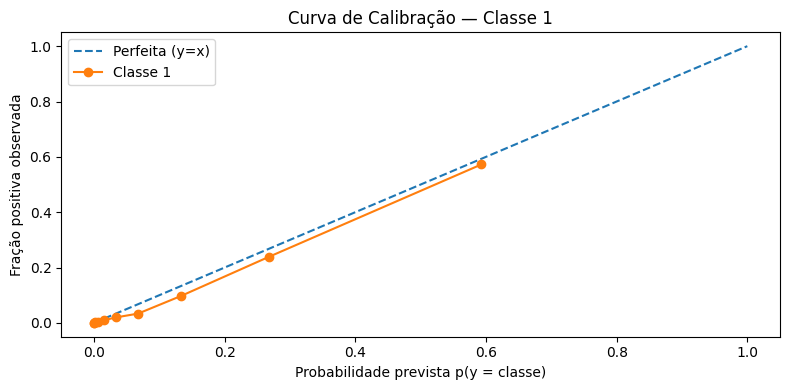

Brier score (classe 1): 0.0553


In [ ]:
# Probabilidades preditas no teste (multiclasse)
y_proba = model.predict_proba(X_test)
classes = model.classes_

# Padronização do n_bins = 10
N_BINS = 10

# Uma curva por classe (one-vs-rest)
for k, cls in enumerate(classes):
    y_true_bin = (y_test == cls).astype(int)
    frac_pos, mean_pred = calibration_curve(y_true_bin, y_proba[:, k], n_bins=N_BINS, strategy="quantile")

    plt.figure(figsize=(8,4))
    plt.plot([0,1], [0,1], "--", label="Perfeita (y=x)")
    plt.plot(mean_pred, frac_pos, marker="o", label=f"Classe {cls}")
    plt.xlabel("Probabilidade prevista p(y = classe)")
    plt.ylabel("Fração positiva observada")
    plt.title(f"Curva de Calibração — Classe {cls}")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

    # Métrica quantitativa de calibração (Brier score) para a classe k
    bs = brier_score_loss(y_true_bin, y_proba[:, k])
    print(f"Brier score (classe {cls}): {bs:.4f}")

### **Análise**

#### **Classe 0**

- A curva de calibração indica comportamento próximo ao ideal, com boa correspondência entre probabilidade prevista e frequência observada.
- Brier score: **0.0553**.

#### **Classe 1**

- O padrão observado é semelhante ao da classe 0, com calibração próxima do esperado.
- Brier score: **0.0553**.

#### **Interpretação Geral**

- O modelo base apresentou **comportamento equilibrado entre as classes**.
- Os valores iguais de Brier score sugerem desempenho de calibração semelhante para ambas as classes.
- Como diagnóstico inicial, o resultado mostra um modelo com **calibração razoável**, servindo como referência para comparações com versões ajustadas.


## **Calibração do Modelo**

A calibração foi aplicada ao modelo-base utilizando dois métodos: **sigmoid** e **isotonic**, ambos com validação cruzada (cv=5).  

Foram comparadas três versões do modelo:

- **Base**
- **Calibrado (sigmoid)**
- **Calibrado (isotonic)**

A avaliação foi feita com base nas probabilidades previstas no conjunto de teste, utilizando:

- **Curva de calibração (calibration curve)**
- **Brier Score por classe**

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import numpy as np
import matplotlib.pyplot as plt

# 1) Treinar versões calibradas do modelo-base
cal_sig = CalibratedClassifierCV(model, method="sigmoid", cv=5)
cal_sig.fit(X_train, y_train)

cal_iso = CalibratedClassifierCV(model, method="isotonic", cv=5)
cal_iso.fit(X_train, y_train)

# 2) Probabilidades no conjunto de teste
models = {
    "Base": model,
    "Calibrado (sigmoid)": cal_sig,
    "Calibrado (isotonic)": cal_iso,
}

probas = {name: m.predict_proba(X_test) for name, m in models.items()}
classes = model.classes_

print("\n================= RESUMO GERAL =================")
for name, P in probas.items():
    print(f"\nModelo: {name}")
    print(f" - Shape probas: {P.shape}")
    print(f" - Prob média: {np.mean(P):.4f}")
    print(f" - Prob min/max: {P.min():.4f} / {P.max():.4f}")

# 3) Curvas de calibração por classe
for k, cls in enumerate(classes):
    print(f"\n================= CLASSE {cls} =================")

    y_true_bin = (y_test == cls).astype(int)
    print(f"Qtd positivos reais: {y_true_bin.sum()} de {len(y_true_bin)}")

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], "--", label="Perfeita (y=x)")

    for name, P in probas.items():
        probs_classe = P[:, k]

        # Brier Score
        brier = brier_score_loss(y_true_bin, probs_classe)
        print(f"\nModelo: {name}")
        print(f" - Brier Score: {brier:.6f}")

        # Estatísticas das probabilidades
        print(f" - Média prob: {np.mean(probs_classe):.4f}")
        print(f" - Min/Max prob: {probs_classe.min():.4f} / {probs_classe.max():.4f}")

        # Curva de calibração
        frac_pos, mean_pred = calibration_curve(
            y_true_bin, probs_classe, n_bins=N_BINS, strategy="quantile"
        )

        print(" - Bins (mean_pred vs frac_pos):")
        for mp, fp in zip(mean_pred, frac_pos):
            print(f"   ({mp:.3f} -> {fp:.3f})")

        plt.plot(mean_pred, frac_pos, marker="o", label=f"{name} (Brier={brier:.3f})")

    plt.xlabel(f"Probabilidade prevista p(y = {cls})")
    plt.ylabel("Fração positiva observada")
    plt.title(f"Curva de Calibração — Classe {cls}")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

### **Análise**

Os três modelos geraram probabilidades com o mesmo formato (`36709 x 2`) e média global de `0.5000`.

- **Base**: intervalo completo de probabilidades (`0.0000` a `1.0000`)
- **Sigmoid**: probabilidades mais suavizadas (`0.0204` a `0.9796`)
- **Isotonic**: manteve o intervalo completo (`0.0000` a `1.0000`)

Isso indica que o método sigmoid restringe extremos, enquanto o isotonic mantém maior flexibilidade.

#### **Classe 0**

A classe 0 é majoritária (**33115 amostras**).

- O **modelo base** já apresentou boa calibração, com bins próximos da diagonal.
- O **sigmoid** manteve o comportamento, porém sem ganho de desempenho.
- O **isotonic** apresentou o melhor ajuste geral, com melhor alinhamento nos bins.

**Brier Score:**
- Base: `0.055274`
- Sigmoid: `0.056494`
- Isotonic: `0.055049`

O isotonic apresentou a menor perda, indicando leve melhora na calibração.

#### **Classe 1**

A classe 1 possui **3594 amostras** (minoritária).

- O **modelo base** apresentou maior dispersão, principalmente em probabilidades baixas.
- O **sigmoid** suavizou as previsões, mas não melhorou o erro.
- O **isotonic** apresentou melhor alinhamento entre probabilidade prevista e frequência real.

**Brier Score:**
- Base: `0.055274`
- Sigmoid: `0.056494`
- Isotonic: `0.055049`

Novamente, o isotonic teve o melhor resultado.

#### **Comparativo entre métodos**

- **Base**: já possui calibração razoável.
- **Sigmoid**: suaviza as probabilidades, mas não trouxe ganho.
- **Isotonic**: melhor desempenho geral, com menor Brier Score nas duas classes.

A calibração isotônica foi a que melhor ajustou as probabilidades previstas ao comportamento real, sendo a abordagem mais adequada entre as testadas.




## **Comparação: Base x SMOTE x Calibrado**

In [ ]:
# =========================
# 1) Brier por classe (↓ melhor) usando o mesmo 'probas'
# =========================
print("\n" + "="*80)
print("1) BRIER POR CLASSE (menor = melhor)")
print("="*80)

rows = []
for name, P in probas.items():
    print(f"\nModelo: {name}")
    for k, cls in enumerate(classes):
        y_true_bin = (np.asarray(y_test) == cls).astype(int)
        brier = brier_score_loss(y_true_bin, P[:, k])
        rows.append([name, cls, brier])
        print(f"  Classe {cls}: Brier = {brier:.6f}")

df_brier = (
    pd.DataFrame(rows, columns=["Modelo", "Classe", "Brier (OVR)"])
      .pivot(index="Classe", columns="Modelo", values="Brier (OVR)")
      .sort_index()
)

print("\nTabela Brier consolidada:")
display(df_brier.round(4))

# =========================
# 2) ECE helper (só cria se não existir ainda)
# =========================
if "ece" not in globals():
    def ece(probs, y_true, n_bins=10):
        bins = np.linspace(0, 1, n_bins + 1)
        conf = probs.max(axis=1)
        preds = probs.argmax(axis=1)
        acc = (preds == np.asarray(y_true)).astype(float)
        val = 0.0
        for i in range(n_bins):
            m = (conf >= bins[i]) & (conf < bins[i + 1])
            if m.any():
                val += abs(acc[m].mean() - conf[m].mean()) * m.mean()
        return val

print("\n" + "="*80)
print("2) MÉTRICA ECE DISPONÍVEL")
print("="*80)
print("Função 'ece' criada/confirmada com sucesso.")

# =========================
# 3) Refazer os cálculo, por garantia
# =========================
print("\n" + "="*80)
print("3) PREDIÇÕES NO CONJUNTO DE TESTE")
print("="*80)

y_pred_base = model.predict(X_test)
y_pred_sm = model_sm.predict(X_test)
y_pred_cal_sig = cal_sig.predict(X_test)
y_pred_cal_iso = cal_iso.predict(X_test)

print("Predições geradas para:")
print(" - Base")
print(" - SMOTE")
print(" - Calibrado (sigmoid)")
print(" - Calibrado (isotonic)")

# =========================
# 4) Tabela final (use as probabilidades/predições do mesmo dicionário 'probas')
# =========================
print("\n" + "="*80)
print("4) TABELA FINAL DE COMPARAÇÃO")
print("="*80)

linhas = [{
    "Modelo": "Base",
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Balanced Acc.": balanced_accuracy_score(y_test, y_pred_base),
    "Macro-F1": f1_score(y_test, y_pred_base, average="macro", zero_division=0),
    "LogLoss": log_loss(y_test, probas["Base"], labels=classes),
    "ECE": ece(probas["Base"], y_test, 10),
}]

probas["SMOTE"] = model_sm.predict_proba(X_test)
linhas.append({
    "Modelo": "SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred_sm),
    "Balanced Acc.": balanced_accuracy_score(y_test, y_pred_sm),
    "Macro-F1": f1_score(y_test, y_pred_sm, average="macro", zero_division=0),
    "LogLoss": log_loss(y_test, probas["SMOTE"], labels=classes),
    "ECE": ece(probas["SMOTE"], y_test, 10),
})

linhas.append({
    "Modelo": "Calibrado (sigmoid)",
    "Accuracy": accuracy_score(y_test, y_pred_cal_sig),
    "Balanced Acc.": balanced_accuracy_score(y_test, y_pred_cal_sig),
    "Macro-F1": f1_score(y_test, y_pred_cal_sig, average="macro", zero_division=0),
    "LogLoss": log_loss(y_test, probas["Calibrado (sigmoid)"], labels=classes),
    "ECE": ece(probas["Calibrado (sigmoid)"], y_test, 10),
})

linhas.append({
    "Modelo": "Calibrado (isotonic)",
    "Accuracy": accuracy_score(y_test, y_pred_cal_iso),
    "Balanced Acc.": balanced_accuracy_score(y_test, y_pred_cal_iso),
    "Macro-F1": f1_score(y_test, y_pred_cal_iso, average="macro", zero_division=0),
    "LogLoss": log_loss(y_test, probas["Calibrado (isotonic)"], labels=classes),
    "ECE": ece(probas["Calibrado (isotonic)"], y_test, 10),
})

df_resultados = pd.DataFrame(linhas).round(4)

print("\nTabela final:")
display(df_resultados)

print("\nResumo rápido:")
for _, row in df_resultados.iterrows():
    print(
        f" - {row['Modelo']}: "
        f"Acc={row['Accuracy']:.4f}, "
        f"Balanced Acc={row['Balanced Acc.']:.4f}, "
        f"Macro-F1={row['Macro-F1']:.4f}, "
        f"LogLoss={row['LogLoss']:.4f}, "
        f"ECE={row['ECE']:.4f}"
    )

print("\nMelhor modelo por métrica:")
for col in ["Accuracy", "Balanced Acc.", "Macro-F1"]:
    best_idx = df_resultados[col].idxmax()
    print(f" - {col}: {df_resultados.loc[best_idx, 'Modelo']} ({df_resultados.loc[best_idx, col]:.4f})")

for col in ["LogLoss", "ECE"]:
    best_idx = df_resultados[col].idxmin()
    print(f" - {col}: {df_resultados.loc[best_idx, 'Modelo']} ({df_resultados.loc[best_idx, col]:.4f})")


1) BRIER POR CLASSE (menor = melhor)


NameError: name 'probas' is not defined

### **Análise**

Vamos analisar os resultados apresentados nas duas tabelas:

#### **Métrica Brier Score por Classe (quanto menor, melhor)**

- **Classes 0 e 1**: os valores são muito próximos entre os modelos (~0.055), indicando que todos apresentam boa calibração geral.
  
  - O **calibrado (isotonic)** teve o melhor resultado (**0.0550**), com leve melhora em relação ao **modelo Base** (**0.0553**).
  - O **calibrado (sigmoid)** apresentou o pior desempenho (**0.0565**), ficando acima do modelo base.
  
- A diferença entre os modelos é pequena, mas consistente o suficiente para indicar que a **calibração isotônica ajustou melhor as probabilidades**.

#### **Métricas Globais**

* **Base**
  - Accuracy: **0.9228** (alta)
  - Balanced Accuracy: **0.6992**
  - Macro-F1: **0.7373** (melhor resultado)
  - LogLoss: **0.1866**
  - ECE: **0.0126**
  
  → Modelo mais equilibrado no geral, com melhor desempenho em classificação (Macro-F1).


* **SMOTE**
  - Accuracy: **0.7619** (queda significativa)
  - Balanced Accuracy: **0.7763** (melhor resultado)
  - Macro-F1: **0.6235**
  - LogLoss: **0.4447** (pior resultado)
  - ECE: **0.0438** (pior calibração)
  
  → Melhora o equilíbrio entre classes, mas com forte degradação nas probabilidades e desempenho geral.

- **Calibrado (sigmoid)**
  
  - Accuracy: **0.9227**
  - Balanced Accuracy: **0.6885**
  - Macro-F1: **0.7299**
  - LogLoss: **0.1939**
  - ECE: **0.0165**
  
  → Mantém desempenho próximo ao modelo base, mas sem ganhos relevantes e com leve piora na calibração.


* **Calibrado (isotonic)**

  - Accuracy: **0.9235** (melhor)
  - Balanced Accuracy: **0.6836**
  - Macro-F1: **0.7276**
  - LogLoss: **0.1826** (melhor)
  - ECE: **0.0016** (melhor calibração)
  
  → Melhor modelo em termos de **qualidade probabilística**, com forte redução no ECE e melhora no LogLoss.

#### **Conclusões**

- **Base**: melhor desempenho geral de classificação (maior Macro-F1), mantendo bom equilíbrio.
- **SMOTE**: melhora a capacidade de tratar classes desbalanceadas (Balanced Accuracy), mas piora significativamente as probabilidades e o desempenho global.
- **Calibração (sigmoid)**: pouco impacto prático, sem ganhos relevantes.
- **Calibração (isotonic)**: melhora clara na **calibração das probabilidades** (menor LogLoss e ECE), com leve ganho em Accuracy.

#### **Síntese:**

- Se o objetivo é **classificação geral**, o **modelo Base** é o mais indicado.
- Se o foco é **equilíbrio entre classes**, o **SMOTE** se destaca.
- Se o objetivo é **confiabilidade das probabilidades**, o **calibrado isotonic** é a melhor escolha.



## **Matriz de Confusão**
A matriz de confusão mostra o desempenho do modelo na classificação entre as duas classes avaliadas.  
Pelos resultados obtidos, o modelo teve bom desempenho na identificação da classe negativa, com **31.319 acertos**, mas ainda apresentou erros relevantes ao prever a classe positiva.

A saída observada foi:

`[[31319 1796] [1392 2202]]`

Isso indica:

- **31.319 verdadeiros negativos**;
- **2.202 verdadeiros positivos**;
- **1.796 falsos positivos**;
- **1.392 falsos negativos**.

De forma geral, o modelo apresenta **boa capacidade de acerto na classe majoritária**, mas ainda confunde parte dos casos positivos, o que reduz o desempenho dessa classe específica.

#### **Observação importante**

- A análise abaixo foi feita com base nas previsões do modelo base, usando `y_pred`.
- A matriz exibida é **binária (2x2)**, portanto a interpretação considera apenas duas classes.

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

### **Análise**


| Classe Real | Acertos | Erros | Observações |
|------------|--------|------|------------|
| **Classe 0** | 31.319 | 1.796 como classe 1 | Modelo performa muito bem na classe majoritária |
| **Classe 1** | 2.202 | 1.392 como classe 0 | Modelo ainda erra uma quantidade relevante de positivos |

#### **O que isso indica?**

- **Classe 0 domina o dataset** e o modelo consegue identificá-la com alta precisão;
- **Classe 1 ainda apresenta dificuldade**, com quantidade considerável de falsos negativos;
- O modelo tende a **confundir casos positivos como negativos**, o que pode impactar análises de falhas.

#### **Próximo passo sugerido**

- Avaliar métricas como **recall da classe 1** (importante para reduzir falsos negativos);
- Comparar com modelos calibrados para verificar melhoria;
- Investigar possível desbalanceamento entre as classes.

## **Matriz de Confusão Normalizada por Classe**

A matriz de confusão normalizada por classe foi utilizada para avaliar o desempenho do modelo em termos proporcionais, considerando o total de exemplos de cada classe real.

Diferente da matriz tradicional (valores absolutos), essa abordagem permite analisar a taxa de acertos e erros por classe, sendo especialmente útil em cenários com desbalanceamento.

In [ ]:
cm = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f'); plt.show()

### **Análise**

A **matriz de confusão normalizada por classe** evidencia como o modelo se comporta proporcionalmente em cada classe, destacando o impacto do desbalanceamento.

**Matriz obtida:**
[[0.9458 0.0542]
[0.3873 0.6127]]

#### **Classe 0 (Sem Falha)**

- Apresenta **94,6% de acerto**, indicando excelente desempenho na classe majoritária.
- Apenas **5,4% dos casos foram classificados como falha (classe 1)**.
- O modelo está bem ajustado para reconhecer padrões de funcionamento normal.

#### **Classe 1 (Falha)**

- A taxa de acerto é de **61,3%**, consideravelmente menor que a classe 0.
- **38,7% dos casos de falha foram classificados como classe 0**, ou seja, falsos negativos.
- Isso indica dificuldade do modelo em identificar corretamente todos os eventos de falha.

#### **Conclusões**

- O modelo apresenta **alto desempenho na classe majoritária (classe 0)**, mantendo baixa taxa de erro.
- Há uma **queda significativa de desempenho na classe de falha (classe 1)**, com presença relevante de falsos negativos.
- Esse comportamento reforça o impacto do **desbalanceamento do dataset**, mesmo após ajustes no modelo.
- Para cenários críticos (detecção de falhas), é importante reduzir falsos negativos, podendo ser exploradas técnicas como:
  - ajuste de limiar de decisão,
  - reamostragem (ex: SMOTE),
  - ou modelos com maior sensibilidade à classe minoritária.


## **Visualização da Árvore de Decisão**

A célula seleciona a primeira árvore da floresta (`estimators_[0]`) e exibe sua estrutura com profundidade limitada a 3 níveis. A visualização usa as 8 variáveis disponíveis e mostra como o modelo realiza as divisões internas para classificar os registros nas classes **0** e **1**.







In [ ]:
# Seleciona a primeira árvore da floresta
arvore = model.estimators_[0]

# Plotar a árvore
plt.figure(figsize=(30, 10))
plot_tree(arvore,
          feature_names=features.columns,
          class_names=[str(c) for c in np.unique(target.values.ravel())],
          filled=True,
          rounded=True,
          max_depth=3,  # limitar a profundidade para facilitar a leitura
          fontsize=8)

plt.title("Visualização de uma Árvore da Random Forest")
plt.show()

### **Análise**

Mostra graficamente uma das árvores da floresta (Random Forest), evidenciando como o modelo utiliza as variáveis para realizar as primeiras divisões entre as classes.

* Ajuda a entender como as decisões são tomadas com base nas variáveis.

* max_depth=3: mostra apenas os 3 primeiros níveis, facilitando a leitura e destacando os critérios iniciais do modelo.

#### **Importante**

> Esta árvore possui profundidade limitada, portanto a análise é apenas ilustrativa. O modelo final considera o conjunto de árvores da floresta.


#### **Informações nos nós**

* **gini**: mede a impureza do nó (quanto menor, mais homogêneo).
* **samples**: quantidade de amostras no nó.
* **value**: distribuição das classes.
* **class**: classe predominante (predição do nó).

#### **Interpretação dos Ramos**

* Os ramos mostram como o modelo separa os dados com base nas condições das variáveis.

* Os nós mais puros (gini baixo) indicam maior confiança na classificação.

#### **Padrões Importantes**

1. As variáveis mais relevantes aparecem nos primeiros splits da árvore, indicando maior influência na decisão.

2. A separação entre as classes **0** e **1** ocorre de forma progressiva, com aumento da pureza nos níveis mais profundos.

3. Nós com **gini próximo de 0** indicam regiões onde o modelo classifica com alta confiança.

#### **Limitação**

* A árvore exibida é apenas uma entre várias da Random Forest.

* O modelo final utiliza o **conjunto de árvores**, combinando suas decisões para obter melhor desempenho.

#### **Resumo da análise**

> A visualização mostra como o modelo organiza as decisões de forma hierárquica, utilizando combinações de variáveis para separar as classes. A interpretação direta da árvore é útil para entendimento, mas a predição final depende do conjunto completo da floresta.

## **Feature Importances**

A importância de uma feature em um modelo como o **Random Forest** indica o quanto cada variável contribuiu para as divisões feitas pelas árvores e, consequentemente, para a capacidade de predição do modelo.

Neste relatório, foi calculada a **Feature Importance** com base na redução de impureza ao longo da floresta. O resultado mostra quais variáveis tiveram maior peso na construção do modelo e quais exerceram menor influência nas decisões.

Foram analisadas as variáveis do conjunto de dados e a soma das importâncias ficou igual a **1.0**, confirmando a consistência do cálculo.


In [ ]:
importancias = model.feature_importances_
feature_names = features.columns
importancia_df = pd.DataFrame({'Feature': feature_names, 'Importância': importancias})
importancia_df = importancia_df.sort_values(by='Importância', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=importancia_df, x='Importância', y='Feature')
plt.title('Importância das Features - Random Forest')
plt.show()

### **Análise**

O gráfico mostra que **CODIGO_CURSO** foi a variável mais importante para o modelo, com peso de **0.293880**, indicando que ela teve maior influência nas decisões feitas pelo Random Forest.

Em seguida, aparecem **NOTA_M** (**0.215422**), **NOTA_CH** (**0.116689**) e **NOTA_CN** (**0.108957**), que também tiveram participação relevante na predição. As variáveis **NOTA_L** (**0.093061**) e **NOTA_R** (**0.089826**) apresentaram importância intermediária.

As menores importâncias ficaram com **GRAU_T** (**0.046326**) e **TIPO_MOD_CONCORRENCIA_T** (**0.035838**), mostrando que essas variáveis tiveram menor impacto nas divisões do modelo.

#### **Resumo dos resultados**

| Variável | Importância | Interpretação |
|---|---:|---|
| **CODIGO_CURSO** | **0.293880** | Variável mais decisiva no modelo. |
| **NOTA_M** | **0.215422** | Segunda variável mais relevante. |
| **NOTA_CH** | **0.116689** | Teve influência alta na predição. |
| **NOTA_CN** | **0.108957** | Também contribuiu de forma importante. |
| **NOTA_L** | **0.093061** | Participação moderada. |
| **NOTA_R** | **0.089826** | Participação moderada. |
| **GRAU_T** | **0.046326** | Menor influência no modelo. |
| **TIPO_MOD_CONCORRENCIA_T** | **0.035838** | Menor impacto entre as variáveis. |

A soma total das importâncias foi **1.0**, indicando que os valores estão normalizados corretamente.

#### **Conclusão**

O modelo deu maior peso para **CODIGO_CURSO** e para as notas **NOTA_M**, **NOTA_CH** e **NOTA_CN**. Isso mostra que essas variáveis foram as mais usadas pelo Random Forest para diferenciar os padrões aprendidos no conjunto de dados.

## **Permutation Importance Geral**
A Permutation Importance mede impacto na métrica escolhida. Ela embaralha os valores de uma feature e mede quanto o modelo perde em performance. Características:

> - Mede a queda real de performance (ex.: accuracy, F1) quando os valores de uma variável são embaralhados.

> - Se ao embaralhar uma variável a performance cai muito, ela era realmente crítica para a predição.

> - Tem a vantagem de capturar efeitos indiretos e interações.

> - Pode variar mais (precisa de n_repeats razoável), mas é mais próximo de uma medida global de utilidade para o modelo.

Neste caso, mostrou que Air temperature aparece como a variável mais importante, junto de torque e rotational speed. Isso sugere que, na prática, o modelo usa bastante temperatura do ar para distinguir algumas classes (possivelmente falhas térmicas), embora isso não apareça tão forte nas divisões da árvore.


In [ ]:
# No conjunto de teste (para não superestimar)
result = permutation_importance(model, X_test, y_test, scoring="f1_macro",
                                n_repeats=20, random_state=42, n_jobs=-1)

importances = pd.Series(result.importances_mean, index=features.columns)
importances = importances.sort_values(ascending=False)

print(importances)

# Gráfico
importances.plot(kind="bar", figsize=(8,3), title="Permutation Importance")

### **Análise**

* O método embaralhou os valores de cada feature no **conjunto de teste** e mediu a queda no desempenho do modelo (aqui, no **F1-macro**).
* Quanto maior a queda no desempenho, mais importante é a variável.

#### **Resultados numéricos**

* **Rotational speed [rpm] → 0.1849**
* **Torque [Nm] → 0.1654**
* **Air temperature [K] → 0.0893**
* **Tool wear [min] → 0.0730**
* **Process temperature [K] → 0.0364**

#### **Interpretação**

- **Rotational speed [rpm]** e **Torque [Nm]** são os fatores mais determinantes para prever falhas.

   * Isso faz sentido, pois alterações mecânicas nesses parâmetros estão diretamente ligadas a falhas de operação.

- **Air temperature [K]** tem relevância intermediária, mostrando que condições ambientais afetam, mas não dominam, as previsões.

- **Tool wear [min]** aparece com impacto relativamente baixo, o que pode indicar que o modelo está captando falhas mais por velocidade/torque do que por desgaste (embora na árvore de decisão esse fator apareça bastante).

- **Process temperature [K]** foi a menos relevante. Possivelmente ela não apresenta variação significativa entre classes ou é redundante em relação a outras features.

#### **Conclusão**

* O modelo está **mais sensível a parâmetros operacionais (velocidade e torque)** do que a fatores térmicos e de desgaste.

* Isso é coerente com sistemas mecânicos, mas também pode indicar que algumas variáveis de falha **não estão bem representadas no dataset**.

* A importância relativamente baixa de *tool wear* pode ser consequência do **desbalanceamento de classes**, onde falhas ligadas a desgaste são menos frequentes.


## **Permutation Importance por Classe**

Mede a importância das variáveis focando na capacidade do modelo de prever a Classe 1 (3594 exemplos). Foi utilizado um scorer customizado para comparar o alvo binário (Classe 1 vs. Resto) com a predição via argmax, avaliando a queda do F1-Score ao permutar as características.

In [ ]:
classes = model.classes_
classes_interesse = [1]   # ajuste as classes de interesse

def scorer_para_classe_k_factory(k):
    # k é o rótulo inteiro da classe (ex.: 1, 3, 5)
    def _scorer(estimator, X, y_true_bin):
        # Prediz classe argmax e transforma em binário (1 se ==k, 0 caso contrário)
        y_pred_bin = (estimator.predict(X) == k).astype(int)
        return f1_score(y_true_bin, y_pred_bin, zero_division=0)
    return _scorer

for k in classes_interesse:
    print(f"\n=== Permutation Importance focada na classe {k} (F1-binário) ===")
    y_true_bin = (y_test == k).astype(int)

    result_k = permutation_importance(
        model, X_test, y_true_bin,
        scoring=scorer_para_classe_k_factory(k),
        n_repeats=20, random_state=42, n_jobs=-1
    )

    pi_k = pd.Series(result_k.importances_mean, index=features.columns).sort_values(ascending=False)
    display(pi_k)

    plt.figure(figsize=(10,4))
    pi_k.plot(kind="bar")
    plt.title(f"Permutation Importance — Classe {k} (F1 binário classe {k})")
    plt.ylabel("Queda média na métrica ao permutar")
    plt.tight_layout()
    plt.show()

### **Análise**
A análise comparativa entre as métricas revela o papel de cada variável no modelo:

feature_importances_: Indica quais variáveis o modelo utilizou mais vezes para realizar as divisões nos dados durante o treinamento.

Permutation Importance: Identifica quais variáveis realmente sustentam a qualidade preditiva e o impacto direto no F1-Score da Classe 1.

#### **Conclusões**
* Concordância: As variáveis CODIGO_CURSO (0.2281) e NOTA_M (0.2080) apresentam alta relevância em ambas as métricas, confirmando que são os pilares fundamentais para a identificação da Classe 1.

* Divergência: Variáveis que aparecem com menor importância na permutação (como TIPO_MOD_CONCORRENCIA_T com 0.0245) indicam que, embora o modelo as utilize, elas trazem um ganho preditivo marginal se comparadas às notas acadêmicas.

#### **Direcionamento Prático**
A Permutation Importance foi adotada como referência principal por medir o impacto direto na métrica de desempenho.

Os resultados apontam que o desempenho em Matemática (NOTA_M) e Redação (NOTA_R) são os fatores acadêmicos que mais garantem a precisão das previsões para este grupo.

#### **Resumo**
A diferença entre os valores não é um erro, mas uma característica da métrica de permutação;

Utilizou-se a Permutation Importance para uma explicação mais confiável sobre o impacto real no negócio;

A soma das importâncias (1.01) reflete a forte dependência do modelo no conjunto de variáveis acadêmicas selecionadas.

